## Data cleaning pipeline overview

Open, standardize and manipulate Excel files containing research data from the PROMET CONNECT and PROMET CONNECT GEN studies.

PNK handed over the databases as Excel files, with different files containing different data: 
- pac: patients' data, 1 row per patient, very basic, constant information about patients like sex, country. This is registered once and used in every subsequent treatment cycle. Contains the patient ID of a patient, as well as the genomics sample ID of patients who have one. 
- exp: medical records (expedientes) that contain the more granular data corresponding to a specific intervention. This is the baseline snapshot of a patient before they start a treatment. A patient can have multiple records each corresponding to a single intervention cycle. Only contains a medical record ID, it is not automatically known which record belongs to which patient. 
- pre: prescriptions. These contain 15-30 day meal and product prescriptions, and several prescriptions correspond to a single medical record. For research, this is less central, but for data management, this is the MOST IMPORTANT data frame, because it is the only one that contains both patient and medical record IDs allowing to link medical records to patients. 
- mes: measurements. The longitudinal weight and body composition measurements from each patient. The table does not contain medical record IDs, so it is not obvious which record a measurement belongs to in case a patient has multiple treatment cycles. 
- ale: genomics data, in case of patients who have it. Contains genomics sample ID only, that needs to be linked to a patient based on the patients table. Also, the allele frequency values corresponding to rsIDs are incorrect - they most likely represent the 'genetic load' of a functional panel that a SNP is part of in their propietary algorithm, not the risk allele count of the single SNP. This needs a separate, manual correction entering actual allele frequency data through a different channel. 
- far: comorbidities and medications data, in case of patients who have it. Collected prospectively, each entry is linked to a prescription, so contains patient, medical record and prescription IDs. However most doctors did not prospectively change the data registered in the first prescription, so generally only the first, baseline snapshot is relevant. 

As detailed, all tables have serious structural issues, and they are also disorganized, use inconsistent variable names, etc - they need to undergo a comprehensive and meticulous cleaning process before they can be used for research. 

This pipeline does that by loading Excel files into an SQLite environment, standardizing the variable names and table structures, and executing several specific data wrangling steps by the end of which data is sufficiently clean and identity of each data entry is obvious - ie. it is known which medical record belongs to which patient, which measurement belong to which medical record, etc.

After cleaning, data is filtered for patient consent and a baseline BMI threshold to establish a simple, clean, standardized and research-ready SQLite database with patients, medical records (contains comorbidities), measurements and alleles tables. 

The style convention for variable names in the databases is English, lower_snake_case. 

## Define paths & naming conventions - start here

### description

Raw input excel tables are stored under /DB2/DB2_[handover_date]_intact - in IMDEA we refer to this as the 'second PNK database', register the handover date to account for modifications, new entries, etc, and signal that the excels are 'intact', they have not been altered manually. 

This cell imports the bulk of the database, with patient data between 2020-2024, handed over to IMDEA during March-April 2025. In February 2026, a new extraction was handed over, with data from 2024-2025. This is integrated with the bulk of the database in a separate step, after checking whether it matches the existing database correctly. 

These excels are standardized and cleaned in SQL. Databases are saved under a new directory, /DB2/DB2_standard. This directory is the source of all subsequent research projects, which have their designated directories, and project-specific database subsets. 

- First, the raw excel tables are simply read into a 'raw' SQLite database saved to the 'standard' folder but still without any alteration to the data. 

- Second, the raw DB is standardized into a 'standard' db in which variable names and column orders are uniformized, but data is not changed yet. 

- Third, an intermediary 'colclean' db is created, in which irrelevant columns are dropped (column-level cleaning) as well as row-level cleaning happens in certain cases. This database can have several intermediary tables with their specific table suffixes as defined here. Think of this as the engine of the cleaning pipeline where cleaning sub-steps can be analyzed and optimized. 

- Last, a final 'filtered' db is created, which is the simple, clean, research-ready base that can be further worked with. It contains the least number of tables necessary, has no intermediary tables.

This cell needs to run every time this notebook is used to invoke the path variables in memory. After, the individual, modular standardization steps can be run independently. 



### code

In [11]:
import pandas as pd
import os
import sqlite3

"""
DEFINE DATA FOLDER PATHS AND DATABASE NAMES, 
DEFINE INPUT TABLE NAMES AND OUTPUT TABLE NAMING CONVENTIONS
"""

# In-and output folder paths - raw excel files as input, standardized, cleaned and filtered sqlite databases as output
raw = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_raw\DB2_23Apr25_intact"
standard = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard"

# Raw input file names - this dictionary contains the original excel filenames as values, and the way they they are named in the database as keys; 
# these keys are used 2 cells later to call the raw dataframes
raw_excel_files = {
    "patients": "pac.xlsx",
    "medical_records": "exp.xlsx",
    "prescriptions": "pre.xlsx",
    # "measurements": "mes.xlsx", # do NOT use this table - PNK applied a problematic filtering criteria here, use the unfiltered version
    "measurements": "mes_unfiltered_20Mar26.xlsx", # the unfiltered version, with the date of handover - this was manually added to the directory
    "alleles": "ale.xlsx", 
    "comorbidities": "far.xlsx",
}

# Output SQLite database names and paths
# original data as received from PNK
raw_db_name = "pnk_db2_raw.sqlite"
# standardized column naming and ordering
standard_db_name = "pnk_db2_standard.sqlite"
# irrelevant columns removed
colclean_db_name = "pnk_db2_colclean.sqlite"
# filtered with research-ready subjects only - universal baseline BMI cutoff, GDPR compliance
filtered_db_name = "pnk_db2_filtered.sqlite"

raw_db_path      = os.path.join(standard, raw_db_name)
standard_db_path = os.path.join(standard, standard_db_name)
colclean_db_path = os.path.join(standard, colclean_db_name)
filtered_db_path = os.path.join(standard, filtered_db_name)

# Output file naming conventions
table_suffixes = {
    "raw": "_raw",
    "standard": "_standard",
    "colclean": "_colclean",
    "rowclean": "_rowclean",
    "complete": "_complete", 
    "complete_unfiltered": "_complete_unfiltered",
    "complete_filtered": "_complete_filtered",
    "out_range": "_out_range", # for measurements that are outside of the range of any medical record and are discarded
    "wide": "_wide"
    }

table_names = {}
for key in raw_excel_files.keys():
    table_names[key] = {stage: key + suffix for stage, suffix in table_suffixes.items()}
# Example: table_names['patients']['raw'] will be 'patients_raw'

## Import raw files once paths are defined - enter new data here

### Load raw Excel files into the 'raw' SQLite db. Paths are defined in the previous cell. 

This cell imports the bulk of data from 2020-2024, handed over in April 2025. Data from later handovers, such as 2024-2025 data handed over in February 2026 is integrated into the database in the next cell. 

In [9]:
import pandas as pd
import os
import sqlite3

"""
LOAD RAW EXCEL FILES INTO AN SQLITE DATABASE
"""

conn_raw = sqlite3.connect(raw_db_path)

for key, filename in raw_excel_files.items():
    file_path = os.path.join(raw, filename)
    table_name = table_names[key]['raw']
    df = pd.read_excel(file_path, engine="openpyxl") 
    df.to_sql(table_name, conn_raw, if_exists="replace", index=False)

conn_raw.commit()
conn_raw.close()


### Add new data entries to existing 'raw' SQLite database after checking table structure match. 

This cell is designed to seamlessly incorporate new data entries into the existing 'raw' database. This is created in April 2026 to integrate data collected through 2024-2025 and handed over 26Feb26 as a separate extraction. This cell checks whether the new tables have the same columns as the existing ones, and whether there are any rows in the new tables that exactly match the already existing ones.

Column name mismatches (eg. Patient ID in new, Patient Id in old) were corrected manually in Prescriptions and Medical records when integrating new tables, 16Apr26. 

**NOTE:** Except for 2 patients, apparently, the 2024-25 extraction contains NO consented data. The GDPR4 column is either No or empty.

In [10]:
import pandas as pd
import sqlite3
import os

"""
CONFIG: Access new data
"""
raw_new = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_raw\DB2_26Feb26_intact"

raw_excel_files_new = {
    'patients':        'pac.xlsx',
    'medical_records': 'exp.xlsx',
    'prescriptions':   'pre.xlsx',
    'measurements':    'mes_unfiltered_20Mar26.xlsx', # always use the Unfiltered option, avoid PNK-filtered data leak
    # 'alleles':         'ale.xlsx', # The February 2026 handover does NOT contain genomics
    'comorbidities':   'far.xlsx',
}
# Remove keys for tables that have no new entries, e.g.:
# del raw_excel_files_new['alleles']

MERGE_IF_PASS = True   # If False: only checks table similarities, if True, merges new table to old one if all similarity checks pass. 

"""
CHECKS: Check whether new data structure matches old - if yes, merge is possible
Check 1: are the number, name and order of columns the same in the new table as in the old one? 
Check 2: are there any rows in the new table that already exist in the old one? 
""" 
results = {}

for key, filename in raw_excel_files_new.items():
    print(f"\n{'─'*60}")
    print(f"  TABLE: {key}")
    print(f"{'─'*60}")

    table_name = table_names[key]['raw']
    filepath   = os.path.join(raw_new, filename)

    df_new = pd.read_excel(filepath, engine='openpyxl')

    # Connect to the raw DB with previously entered data
    with sqlite3.connect(raw_db_path) as conn:
        df_old = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

    cols_old = list(df_old.columns)
    cols_new = list(df_new.columns)

    # ── Check 1: column structure ──────────────────────────────────────────────
    set_old,  set_new  = set(cols_old), set(cols_new)
    set_match          = set_old == set_new
    order_match        = cols_old == cols_new
    extra_in_new       = sorted(set_new - set_old)
    missing_from_new   = sorted(set_old - set_new)

    print(f"\n  [1] Column structure — old: {len(cols_old)} | new: {len(cols_new)}")

    # If columns are the same
    if set_match and order_match:
        print(f"      ✓  Identical columns and order.")
    # If columns are the same but in a different order 
    # - during merge, the new table will be reindexed to the col order of the old one
    elif set_match and not order_match:
        print(f"      ⚠  Same columns, DIFFERENT order.")
        print(f"         Will reindex new data to old column order before merge.")
    # If there is a mismatch - needs manual correction before merge
    else:
        print(f"      ✗  Column set mismatch — MERGE BLOCKED for this table.")
        if extra_in_new:
            print(f"         In new, not in old  : {extra_in_new}")
        if missing_from_new:
            print(f"         In old, not in new  : {missing_from_new}")

    # ── Check 2: duplicate rows ────────────────────────────────────────────────
    print(f"\n  [2] Exact duplicate rows between old and new")

    # If columns do not match, comparison is skipped
    if not set_match:
        n_dupes = None
        print(f"      — skipped (column mismatch prevents comparison)")
    else:
        df_new_aligned = df_new.reindex(columns=cols_old)
        n_dupes = len(
            pd.merge(
                df_old.astype(str),
                df_new_aligned.astype(str),
                on=cols_old,
                how='inner'
            )
        )
        if n_dupes == 0:
            print(f"      ✓  No duplicates found.")
        else:
            print(f"      ✗  {n_dupes:,} exact duplicates found — rows already exist in raw DB.")
            print(f"         These suggest the new handover is at least a partial, maybe full re-export of the existing database, not an increment.")
            print(f"         Do NOT merge until confirmed. MERGE BLOCKED for this table.")

    # ── Per-table result ───────────────────────────────────────────────────────
    checks_pass = set_match and (n_dupes == 0)
    print(f"\n  → Checks passed: {checks_pass}")

    results[key] = {
        'df_new':      df_new,
        'cols_old':    cols_old,
        'set_match':   set_match,
        'order_match': order_match,
        'n_dupes':     n_dupes,
        'checks_pass': checks_pass,
    }

# ─── MERGE ────────────────────────────────────────────────────────────────────
all_pass = all(r['checks_pass'] for r in results.values())

print(f"\n{'═'*60}")
print(f"  ALL TABLES PASS: {all_pass}")
if not all_pass:
    failing = [k for k, r in results.items() if not r['checks_pass']]
    print(f"  Failing tables : {failing}")
print(f"{'═'*60}")

if all_pass and MERGE_IF_PASS:
    print("\n  Merging new data into raw SQLite tables...")
    with sqlite3.connect(raw_db_path) as conn:
        for key, r in results.items():
            table_name = table_names[key]['raw']
            df_aligned = r['df_new'].reindex(columns=r['cols_old'])
            df_aligned.to_sql(table_name, conn, if_exists='append', index=False)
            print(f"    {key:20s}  +{len(df_aligned):>8,} rows appended")
    print("\n  ✓  Done. Re-run the standardization pipeline from the top.")

elif all_pass and not MERGE_IF_PASS:
    print("\n  DRY RUN — all checks passed.")
    print("  Set MERGE_IF_PASS = True and re-run this cell to execute.")

else:
    print("\n  Merge NOT executed. Resolve the flagged tables first.")


────────────────────────────────────────────────────────────
  TABLE: patients
────────────────────────────────────────────────────────────

  [1] Column structure — old: 13 | new: 13
      ⚠  Same columns, DIFFERENT order.
         Will reindex new data to old column order before merge.

  [2] Exact duplicate rows between old and new


c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


      ✓  No duplicates found.

  → Checks passed: True

────────────────────────────────────────────────────────────
  TABLE: medical_records
────────────────────────────────────────────────────────────


c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)



  [1] Column structure — old: 33 | new: 33
      ✓  Identical columns and order.

  [2] Exact duplicate rows between old and new
      ✓  No duplicates found.

  → Checks passed: True

────────────────────────────────────────────────────────────
  TABLE: prescriptions
────────────────────────────────────────────────────────────


c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)



  [1] Column structure — old: 63 | new: 63
      ✓  Identical columns and order.

  [2] Exact duplicate rows between old and new
      ✓  No duplicates found.

  → Checks passed: True

────────────────────────────────────────────────────────────
  TABLE: measurements
────────────────────────────────────────────────────────────

  [1] Column structure — old: 14 | new: 14
      ✓  Identical columns and order.

  [2] Exact duplicate rows between old and new
      ✓  No duplicates found.

  → Checks passed: True

────────────────────────────────────────────────────────────
  TABLE: comorbidities
────────────────────────────────────────────────────────────

  [1] Column structure — old: 8 | new: 8
      ✓  Identical columns and order.

  [2] Exact duplicate rows between old and new


c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


      ✓  No duplicates found.

  → Checks passed: True

════════════════════════════════════════════════════════════
  ALL TABLES PASS: True
════════════════════════════════════════════════════════════

  Merging new data into raw SQLite tables...
    patients              +   1,625 rows appended
    medical_records       +   1,968 rows appended
    prescriptions         +   8,328 rows appended
    measurements          +  47,586 rows appended
    comorbidities         +   1,694 rows appended

  ✓  Done. Re-run the standardization pipeline from the top.


## Standardize the variable names, content and layout of each data frame

### Data standardization description

Before merging the different data frames, standardize variable names in each data frame, as well as the database structure to the extent possible. 

Standardize the variable names using English expressions and including units wherever possible. 

Make sure each data frame contains every relevant identifier if possible, as in the raw files, different IDs are present. The 'Prescriptions/pre' file contains 3 out of the 4 identifiers used. 

Omit any clinically irrelevant or too incomplete columns from each data frame. Save the standardized files containing all variables separately from the standardized, cleaned files that contain the relevant columns only. 

Later, the standardized and cleaned data frames should be integrated into an SQL database. 

**All modules depend on `standardization_functions.py`**

### Standardize pre -> prescriptions

#### Description

This pipeline processes the raw prescriptions data (`pre.xlsx / prescriptions_raw`) through the following steps:
*   **Renames columns:** Translates original Spanish column names to standardized English names.
*   **Reorders columns:** Arranges columns in a logical sequence for better readability.
*   **Translates values:** Converts Spanish binary values (e.g., 'Sí'/'No') to English ('yes'/'no').
*   **Saves standardized version:** Stores the complete standardized data as `prescriptions_standard` in the `pnk_db2_standard.sqlite` database.
*   **Creates cleaned version:** Generates a second version, `prescriptions_colclean`, by removing columns deemed clinically less relevant.
*   **Saves cleaned version:** Stores the `prescriptions_colclean` data in the `pnk_db2_colclean.sqlite` database.

#### Code

In [16]:
import importlib, standardization_functions
importlib.reload(standardization_functions) # picks up any edits to the .py file
import pandas as pd
import sqlite3
from standardization_functions import load_table, standardize_prescriptions

# ======
# CONFIG
# ======

# After checking Spanish column names, define how to rename them to English. 
prescriptions_column_names = {    
        "Nombre": "prescription_id",
        "Fecha de creación": "prescription_registration_date",
        "Expediente": "medical_record_id",
        "Pack 1, 2, 3 Pnk": "pack_123_pnk",
        "Vit D 1000 UI": "vit_d_1000iu",
        "Pelo, piel y uñas (60) Comprimido": "hair_skin_nails",
        "VIT C 1000mg.(100) Cáps. Vegetales": "vit_c_1000mg",
        "Pack 1, 2, 3 PnKExpert K-Line": "pack_123_pnkexpert_kline",
        "Cromo + Biotina + Ginseng americano": "chromium_biotine_ginseng",
        "Id Paciente (PacienteId) (Paciente)": "patient_id",
        "Genomics": "genomics",
        "Genomics: Fecha Prescripción médico": "genomics_prescription_date",
        "Genomics: Fecha Compra paciemte": "genomics_purchase_date",
        "Genomics: Fecha Relizacion prueba": "genomics_sampling_date",
        "Genomics: Fecha Recultados": "genomics_results_date",
        "Pack 1, 2, 3 PnKDiaproKal": "pack_123_diaprokal",
        "Retiradas < Totales": "purchased_meals_<_prescribed",
        "HMB K-Line": "hmb_kline",
        "Omega Balance": "omega_balance",
        "VIT E 400UI (268mg.) Aceite (50) Perlas": "vit_e_400iu",
        "Cellulite Gel": "cellulite_gel",
        "Colágeno VitalProtein": "collagene_vitalprotein",
        "Biotina 300mcg. (100) Comprimidos": "biotine_300mcg",
        "Vit D 4000 UI": "vit_d_4000iu",
        "Stick HMB Plus": "hmbplus_stick",
        "Pack 4, 5 PnKExpert": "pack_45_pnkexpert",
        "Drenacel-K": "drenacel_k",
        "Magnesio": "magnesium",
        "Sodio": "sodium",
        "Pack 4, 5 PnKDiaproKal": "pack_45_diaprokal",
        "Pack 4, 5 Pnk": "pack_45_pnk",
        "DHA Vita": "dha_vita",
        "Natur Transit": "natur_transit",
        "Stick Ca + Mg + Vitaminas y minerales": "calcium_magnesium_vitamins_minerals_stick",
        "VIT D3 1000UI (25mcg.) (100) Cáps. Blandas": "vit_d3_1000iu_soft_capsules",
        "VIT D3 4000 UI (100mcg.) (60) VCaps.": "vit_d3_4000iu_capsules",
        "HbA1C (%)": "hba1c_prescription",
        "Female Multiple (Complejo para la mujer) (60) Comp": "female_multivitamin",
        "Potasio": "potassium",
        "Pack 4, 5 PnKExpert K-Line": "pack_45_pnkexpert_kline",
        "G.A.B.A. 500mg (50) Cáps.Veg.": "gaba_500mg",
        "Aero Relax Natur": "aero_relax_natur",
        "Vitaminas": "vitamins",
        "Glucemia T0 o en ayunas (mg/dl)": "fasting_glucose_t0",
        "VIT B12 1000mcg. (Cianocobalamina) (100) Comp. Mas": "vit_b12_1000mcg",
        "Citrato de magnesio (60) Comprimidos": "magnesium_citrate",
        "Pack 1, 2, 3 PnKExpert": "pack_123_pnkexpert",
        "Simbiotics 2: B animalis lactis (Pasos 4, 5)": "symbiotics2_b_animalis",
        "Calcio": "calcium",
        "Unicomplex": "unicomplex",
        "AVA. 40 + ACIDOF. (60) Caps. Vegetal": "probiotics_ava40",
        "Simbiotics 1: B Longum (Pasos 1, 2, 3)": "symbiotics1_b_longum",
        "Método": "method",
        "Paso": "step",
        "Fecha fin validez": "prescription_validity_end_date",
        "Tomas consumidas": "consumed_meals",
        "Tomas pendientes": "pending_meals",
        "Tomas por día": "daily_meals",
        "Tomas totales": "total_meals",
        "Días de validez": "prescription_validity_days",
        "Fecha y hora prescripción": "prescription_creation_date",
        "Gasto acumulado": "cumulative_expenses",
        "Médico": "prescribing_doctor"
    }
# In case of Spanish string variables, define how they should be renamed. 
# They can be translated to English strings, or be replaced with 0/1 or boolean values. 
prescriptions_value_dictionary = {
            'Sí': 1,
            'No': 0
        }
# Define the order in which the columns should appear. 
prescriptions_standard_column_order = [
        "patient_id", "medical_record_id", "prescription_id", "prescribing_doctor",
        "prescription_creation_date", "prescription_registration_date", "prescription_validity_end_date",
        "prescription_validity_days", "method", "step", "consumed_meals", "pending_meals",
        "daily_meals", "total_meals", "purchased_meals_<_prescribed", "cumulative_expenses",
        "genomics", "genomics_prescription_date", "genomics_purchase_date", "genomics_sampling_date", "genomics_results_date",
        "hba1c_prescription", "fasting_glucose_t0", 
        "pack_123_pnk", "pack_123_pnkexpert", "pack_123_pnkexpert_kline", "pack_123_diaprokal", 
        "pack_45_pnk", "pack_45_pnkexpert", "pack_45_pnkexpert_kline", "pack_45_diaprokal", 
        "vitamins", "vit_b12_1000mcg", "biotine_300mcg", "vit_d_1000iu", "vit_d_4000iu", "vit_d3_1000iu_soft_capsules",
        "vit_d3_4000iu_capsules", "vit_c_1000mg", "vit_e_400iu", "female_multivitamin",
        "calcium_magnesium_vitamins_minerals_stick", "chromium_biotine_ginseng", "sodium", "calcium",
        "potassium", "magnesium", "magnesium_citrate", "hair_skin_nails", "hmb_kline", "hmbplus_stick",
        "cellulite_gel", "collagene_vitalprotein", "drenacel_k", "natur_transit", "gaba_500mg",
        "dha_vita", "omega_balance", "aero_relax_natur", "unicomplex", "symbiotics1_b_longum",
        "symbiotics2_b_animalis", "probiotics_ava40"
    ]
# Define the columns that contain no research-relevant data and can be excluded from downstream operations. 
prescriptions_irrelevant_columns = [
    # "prescribing_doctor", 
    "hba1c_prescription", "fasting_glucose_t0", 
    "vitamins", "vit_b12_1000mcg", "biotine_300mcg", "vit_d3_1000iu_soft_capsules", 
    "vit_d3_4000iu_capsules", "vit_c_1000mg", "vit_e_400iu", "female_multivitamin", 
    "calcium_magnesium_vitamins_minerals_stick", "chromium_biotine_ginseng", 
    "calcium", "potassium", "magnesium_citrate", "hair_skin_nails", "hmb_kline", 
    "hmbplus_stick", "collagene_vitalprotein", "drenacel_k", "natur_transit", 
    "gaba_500mg", "aero_relax_natur", "probiotics_ava40"
]

# EXEC — import function, pass config in, save outputs

prescriptions_df = load_table(
    raw_db_path, table_names['prescriptions']['raw'],
    fallback_df=globals().get('prescriptions_df', None)
)

for col in prescriptions_df.columns:
    print(col)

prescriptions_standard = standardize_prescriptions(
    prescriptions_df.copy(),
    prescriptions_column_names,
    prescriptions_value_dictionary,
    prescriptions_standard_column_order
)

with sqlite3.connect(standard_db_path) as conn:
    prescriptions_standard.to_sql(table_names['prescriptions']['standard'], conn, if_exists='replace', index=False)

prescriptions_colclean = prescriptions_standard.drop(columns=prescriptions_irrelevant_columns)

with sqlite3.connect(colclean_db_path) as conn:
    prescriptions_colclean.to_sql(table_names['prescriptions']['colclean'], conn, if_exists='replace', index=False)

  ✓ 'prescriptions_raw' loaded from SQL  (143,039 rows)
Nombre
Fecha de creación
Expediente
Id Paciente (PacienteId) (Paciente)
Pack 1, 2, 3 Pnk
Vit D 1000 UI
Pelo, piel y uñas (60) Comprimido
VIT C 1000mg.(100) Cáps. Vegetales
Pack 1, 2, 3 PnKExpert K-Line
Cromo + Biotina + Ginseng americano
Genomics
Genomics: Fecha Prescripción médico
Genomics: Fecha Compra paciemte
Genomics: Fecha Relizacion prueba
Genomics: Fecha Recultados
Pack 1, 2, 3 PnKDiaproKal
Retiradas < Totales
HMB K-Line
Omega Balance
VIT E 400UI (268mg.) Aceite (50) Perlas
Cellulite Gel
Colágeno VitalProtein
Biotina 300mcg. (100) Comprimidos
Vit D 4000 UI
Stick HMB Plus
Pack 4, 5 PnKExpert
Drenacel-K
Magnesio
Sodio
Pack 4, 5 PnKDiaproKal
Pack 4, 5 Pnk
DHA Vita
Natur Transit
Stick Ca + Mg + Vitaminas y minerales
VIT D3 1000UI (25mcg.) (100) Cáps. Blandas
VIT D3 4000 UI (100mcg.) (60) VCaps.
HbA1C (%)
Female Multiple (Complejo para la mujer) (60) Comp
Potasio
Pack 4, 5 PnKExpert K-Line
G.A.B.A. 500mg (50) Cáps.Veg.
Aero Rel

### Standardize pac -> patients

#### Description

This pipeline processes the raw patient data (`pac.xlsx / patients_raw`) through the following steps:
*   **Renames columns:** Translates original Spanish column names to standardized English names.
*   **Translates values:** Converts Spanish binary values (e.g., 'Sí'/'No', 'M'/'V') to English ('yes'/'no', 'female'/'male').
*   **Reorders columns:** Arranges columns in a more logical sequence.
*   **Sorts rows:** Orders the data by `patient_id` in ascending order.
*   **Saves standardized version:** Stores the complete standardized data as `patients_standard` in the `pnk_db2_standard.sqlite` database.
*   **Creates cleaned version:** Generates a second version, `patients_colclean`, by removing columns deemed irrelevant in config.
*   **Saves cleaned version:** Stores the `patients_colclean` data in the `pnk_db2_colclean.sqlite` database.

#### Code

In [17]:
import importlib, standardization_functions
importlib.reload(standardization_functions)
import pandas as pd
import sqlite3
from standardization_functions import standardize_patients, load_table

# After checking Spanish column names, define how to rename them to English. 
patients_column_names = {
        'Id Paciente': 'patient_id',
        'Fecha de creación': 'patient_record_creation_date',
        'Compra Online': 'online_purchase',
        'Sexo': 'sex_f',
        'Patient Collective': 'patient_collective',
        'NAV Company Lower': 'country',
        'Fecha de nacimiento': 'birth_date',
        'GDPR-4': 'gdpr4',
        'Fecha GDPR-4': 'gdpr4_date',
        'GDPR-10': 'gdpr10',
        'Fecha GDPR-10': 'gdpr10_date',
        'genomics_available': 'genomics_available',
        'Muestra': 'genomics_sample_id'
    }
# In case of Spanish string variables, define how they should be renamed. 
# They can be translated to English strings, or be replaced with 0/1 or boolean values. 
patients_value_dictionary =  {
        'Sí': 1,
        'No': 0,
        'M': 1,
        'V': 0
    }
# Define the order in which the columns should appear. 
patients_standard_column_order = [
        'patient_id', 'sex_f', 'genomics_available', 'genomics_sample_id', 
        'patient_record_creation_date', 'birth_date', 'country', 'patient_collective',
        'online_purchase', 'gdpr4', 'gdpr4_date', 'gdpr10', 'gdpr10_date'
    ]
# Define the columns that contain no research-relevant data and can be excluded from downstream operations. 
patients_irrelevant_columns = [
        'patient_collective', 'online_purchase'
    ]

patients_df = load_table(
    raw_db_path, table_names['patients']['raw'],
    fallback_df=globals().get('patients_df', None)
)

for col in patients_df.columns:
    print(col)

patients_standard = standardize_patients(
    patients_df.copy(),
    patients_column_names,
    patients_value_dictionary,
    patients_standard_column_order
)

with sqlite3.connect(standard_db_path) as conn:
    patients_standard.to_sql(table_names['patients']['standard'], conn, if_exists='replace', index=False)

patients_colclean = patients_standard.drop(columns=patients_irrelevant_columns)

with sqlite3.connect(colclean_db_path) as conn:
    patients_colclean.to_sql(table_names['patients']['colclean'], conn, if_exists='replace', index=False)


  ✓ 'patients_raw' loaded from SQL  (19,531 rows)
Id Paciente
Fecha de creación
Compra Online
Sexo
Patient Collective
NAV Company Lower
Fecha de nacimiento
GDPR-4
Fecha GDPR-4
GDPR-10
Fecha GDPR-10
genomics_available
Muestra


### Standardize far -> comorbidities

#### Description

This pipeline processes the raw patient data (`far.xlsx / comorbidities_raw`) through the following steps:
*   **Renames columns:** Translates original Spanish column names to standardized English names.
*   **Translates values:** Converts Spanish binary values (e.g., 'Sí'/'No', 'M'/'V') as well as Spanish disease and drug names (eg. 'Dislipemia', 'Antiácidos') to English ('yes'/'no', 'female'/'male'; 'Dyslipidemia', 'Antacids' etc.).
*   **Reorders columns:** Arranges columns in a more logical sequence.
*   **Sorts rows:** Orders the data by `patient_id, medical_record_id, creation_date` in ascending order.
*   **Saves standardized version:** Stores the complete standardized data as `comorbidities_standard` in the `pnk_db2_standard.sqlite` database.
*   **Creates and saves cleaned version:** Generates a second version, `comorbidities_colclean`, by removing columns deemed irrelevant in config, and saves it in the `pnk_db2_colclean.sqlite` database.
*   **Reshapes data structure, keeps the first registered comorbidit(ies) and drug(s) in a single row per patient:**
*   * original data structure linked comorbidities and drugs to prescriptions: in each prescription, patient had a row for every comorbidity and associated drug registered
*   * unfortunately, most doctors didn't change the firstly entered data in subsequent prescriptions, so in 99% of cases only the first prescription contains relevant information
*   * accordingly, baseline data from the first prescription / first registry of comorbidities and drugs is retained for each patient, in a long format, with multiple rows per patient corresponding to multiple comorbidities and drugs
*   * this structure is then pivoted to a wide format, with a single row containing all patient diagnoses and drug prescriptions
*   * columns follow as comorbidity_1 - drug_1, comorbidity_2 - drug_2, up to as many comorbidities and drugs as the highest number registered in any patient
*   * this table is saved as `comorbidities_wide` in `pnk_db2_colclean.sqlite`

#### Code

In [18]:
import importlib, standardization_functions
importlib.reload(standardization_functions)
from standardization_functions import standardize_comorbidities, pivot_comorbidities, load_table
import sqlite3
    
# After checking Spanish column names, define how to rename them to English. 
comorbidities_column_names = {
        'Fecha de creación': 'creation_date',
        'Paciente': 'patient_id',
        'Expediente': 'medical_record_id',
        'Prescripción': 'prescription_id',
        'Comorbilidad': 'comorbidity',
        'Fármaco': 'drug',
        'Dosis': 'dose',
        'Comorbilidad Activa': 'comorbidity_active'
 }
# In case of Spanish string variables, define how they should be renamed. 
# They can be translated to English strings, or be replaced with 0/1 or boolean values. 
comorbidities_value_dictionary = {
        'Sí': 1,
        'No': 0,
        # Comorbidities
        'HTA': 'Hypertension',
        'Antecedentes cardiovasculares (arritmias, IAM o ictus, entre otros)': 'Cardiovascular history (arrhythmias, AMI or stroke, among others)',        
        'Dislipemia': 'Dyslipidemia',
        'Hipercolesterolemia': 'Hypercholesterolemia',
        'Hipertrigliceridemia': 'Hypertriglyceridemia',
        'Esteatosis o Hígado graso': 'Steatosis or fatty liver',
        'Diabetes tipo 2': 'Type 2 diabetes',
        'Síndrome de Ovario Poliquístico (SOP)': 'PCOS',
        'Hipertiroidismo': 'Hyperthyroidism',
        'Hipotiroidismo': 'Hypothyroidism',
        'Gota': 'Gout',
        'Litiasis renal': 'Kidney stones',
        'Colelitiasis': 'Gallstones',
        'Psoriasis': 'Psoriasis',
        'Reflujo gastroesofágico': 'Gastroesophageal reflux',
        'Apnea del sueño': 'Sleep apnea',
        'Asma': 'Asthma',
        'Alteraciones osteomusculares (artritis)': 'Musculoskeletal disorders (arthritis)',
        'Depresión menor': 'Minor depression',
        'Migraña': 'Migraine',
        'Otras comorbilidades': 'Other comorbidities',
        # Medications
        'AINEs': 'NSAIDs',
        'Levotiroxina o liotironina sódica': 'Levothyroxine or liothyronine sodium',
        'Metformina': 'Metformin',
        'Sulfonilureas': 'Sulfonylureas',
        'Inhibidores de la ECA': 'ACE inhibitors',
        'Estatinas': 'Statins',
        'Píldoras anticonceptivas combinadas': 'Combined contraceptive pills',
        'Biológicos': 'Biologics',
        'Inhibidores de la bomba de protones': 'PPIs',
        'Analgésicos para dolor agudo': 'Analgesics for acute pain',
        'Betabloqueantes': 'Beta-blockers',
        'Bloqueadores canales de Ca2+': 'Calcium channel blockers',
        'ARA II (bloqueadores de receptores angiotensina)': 'ARBs (angiotensin receptor blockers)',
        'Inhibidores selectivos de la recaptación de serotonina (ISRS)': 'SSRIs',
        'Medicamentos orales o inyectables': 'Oral or injectable medications',
        'Análogos del GLP-1': 'GLP-1 analogs',
        'A largo plazo con o sin corticoides': 'Long-term with or without corticosteroids',
        'Diuréticos': 'Diuretics',
        'Arroz rojo': 'Red yeast rice',
        'Fibratos': 'Fibrates',
        'Ezetimiba': 'Ezetimibe',
        'Antiácidos': 'Antacids',
        'Metformina': 'Metformin',
        'Tricíclicos ': 'Tricyclic antidepressants',
        'Bloqueantes de la producción o que facilitan la eliminación de ácido úrico (uricosúricos)': 'Uricosurics', 
        'De alivio rápido (rescate) salbutamol terbinafina': 'Rescue medications (salbutamol, terbinafine)',
        'Inhibidor SGLT-2 ': 'SGLT-2 inhibitors',
        'Bloqueadores H2 (famotidina)': 'H2 blockers (famotidine)',
        'Glitazonas': 'Glitazones',
        'Inhibidores de DPP-4': 'DPP-4 inhibitors',
        'Medicamentos preventivos (topiramato)': 'Preventive medications (topiramate)',
        'Procinéticos': 'Prokinetics',
        'Antiinflamatorios corticosteroides': 'Corticosteroid anti-inflammatories',
        'Bloqueadores alfa': 'Alpha blockers',
        # Doses 
        'Sí, no ha habido ninguna modificacion': 'Yes, dose unchanged',
        'No, el fármaco ha cambiado': 'No, drug has changed',
        'No, no toma ningún fármaco': 'No, no drug taken',
        'Sí, pero la dosis ha disminuido': 'Yes, but dose decreased'
 }
# Define the order in which the columns should appear. 
comorbidities_standard_column_order = [
        'patient_id',
        'medical_record_id',
        'prescription_id',
        'creation_date',
        'comorbidity',
        'drug',
        'dose',
        'comorbidity_active'
 ]
# Define the columns that contain no research-relevant data and can be excluded from downstream operations. 
comorbidities_irrelevant_columns = [
        'dose',
        'comorbidity_active'
 ]

 
# EXEC

comorbidities_df = load_table(
    raw_db_path, table_names['comorbidities']['raw'],
    fallback_df=globals().get('comorbidities_df', None)
)

# Before running the script, print column names on new lines, 
# to make sure they are formatted as the script expects them to be. 
for col in comorbidities_df.columns:
    print(col)
# Also check any observation names, as they might be in Spanish.
# Print distinct values for each specified column, knowingly containing different free-text observations.
columns_to_check = ['Comorbilidad', 'Fármaco', 'Dosis']
for col in columns_to_check:
    print(f"\nDistinct values in '{col}':")
    for value in comorbidities_df[col].unique():
        print(value)

comorbidities_standard = standardize_comorbidities(
    comorbidities_df,
    comorbidities_column_names,
    comorbidities_value_dictionary,
    comorbidities_standard_column_order
)

with sqlite3.connect(standard_db_path) as conn:
    comorbidities_standard.to_sql(table_names['comorbidities']['standard'], conn, if_exists='replace', index=False)

comorbidities_colclean = comorbidities_standard.drop(columns=comorbidities_irrelevant_columns)
comorbidities_wide = pivot_comorbidities(comorbidities_colclean.copy())

with sqlite3.connect(colclean_db_path) as conn:
    comorbidities_colclean.to_sql(table_names['comorbidities']['colclean'], conn, if_exists='replace', index=False)
    comorbidities_wide.to_sql(table_names['comorbidities']['wide'], conn, if_exists='replace', index=False)

  ✓ 'comorbidities_raw' loaded from SQL  (12,991 rows)
Fecha de creación
Paciente
Expediente
Prescripción
Comorbilidad
Fármaco
Dosis
Comorbilidad Activa

Distinct values in 'Comorbilidad':
Alteraciones osteomusculares (artritis)
HTA
Hipotiroidismo
Otras comorbilidades
Gota
Hipercolesterolemia
Dislipemia
Diabetes tipo 2
Antecedentes cardiovasculares (arritmias, IAM o ictus, entre otros)
Apnea del sueño
Litiasis renal
Síndrome de Ovario Poliquístico (SOP)
Colelitiasis
Hipertrigliceridemia
Hipertiroidismo
Reflujo gastroesofágico
Depresión menor
Migraña
Esteatosis o Hígado graso
Psoriasis
Asma
nan

Distinct values in 'Fármaco':
AINEs
nan
Levotiroxina o liotironina sódica
Metformina 
Sulfonilureas 
Inhibidores de la ECA
Estatinas
Píldoras anticonceptivas combinadas
Biológicos
Inhibidores de la bomba de protones
Analgésicos para dolor agudo 
Betabloqueantes
Bloqueadores canales de Ca2+
ARA II (bloqueadores de receptores angiotensina)
Inhibidores selectivos de la recaptación de serotonina (IS

### Standardize exp -> medical_records

#### Description

This pipeline processes the raw medical records data (`exp.xlsx / medical_records_raw`) through several stages:

*   **Renames columns:** Translates original Spanish column names to standardized English names.
*   **Translates values:** Converts Spanish binary and categorical values (e.g., 'Sí'/'No', '1-2 días') to English equivalents.
*   **Cleans specific data:** Replaces zero values in the waist circumference column (`wc_cm_confirm_time`) with NaN.
*   **Reorders columns:** Arranges columns into a more logical sequence.
*   **Saves standardized version:** Stores the complete standardized data as `medical_records_standard` in the `pnk_db2_standard.sqlite` database.
*   **Creates column-cleaned version:** Generates `medical_records_colclean` by removing columns deemed clinically less relevant.
*   **Saves column-cleaned version:** Stores `medical_records_colclean` in the `pnk_db2_colclean.sqlite` database.
*   **Creates completed version:** Generates `medical_records_complete` by:
    *   Adding `patient_id` by merging with `prescriptions_colclean`.
    *   Adding `sex`, `genomics_sample_id`, as well as genomics timing and GDPR-related metadata by merging with `patients_colclean`.
    *   Adding comorbidity and weight gain cause data drawing on `comorbidities_wide` and the AI-labeled `weight_gain_causes` database. 
    *   Calculating `intervention_duration_days` from record creation and closing dates.
    *   Adding `nr_medical_records_patient` (total records per patient) and `medical_record_sequence` (order of records for a patient).
*   **Reorders and sorts completed version:** Arranges columns and sorts rows by `patient_id` and `medical_record_creation_date`.
*   **Saves completed version:** Stores `medical_records_complete` in the `pnk_db2_colclean.sqlite` database.

#### Code

ADD: record duration to genomics, genomics in / out record, MAYBE even record start to first measurement - we will see, but complete_medical_records is a great place to add new stuff!

In [19]:
import importlib, standardization_functions
importlib.reload(standardization_functions)
from standardization_functions import (
    standardize_medical_records, complete_medical_records, load_table
)
import sqlite3

# Path to the external weight-gain causes database — kept in config, not buried in the function
WG_CAUSES_DB_PATH = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\weight_gain_causes_23Apr25.sqlite"

# After checking Spanish column names, define how to rename them to English. 
medical_records_column_names = {
        'Id-Expediente': 'medical_record_id',
        'Fecha de creación': 'medical_record_creation_date',
        'Método': 'pnk_method',
        'Médico recomienda actividad física': 'physical_activity_recommended',
        'Num comidas al día': 'nr_meals_day',
        'Comedor emocional': 'emotional_eating_yn',
        'Objetivo': 'goal',
        'Sensación saciedad': 'satiety_yn',
        'Actividad física': 'physical_activity',
        'Tipo diabetes': 'diabetes_type',
        'Tabaquismo': 'smoking_yn',
        'Sensación hambre': 'hunger_yn',
        'Hábito picar': 'snacking_yn',
        'Causa no actividad física': 'physical_inactivity_cause',
        'Frecuencia actividad física': 'physical_activity_frequency',
        'Sensación apetito': 'appetite_yn',
        'Recursos cocina': 'cooking_resources',
        'Lugar comida': 'eating_location',
        'Tipos cocción': 'cooking_techniques',
        'Medicacion': 'medications',
        'Edad': 'age',
        'Edad al momento de la creación del expediente': 'age_when_creating_record',
        'Control cantidades': 'quantity_control_likert',
        'Fecha de cierre': 'medical_record_closing_date',
        'Control impulso': 'impulse_control_likert',
        'Fecha de nacimiento': 'birth_date',
        'Estatura (mts)': 'height_m',
        'Perímetro cintura obj (cm)': 'wc_goal_cm',
        'Perímetro cintura (cm)': 'wc_cm_confirm_time', # this naming is used because we don't know if this is baseline WC or not 
            # -> wc measurement timing needs confirmation. 
            # Important: this var name is hard-coded in the standardize_medical_records function, so if it is changed, the function body needs an update too
        'Comedor Emocional Valor': 'emotional_eating_value_likert',
        'Pedidos Expediente': 'orders_in_medical_record',
        'Visitas Expediente': 'dietitian_visits',
        'causa del aumento de peso': 'weight_gain_cause'
    }
# In case of Spanish string variables, define how they should be renamed. 
# They can be translated to English strings, or be replaced with 0/1 or boolean values. 
medical_records_value_dictionary = {
            'Sí': 1,
            'No': 0,
            '1-2 días': '1-2 days',
            '3 días o más': '3+ days', 
            'Motivación': 'motivation', 
            'Falta de tiempo': 'lack of time',
            'Lesión': 'injury',
            'Otros': 'other'
            }
# Define the order in which the columns should appear. 
medical_records_standard_column_order = [
        'medical_record_id',
        'medical_record_creation_date',
        'medical_record_closing_date',
        'birth_date',
        'age',
        'age_when_creating_record',
        'height_m',
        'wc_cm_confirm_time',
        'pnk_method',
        'nr_meals_day',
        'orders_in_medical_record',
        'dietitian_visits',
        'goal',
        'wc_goal_cm',
        'physical_activity_recommended',
        'physical_activity',
        'physical_activity_frequency',
        'physical_inactivity_cause',
        'weight_gain_cause',
        'diabetes_type',
        'smoking_yn',
        'medications',
        'hunger_yn',
        'satiety_yn',
        'snacking_yn',
        'emotional_eating_yn',
        'emotional_eating_value_likert',
        'quantity_control_likert',
        'impulse_control_likert',
        'cooking_resources',
        'eating_location',
        'cooking_techniques'
    ]
# Define the columns that contain no research-relevant data and can be excluded from downstream operations.
# Age is dropped, as it is incomplete, and the age_when_creating_record column is used instead, as it has no missing values. 
medical_records_irrelevant_columns = [ 
    'age', 'nr_meals_day', 'goal', 'wc_goal_cm', 'physical_activity_recommended', 
    'diabetes_type', 'snacking_yn', 'cooking_resources', 'eating_location', 'cooking_techniques'
]
# Some columns are added to the _complete version from other data frames. 
# Define the order in which the new columns should appear.
medical_records_complete_column_order = [
        'patient_id',
        'medical_record_id',
        'gdpr4',
        'gdpr4_date',
        'gdpr10',
        'gdpr10_date',
        'genomics_sample_id',
        'genomics_prescription_date', 
        'genomics_purchase_date', 
        'genomics_sampling_date', 
        'genomics_results_date',
        'medical_record_creation_date',
        'medical_record_closing_date',
        'medical_record_duration_days',
        'nr_medical_records_patient',
        'medical_record_sequence',
        'country',
        'birth_date',
        'age_when_creating_record',
        'sex_f',
        'height_m',
        'wc_cm_confirm_time',
        'pnk_method',
        'orders_in_medical_record',
        'dietitian_visits',
        'physical_activity',
        'physical_activity_frequency',
        'physical_inactivity_cause',
        'weight_gain_cause',
        'weight_gain_cause_en',
        'womens_health_and_pregnancy',
        'mental_health',
        'family_issues',
        'medication_disease_injury',
        'physical_inactivity',
        'eating_habits',
        'schedule',
        'smoking_cessation',
        'treatment_discontinuation_or_relapse',
        'pandemic',
        'lifestyle_circumstances',
        'none_of_above',
        'smoking_yn',
        'medications',
        'hunger_yn',
        'satiety_yn',
        'emotional_eating_yn',
        'emotional_eating_value_likert',
        'quantity_control_likert',
        'impulse_control_likert',
        'comorbidity1',
        'comorbidity2',
        'comorbidity3',
        'comorbidity4',
        'comorbidity5',
        'comorbidity6',
        'drug1',
        'drug2',
        'drug3',
        'drug4',
        'drug5',
        'drug6',
        'drug7',
        'drug8'
    ]


# --- standardize and save ---
medical_records_df = load_table(
    raw_db_path, table_names['medical_records']['raw'],
    fallback_df=globals().get('medical_records_df', None)
)

for col in medical_records_df.columns:
    print(col)

medical_records_standard = standardize_medical_records(
    medical_records_df.copy(),
    medical_records_column_names,
    medical_records_value_dictionary,
    medical_records_standard_column_order
)

with sqlite3.connect(standard_db_path) as conn:
    medical_records_standard.to_sql(
        table_names['medical_records']['standard'], conn, if_exists='replace', index=False
    )

medical_records_colclean = medical_records_standard.drop(columns=medical_records_irrelevant_columns)

with sqlite3.connect(colclean_db_path) as conn:
    medical_records_colclean.to_sql(
        table_names['medical_records']['colclean'], conn, if_exists='replace', index=False
    )

# --- resolve dependencies for complete step (SQL-first) ---
medical_records_colclean = load_table(
    colclean_db_path, table_names['medical_records']['colclean'],
    fallback_df=globals().get('medical_records_colclean', None),
    parse_dates=['medical_record_creation_date', 'medical_record_closing_date', 'birth_date']
)
prescriptions_colclean = load_table(
    colclean_db_path, table_names['prescriptions']['colclean'],
    fallback_df=globals().get('prescriptions_colclean', None),
    parse_dates=['genomics_prescription_date', 'genomics_purchase_date',
                 'genomics_sampling_date', 'genomics_results_date']
)
patients_colclean = load_table(
    colclean_db_path, table_names['patients']['colclean'],
    fallback_df=globals().get('patients_colclean', None),
    parse_dates=['gdpr4_date', 'gdpr10_date']
)
comorbidities_wide = load_table(
    colclean_db_path, table_names['comorbidities']['wide'],
    fallback_df=globals().get('comorbidities_wide', None),
)

# --- complete and save ---
medical_records_complete = complete_medical_records(
    medical_records_colclean,
    prescriptions_colclean,
    patients_colclean,
    comorbidities_wide,
    medical_records_complete_column_order,
    WG_CAUSES_DB_PATH
)

with sqlite3.connect(colclean_db_path) as conn:
    medical_records_complete.to_sql(
        table_names['medical_records']['complete'], conn, if_exists='replace', index=False
    )

  ✓ 'medical_records_raw' loaded from SQL  (27,847 rows)
Id-Expediente
Fecha de creación
Método
Médico recomienda actividad física
Num comidas al día
Comedor emocional
Objetivo
Sensación saciedad
Actividad física
Tipo diabetes
Tabaquismo
Sensación hambre
Hábito picar
Causa no actividad física
Frecuencia actividad física
Sensación apetito
Recursos cocina
Lugar comida
Tipos cocción
Medicacion
Edad
Edad al momento de la creación del expediente
Control cantidades
Fecha de cierre
Control impulso
Fecha de nacimiento
Estatura (mts)
Perímetro cintura obj (cm)
Perímetro cintura (cm)
Comedor Emocional Valor
Pedidos Expediente
Visitas Expediente
causa del aumento de peso
  ✓ 'medical_records_colclean' loaded from SQL  (27,847 rows)
  ✓ 'prescriptions_colclean' loaded from SQL  (143,039 rows)
  ✓ 'patients_colclean' loaded from SQL  (19,531 rows)
  ✓ 'comorbidities_wide' loaded from SQL  (1,974 rows)


### Standardize mes -> measurements

#### Exploration of patterns in unfiltered measurements - 24Mar26

##### Issue description

In the original handovers, PNK filtered measurements with rough filtering criteria. Very initially, all BMI values under 25 were excluded, but this was quickly reverted as this would truncate all late-followup measurements and make the treatment look ineffective in achieving a normal BMI. 

After only a year, after finishing WGC analysis and shifting focus to genomics, was when we noted that the water % filtering criteria were also a source of important bias. 

What was this? 

Measurements with % water under 30 or over 57 were removed. This however means that if at the start of treatment, a patient has very high fat % pushing water down, their initial measurements will be discarded entirely, and their apparent first measurement will be the first measurement that has water % over threshold - effectively truncating initial weight change values. 

The way we noted this is that we noted patients who had a long, on average 3 months long latency period between the opening of their medical record and the registering of their first measurement, which in standard practice is not expected to be any longer than 2 weeks (when discussing these patterns with the company, even 3 weeks seemed long for them). 

Accordingly, they re-sent us the unfiltered measurements on 20Mar26. 

This exploration is intended to gain an overview of measurement data distribution patterns with a special attention to water % and BMI outliers, negative, zero, extreme or missing values. 

As of 24Mar26, the implications that this has on the already published / submitted analysis is not discussed. Internally, it is probably the best to re-do key analyses of the papers we have published on this revised database. 

As just an indicator of how many measurements the filtering criteria and its removal has affected: the water-filtered db has 531 678 rows while the unfiltered db has 600 133 rows. 

##### Exploration of raw measurements database

**Purpose**
Exploratory data analysis of the unfiltered body composition measurement database 
(N = 600,133 rows) received from Pronokal on 20 Mar 2026. This version replaces the 
previously filtered dataset (N = 531,678), from which measurements with body water % 
outside [30, 57] had been removed. That criterion was found to introduce systematic 
left-truncation bias: patients with initially high fat mass — and thus low water % — 
had their earliest measurements discarded, artificially shortening their apparent 
treatment and underestimating initial weight.

**Scope**
This script does not perform any cleaning or filtering. It is strictly descriptive.  
Focus variables: `weight`, `imc`, `water`, `muscle`, `visceral`, `fat`.

For each variable the script reports:
- Missingness, zero-value and negative-value counts
- Descriptive statistics: min, max, mean, median, IQR, SD, skewness
- Visual distribution: histogram (clipped to 1st–99th percentile) and boxplot (full range)
- Count of physiologically implausible values against predefined bounds

**File handling**
On first run, the source `.xlsx` is read via `openpyxl` and saved as `.csv` to the same 
directory. Subsequent runs load the `.csv` directly, substantially reducing load time.  
Source path: `C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\...\mes_entregable.xlsx`

**Dependencies**
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`

**Notes**
- Column names in `VARS` assume lowercase; the script raises a `KeyError` if any are absent.
- Physiological bounds in `BOUNDS` are rough first-pass thresholds — revise after 
  inspecting the output.
- Histogram display range is clipped to 1st–99th percentile to prevent outlier 
  compression; boxplots use the full raw range.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)

# ── File paths ────────────────────────────────────────────────────────────────
EXCEL_PATH = Path(r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_all_unfiltered_measurements_20Mar26\2024_2025\mes_entregable_2425.xlsx")
# EXCEL_PATH = Path(r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_23Apr25_edit\mes_23Apr25.xlsx")
CSV_PATH   = EXCEL_PATH.with_suffix(".csv")

# ── Load: prefer CSV, fall back to Excel and save CSV ────────────────────────
if CSV_PATH.exists():
    print(f"Loading from CSV: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH, low_memory=False)
else:
    print(f"CSV not found. Loading from Excel (this will take a while)...")
    df = pd.read_excel(EXCEL_PATH, engine="openpyxl")
    df.to_csv(CSV_PATH, index=False)
    print(f"CSV saved to: {CSV_PATH}")

print(f"\nShape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

# ── Define variables of interest ─────────────────────────────────────────────
VARS = ["weight", "imc", "water", "muscle", "visceral", "fat"]

missing_cols = [v for v in VARS if v not in df.columns]
if missing_cols:
    print(f"\nWARNING: These columns were not found: {missing_cols}")
    print("Available columns:", df.columns.tolist())
    raise KeyError("Fix column names in VARS before continuing.")

# ── Structural overview ───────────────────────────────────────────────────────
display(df.head(5))
df.info(memory_usage="deep")

# ── Missingness, zeros, negatives ────────────────────────────────────────────
missingness = pd.DataFrame({
    "n_missing":   df[VARS].isna().sum(),
    "pct_missing": (df[VARS].isna().mean() * 100).round(2),
    "n_zero":      (df[VARS] == 0).sum(),
    "n_negative":  (df[VARS] < 0).sum(),
})
print("\n=== Missingness, zeros and negatives ===")
display(missingness)

# ── Summary statistics ────────────────────────────────────────────────────────
rows = []
for col in VARS:
    s = df[col].dropna()
    rows.append({
        "variable": col,
        "n_valid":  len(s),
        "min":      s.min(),
        "max":      s.max(),
        "mean":     s.mean(),
        "median":   s.median(),
        "IQR":      s.quantile(0.75) - s.quantile(0.25),
        "std":      s.std(),
        "skewness": stats.skew(s),
    })
summary = pd.DataFrame(rows).set_index("variable")
print("\n=== Summary statistics ===")
display(summary)

# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=len(VARS), ncols=2, figsize=(14, len(VARS) * 3))
fig.suptitle("Distribution of key anthropometric variables (unfiltered)",
             fontsize=14, y=1.01)

for i, var in enumerate(VARS):
    s = df[var].dropna()
    p01, p99 = s.quantile(0.01), s.quantile(0.99)
    s_clipped = s.clip(p01, p99)

    ax_hist = axes[i, 0]
    ax_hist.hist(s_clipped, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
    ax_hist.set_title(f"{var} — histogram (clipped to 1st–99th pct)")
    ax_hist.set_xlabel(var)
    ax_hist.set_ylabel("count")
    ax_hist.axvline(s.median(), color="red", linestyle="--", linewidth=1,
                    label=f"median = {s.median():.1f}")
    ax_hist.legend(fontsize=8)

    ax_box = axes[i, 1]
    ax_box.boxplot(s, vert=False,
                   flierprops=dict(marker='.', alpha=0.2, markersize=2))
    ax_box.set_title(f"{var} — boxplot (full range)")
    ax_box.set_xlabel(var)
    ax_box.set_yticks([])

plt.tight_layout()
plt.show()

# ── Physiologically implausible values ───────────────────────────────────────
BOUNDS = {
    "weight":   (20, 300),
    "imc":      (10, 80),
    "water":    (0,  100),
    "muscle":   (0,  100),
    "visceral": (0,  50),
    "fat":      (0,  100),
}

print("\n=== Implausible value counts (outside physiological bounds) ===\n")
for var, (lo, hi) in BOUNDS.items():
    if var not in df.columns:
        continue
    out_of_range = df[(df[var] < lo) | (df[var] > hi)][var]
    print(f"{var:10s}  [{lo:>3}, {hi:>3}]:  {len(out_of_range):>6} implausible  "
          f"({len(out_of_range) / len(df) * 100:.2f}% of total rows)")


ModuleNotFoundError: No module named 'matplotlib'

##### Developing the filtering approach to be integrated into the main 'measurements standardization' pipeline

WHAT THIS EXPERIMENTAL MEAS FILTERING CODE DOES, very briefly: 

- loads the 'rectificado' measurements into an SQL
- adds height data from 'db2_colclean' - because that db is not filtered, contains all patients -, prints a few sanity checks on the height data
- if a patient has multiple heights in their multiple records, it uses the first value
- recalculates BMI for each measurement based on height
- if the recorded and calculated BMI are very different, it drops body composition values, NULLifying them
- if water is below 30, it drops body composition
- if after all of this, there are any BC values that are negative or zero, it NULLifyes them

THE RESULT IS A MEASUREMENTS TABLE WHERE: 
- BMI values are re-calculated based on height for each entry
- unreliable BC entries are NULLified, while weight and BMI values of the same entry are kept
- entries with extremely low weight and BMI are discarded entirely

AS OF 15APR26, THIS PIPELINE WAS SIMPLIFIED AND INTEGRATED INTO THE MEASUREMENT STANDARDIZATION PROCESS, AS EXTRA STEPS OF 'ROW CLEANING' MEASUREMENTS. 
- this is inserted prior to deduplication of measurements, to keep all entries in case of for example a duplicate pair where one entry contains unreliable values
- first, BC values are set to NULL by the following cascade: water under 30, bmi discordance, any remaining non-positive BC
- then, rows are deduplicated 
- this is documented in the description of the main measurements standardization pipeline

###### Part 1: 

load measurement table, prepare SQL database, join height data from medical records to measurements table

In [ ]:
import pandas as pd
import sqlite3
from pathlib import Path

# ── Paths to access weight measurements
MEAS_DIR    = Path(r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_all_unfiltered_measurements_20Mar26\2020_2024")
CSV_PATH    = MEAS_DIR / "mes_entregable.csv"
EXCEL_PATH  = MEAS_DIR / "mes_entregable.xlsx"
NEW_DB_PATH = MEAS_DIR / "measurements_filtering_eda.sqlite"

# Access height data from medical records
MED_DB_PATH = Path(r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\data_upto_Feb24_delivered_23Apr25\pnk_db2_colclean_23Apr25.sqlite")
MED_TABLE   = "medical_records_complete"

# Standardize column names in raw measurements table
MEASUREMENTS_COL_RENAME = {
    'Id-Paciente': 'patient_id',
    'weight':      'weight_kg',
    'imc':         'bmi_recorded',
    'water':       'water_%',
    'muscle':      'muscle_%',
    'bmr':         'bmr_kcal',
    'visceral':    'vat_%',
    'bone':        'bone_%',
    'fat':         'fat_%',
    'type':        'type_unknown',
    'bia':         'bia_unknown',
    'created_at':  'measurement_date',
}

HEIGHT_COL   = "height_m"
MED_DATE_COL = "medical_record_creation_date"

# =============================================================================
# 1. LOAD MEASUREMENTS — standardize column names
# =============================================================================
if CSV_PATH.exists():
    print("Loading measurements from CSV...")
    df_meas = pd.read_csv(CSV_PATH, low_memory=False)
else:
    print("CSV not found — loading from Excel (slow, one-time)...")
    df_meas = pd.read_excel(EXCEL_PATH, engine="openpyxl")
    df_meas.to_csv(CSV_PATH, index=False)
    print(f"CSV saved to: {CSV_PATH}")

df_meas.rename(columns=MEASUREMENTS_COL_RENAME, inplace=True)
print(f"\nMeasurements shape:   {df_meas.shape}")
print(f"Columns after rename: {df_meas.columns.tolist()}")

# =============================================================================
# 2. COPY medical_records_complete FROM SOURCE SQLite 
# - height data will be accessed from here
# =============================================================================
print(f"\nReading '{MED_TABLE}' from source DB...")
with sqlite3.connect(MED_DB_PATH) as conn_src:
    df_med = pd.read_sql(f"SELECT * FROM [{MED_TABLE}]", conn_src)

print(f"Medical records shape:   {df_med.shape}")
print(f"Medical records columns:\n  {df_med.columns.tolist()}")

# =============================================================================
# 3. HEIGHT SANITY CHECKS 
# - check whether there are patients with different heights across different medical records 
# - lack of missingness and outliers confirmed manually - 0 missing, height range 1.4-2.06 
# - this is also printed when deriving first heights per patient in the next step
# =============================================================================
print("\n" + "=" * 60)
print("HEIGHT SANITY CHECKS")
print("=" * 60)

if "patient_id" not in df_med.columns:
    raise KeyError("'patient_id' not found in medical_records_complete.")

if HEIGHT_COL not in df_med.columns:
    raise KeyError(f"HEIGHT_COL='{HEIGHT_COL}' not found. Available: {df_med.columns.tolist()}")

records_per_patient = df_med.groupby("patient_id").size()
n_multi_record = (records_per_patient > 1).sum()
print(f"\nPatients with >1 medical record:               {n_multi_record:>7,}")

distinct_heights = df_med.groupby("patient_id")[HEIGHT_COL].nunique(dropna=True)
n_multi_height = (distinct_heights > 1).sum()
print(f"Patients with >1 distinct height value:        {n_multi_height:>7,}")

def height_range(x):
    valid = x.dropna()
    return (valid.max() - valid.min()) if len(valid) > 1 else 0.0

height_ranges = df_med.groupby("patient_id")[HEIGHT_COL].apply(height_range)
for threshold in [0.05, 0.1, 0.3, 0.5]:
    n = (height_ranges > threshold).sum()
    print(f"Patients with height value differences > {threshold} m:            {n:>7,}")

# =============================================================================
# 4. DERIVE FIRST HEIGHT PER PATIENT (ordered by MED_DATE_COL) 
# - use the first height entry as a rule of thumb
# =============================================================================
print("\n" + "=" * 60)
print("DERIVING FIRST HEIGHT PER PATIENT")
print("=" * 60)

if MED_DATE_COL not in df_med.columns:
    raise KeyError(f"MED_DATE_COL='{MED_DATE_COL}' not found. Available: {df_med.columns.tolist()}")

df_med_sorted = df_med.sort_values(by=MED_DATE_COL, na_position="last")
first_height = (
    df_med_sorted
    .groupby("patient_id", as_index=False)
    .first()
    [["patient_id", HEIGHT_COL]]
    .rename(columns={HEIGHT_COL: "height_m"})
)
print(f"Patients in lookup:       {len(first_height):>7,}")
print(f"Missing height in lookup: {first_height['height_m'].isna().sum():>7,}")
valid_h = first_height["height_m"].dropna()
print(f"Height range:             {valid_h.min():.2f} – {valid_h.max():.2f} m  "
      f"(mean {valid_h.mean():.2f}, median {valid_h.median():.2f})")

# =============================================================================
# 5. JOIN HEIGHT → step0_measurements_unfiltered 
# - create a first edit of the measurements table by adding height based on patient ID 
# - no modifications or BMI calculation at this stage yet
# =============================================================================
print("\n" + "=" * 60)
print("BUILDING step0_measurements_unfiltered")
print("=" * 60)

df_step0 = df_meas.merge(first_height, on="patient_id", how="left")
n_no_height = df_step0["height_m"].isna().sum()
print(f"Rows:             {len(df_step0):>8,}")
print(f"No height match:  {n_no_height:>8,}  ({n_no_height / len(df_step0) * 100:.1f}%)")

with sqlite3.connect(NEW_DB_PATH) as conn:
    df_med.to_sql(MED_TABLE, conn, if_exists="replace", index=False)
    df_step0.to_sql("step0_measurements_unfiltered", conn, if_exists="replace", index=False)
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

print(f"\n✓ '{MED_TABLE}' copied ({len(df_med):,} rows)")
print(f"✓ 'step0_measurements_unfiltered' written ({len(df_step0):,} rows)")
print(f"\nTables now in {NEW_DB_PATH.name}:\n  {tables['name'].tolist()}")

CSV not found — loading from Excel (slow, one-time)...
CSV saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_all_unfiltered_measurements_20Mar26\2024_2025\mes_entregable_2425.csv

Measurements shape:   (47586, 14)
Columns after rename: ['patient_id', 'weight_kg', 'bmi_recorded', 'water_%', 'muscle_%', 'bmr_kcal', 'vat_%', 'bone_%', 'ica', 'icc', 'fat_%', 'type_unknown', 'bia_unknown', 'measurement_date']

Reading 'medical_records_complete' from source DB...
Medical records shape:   (25879, 64)
Medical records columns:
  ['patient_id', 'medical_record_id', 'gdpr4', 'gdpr4_date', 'gdpr10', 'gdpr10_date', 'genomics_sample_id', 'genomics_prescription_date', 'genomics_purchase_date', 'genomics_test_date', 'genomics_results_date', 'medical_record_creation_date', 'medical_record_closing_date', 'medical_record_duration_days', 'nr_medical_records_patient', 'medical_record_sequence', 'country', 'birth_date', 'age_when_creating_record', 'sex_f', 'height_m', 'wc_cm_confirm_time', 'pnk_me

###### Part 2: 

Manipulate data - open SQL database, filter measurements creating a new table at each step of the filtering cascade

In [ ]:
import pandas as pd
import sqlite3
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
DB_PATH = Path(r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_all_unfiltered_measurements_20Mar26\2024_2025\measurements_filtering_eda.sqlite")

BC_VARS                   = ["water_%", "muscle_%", "fat_%", "vat_%"]
WATER_COL                 = "water_%"
WATER_FLOOR               = 30.0 # entries where water is below 30% will have all body composition variables set to NULL
BMI_DISCORDANCE_THRESHOLD = 5.0 # entries where the difference between recorded and re-calculated BMI is over 5 kg/m2 will have all BC vars set to NULL

# ── Load step0 ──────────────────────────────────────────────────────────────── 
# load the table with measurements + height
print("Loading 'step0_measurements_unfiltered'...")
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql("SELECT * FROM step0_measurements_unfiltered", conn)

n_start = len(df)
print(f"Rows loaded: {n_start:,}\n")

# =============================================================================
# STEP 1 — BMI recalculation and comparison columns → step1_measurements_bmi_recalc 
# - calculate BMI based on height and weight for each measurement 
# - calculate the difference between recorded and re-calculated BMI 
# - save data in a new table
# =============================================================================
print("=" * 60)
print("STEP 1 — BMI recalculation → step1_measurements_bmi_recalc")
print("=" * 60)

df["bmi_calculated"]        = (df["weight_kg"] / (df["height_m"] ** 2)).round(2)
df["bmi_rec_calc_diff"]     = (df["bmi_recorded"] - df["bmi_calculated"]).abs()
df["bmi_rec_calc_equal"]    = (df["bmi_rec_calc_diff"] == 0).astype(int)
df["large_bmi_rec_calc_diff"] = (df["bmi_rec_calc_diff"] >= 1.0).astype(int)

n_no_height   = df["height_m"].isna().sum()
n_exact_match = int(df["bmi_rec_calc_equal"].sum())
n_large_diff  = int(df["large_bmi_rec_calc_diff"].sum())
print(f"Rows without height (bmi_calculated = NULL):  {n_no_height:>8,}  ({n_no_height / n_start * 100:.1f}%)")
print(f"Rows where bmi_recorded == bmi_calculated:    {n_exact_match:>8,}  ({n_exact_match / n_start * 100:.1f}%)")
print(f"Rows with |bmi_rec_calc_diff| >= 1.0:         {n_large_diff:>8,}  ({n_large_diff / n_start * 100:.1f}%)")

print("\n--- Top 10 rows by largest bmi_rec_calc_diff ---")
display(
    df.nlargest(10, "bmi_rec_calc_diff")
    [["patient_id", "weight_kg", "height_m", "bmi_recorded", "bmi_calculated", "bmi_rec_calc_diff"]]
    .reset_index(drop=True)
)

with sqlite3.connect(DB_PATH) as conn:
    df.to_sql("step1_measurements_bmi_recalc", conn, if_exists="replace", index=False)
print(f"\n✓ 'step1_measurements_bmi_recalc' written ({len(df):,} rows)")

# Make a copy of the df previous to BC NULLification
# - this will be used in the 4th step, comparing the database before-after filtering 
df_step1 = df.copy()

# =============================================================================
# STEP 2 — BC cleaning + quality flags → step2_measurements_bc_clean 
# - sequentially clean body composition values, by setting unrealistic or likely failed BC values to NULL according to some rules
# - first, set all BC to NULL if water is under 30% - BC values are derived from water and if the root is physiologically impossible, all branches will be too 
# - second, set aéé BC to NULL if the difference between recorded and re-calculated BMI is larger than 5 - this means the BMI used in the original BC calculation cannot be trusted 
# - last, set all BC to NULL if any remaning BC entry is still negative or 0 after the first two filtering steps
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2 — BC cleaning + flags → step2_measurements_bc_clean")
print("=" * 60)

# 2a — Low water → all BC → NULL 
# water is the starting point of BIA calculations - if it is wrong (under 30% is physiologically impossible), everything else is wrong 
# so filter on this first
print(f"\n  [2a] water_% < {WATER_FLOOR} → all BC → NULL")
if WATER_COL not in df.columns:
    print(f"  ⚠  '{WATER_COL}' not found — skipping 2b.")
else:
    mask_low_water = df[WATER_COL] < WATER_FLOOR
    n_low_water    = int(mask_low_water.sum())
    for col in BC_VARS:
        if col not in df.columns: continue
        n_nn = df.loc[mask_low_water, col].notna().sum()
        df.loc[mask_low_water, col] = None
        print(f"    {col:12s}  low-water rows nullified: {n_nn:>6,}")
    print(f"    Total rows affected: {n_low_water:>6,}  ({n_low_water / n_start * 100:.2f}%)")

# 2b — BMI discordance ≥ threshold → all BC → NULL 
# second, filter on BMI - if BMI is wrong, for example, entered as equal to weight, the BC calculation cannot be trusted either
print(f"\n  [2b] bmi_rec_calc_diff ≥ {BMI_DISCORDANCE_THRESHOLD} → all BC → NULL")
if "bmi_rec_calc_diff" not in df.columns:
    print("  ⚠  'bmi_rec_calc_diff' not found — skipping 2c.")
else:
    mask_disc  = df["bmi_rec_calc_diff"] >= BMI_DISCORDANCE_THRESHOLD
    n_disc     = int(mask_disc.sum())
    for col in BC_VARS:
        if col not in df.columns: continue
        n_nn = df.loc[mask_disc, col].notna().sum()
        df.loc[mask_disc, col] = None
        print(f"    {col:12s}  discordant rows nullified: {n_nn:>6,}")
    print(f"    Total rows affected: {n_disc:>6,}  ({n_disc / n_start * 100:.2f}%)")

# 2c — Zero / negative BC → all BC → NULL 
# finally if for some third reason unrelated to either water or BMI values, a BC is still negative or 0, 
# consider the whole BC measurement untrustworthy and NULLify all BC values here as well. 

print("\n  [2c] Any zero / negative BC → all BC → NULL")
mask_zero_neg = df[BC_VARS].le(0).any(axis=1)
n_zero_neg    = int(mask_zero_neg.sum())
for col in BC_VARS:
    n_nn = df.loc[mask_zero_neg, col].notna().sum()
    df.loc[mask_zero_neg, col] = None
    print(f"    {col:12s}  zero/negative-triggered rows nullified: {n_nn:>6,}")
print(f"    Total rows affected: {n_zero_neg:>6,}  ({n_zero_neg / n_start * 100:.2f}%)")

# 2d — Quality flags 
# - print the number of entries with low, below-threshold weight and BMI values 
# - these entries will be discarded in the NEXT step
print("\n  [2d] Quality flags")
df["weight_under_30"]   = (df["weight_kg"] < 30).astype(int)
df["bmi_calc_under_15"] = (df["bmi_calculated"] < 15).astype(int)

n_low_w   = int(df["weight_under_30"].sum())
n_low_bmi = int(df["bmi_calc_under_15"].sum())
n_either  = int(((df["weight_under_30"] == 1) | (df["bmi_calc_under_15"] == 1)).sum())
print(f"    weight_under_30 = 1:         {n_low_w:>7,}  ({n_low_w / n_start * 100:.2f}%)")
print(f"    bmi_calc_under_15 = 1:       {n_low_bmi:>7,}  ({n_low_bmi / n_start * 100:.2f}%)")
print(f"    Either flag:      {n_either:>7,}  ({n_either / n_start * 100:.2f}%)")

# Save the 'step 2' table with clean, NULLified BC values
with sqlite3.connect(DB_PATH) as conn:
    df.to_sql("step2_measurements_bc_clean", conn, if_exists="replace", index=False)
print(f"\n✓ 'step2_measurements_bc_clean' written ({len(df):,} rows)")

# =============================================================================
# STEP 3 — Drop flagged rows → step3_measurements_filtered 
# - drop entries with below-threshold weight and BMI values 
# - if either condition is true, drop row
# - save the 'step 3' final table where 
#   - BMI is re-calculated 
#   - unreliable BC values are NULLified 
#   - and entries with extremely low weights are discarded  
# =============================================================================
print("\n" + "=" * 60)
print(f"STEP 3 — Row filtering → step3_measurements_filtered")
print("=" * 60)

mask_drop = (df["weight_under_30"] == 1) | (df["bmi_calc_under_15"] == 1)

df_filtered = df[~mask_drop].copy()
n_dropped   = int(mask_drop.sum())
n_kept      = len(df_filtered)

print(f"  Rows dropped:  {n_dropped:>7,}  ({n_dropped / n_start * 100:.2f}%)")
print(f"  Rows retained: {n_kept:>7,}  ({n_kept / n_start * 100:.2f}%)")

# Save the 'step 3', final table 
with sqlite3.connect(DB_PATH) as conn:
    df_filtered.to_sql("step3_measurements_filtered", conn, if_exists="replace", index=False)
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

print(f"\n✓ 'step3_measurements_filtered' written ({n_kept:,} rows)")
print(f"\nTables now in DB:\n  {tables['name'].tolist()}")

# =============================================================================
# STEP 4 — Before / after EDA snapshot (step2 vs step3)
# - 

# =============================================================================
print("\n" + "=" * 60)
print("STEP 4 — Before / after snapshot  (step1 vs step3)")
print("=" * 60)

SNAP_VARS = ["weight_kg", "bmi_calculated", "water_%", "muscle_%", "fat_%", "vat_%"]

for col in SNAP_VARS:
    if col not in df.columns: continue
    s_before = df_step1[col].dropna()
    s_after  = df_filtered[col].dropna()
    print(f"\n  {col}")
    print(f"    step1 (pre-filter)  n: {len(s_before):>7,}  min: {s_before.min():>8.2f}  "
          f"max: {s_before.max():>8.2f}  median: {s_before.median():>7.2f}")
    print(f"    step3 (filtered)    n: {len(s_after):>7,}  min: {s_after.min():>8.2f}  "
          f"max: {s_after.max():>8.2f}  median: {s_after.median():>7.2f}")

Loading 'step0_measurements_unfiltered'...
Rows loaded: 47,586

STEP 1 — BMI recalculation → step1_measurements_bmi_recalc


TypeError: Expected numeric dtype, got object instead.

#### Description

This pipeline processes the raw measurements data (`mes.xlsx`) through the following stages:

* **Renames columns:** Map original Spanish/abbreviated names to clear English names (including units, e.g. `weight` → `weight_kg`, `imc` → `bmi`).
* **Reorders columns:** Arrange identifiers, date, anthropometrics and metadata in a logical sequence for analysis.
* **Converts date types:** Parse `measurement_date` (`created_at`) into pandas datetime.
* **Saves standardized version:** Write the full, standardized table as `measurements_standard` in `pnk_db2_standard.sqlite`.
* **Drops irrelevant columns:** Remove clinically uninformative fields (e.g. `bone_%`, `type_unknown`, `bia_unknown`) to create `measurements_colclean`.
* **Does row-level cleaning** to create `measurements_rowclean`, removing unreliable BMI and BC entries and duplicate entries through:
*   * **correcting BMI:** some BMI entries are flawed, miss a decimal, hold weight value etc. Connecting height data from `medical_records_complete`, BMI values are first recalculated for each measurement entry, the recalculated values replace `bmi`, the originally recorded value passes to a column named `bmi_recorded`, and the difference between recorded and calculated BMI are held in the `bmi_rec_calc_diff` column.
*   * **setting invalid BC entries to NULL:** if BMI is incorrect or the bioimpedance measurement fails, the entry will have incorrect body composition values with a correct weight. PNK's filtering simply dropped these entries, causing the loss of important weight measurement data at a large scale. This filtering approach instead identifies rows where BC is incorrect, and sets BC to NULL while keeping weight and the recalculated BMI. This is done in 3 sequential steps, where sequence matters (cascading the filter from most common and explicable to least common and explicable errors):
*   *   1. if water_% is below 30, all BC is set to NULL - common error directly linked to bioimpedance measurement failure
*   *   2. if `bmi_rec_calc_diff`, is above 5, all BC is set to NULL - ie if the difference between originally entered and recalculated BMI values is greater than 5, the BMI to which the BC measurement was originally adjusted to was unreliable
*   *   3. if after steps 1-2, any BC value is still negative or 0, set all BC to NULL - unknown error, best not to use entry
*   * **removing rows with extremely low weights:** if after recalculating BMI and selectively filtering out invalid BC values from each entry, any measurements remain where weight is below 30 kg or BMI is below 30 kg/m2, the entire row is deemed clinically unrealistic and dropped.  
*   * **removing duplicate rows:** after removing clinically implausible BC values and measurement entries, measurements are deduplicated. If a patient has two measurements on the same day and the same rounded weight value, the one with no missing BC values is preferred. If there is no difference in BC missingness between the two entries, the first one is preferred. 
* **Links to medical records:** Merge `measurements_rowclean` with `medical_records_complete` to add medical record IDs to measurements, compute days-before/after flags, distance metrics and in-/near-range booleans.
* **Builds completed outputs:**  
  - `measurements_complete_unfiltered`: best in- or near-range measurement per (patient, record, date).  
  - `out_range_measurements`: out-of-range measurements with the record they are closest to, for analytical purposes. 
  
  These outputs are saved back to `pnk_db2_colclean.sqlite`.

#### Code

In [20]:
import importlib, standardization_functions
importlib.reload(standardization_functions)
from standardization_functions import (
    standardize_measurements, rowclean_measurements, complete_measurements, load_table
)
import sqlite3


"""
CONFIG
"""

measurements_column_names = {
    'Id-Paciente': 'patient_id',
    'weight': 'weight_kg',
    'imc': 'bmi',
    'water': 'water_%',
    'muscle': 'muscle_%',
    'bmr': 'bmr_kcal',
    'visceral': 'vat_%',
    'bone': 'bone_%',
    'fat': 'fat_%',
    'type': 'type_unknown',
    'bia': 'bia_unknown',
    'created_at': 'measurement_date',
}
measurements_standard_column_order = [
    'patient_id', 'measurement_date', 'weight_kg', 'bmi', 'bmr_kcal',
    'fat_%', 'vat_%', 'muscle_%', 'water_%', 'bone_%', 'type_unknown', 'bia_unknown'
]
measurements_irrelevant_columns = [
    'bone_%', 'type_unknown', 'bia_unknown'
]
measurements_complete_column_order = [
    'patient_id', 'medical_record_id', 'measurement_date',
    'medical_record_creation_date', 'medical_record_closing_date',
    'medical_record_duration_days', 'nr_medical_records_patient', 'medical_record_sequence',
    'nr_total_measurements_record', 'measurement_sequence', 'first_in_record', 'last_in_record',
    'days_before_record_start', 'days_after_record_end',
    'measurement_in_record_range', 'measurement_near_record_range',
    'measurement_distance_from_record_range',
    'weight_kg', 'bmi', "bmi_recorded", "bmi_rec_calc_diff", 'bmr_kcal', 'fat_%', 'vat_%', 'muscle_%', 'water_%',
]
# For analytical purposes, the out-of-range measurements, ie. those that aren't successfully linked to a medical record, are also saved. 
# However, this has a few columns less than measurements_complete_unfiltered, and these need to be dropped from the out-range final column order.
columns_missing_from_out_range = [
    'nr_total_measurements_record', 'measurement_sequence', 'first_in_record', 'last_in_record'
]

"""
EXECUTION
"""
# Load raw measurements
measurements_df = load_table(
    raw_db_path, table_names['measurements']['raw'],
    fallback_df=globals().get('measurements_df', None)
)
# Also load complete medical records - dependency for BMI recalculations in row-cleaning measurements and measurement completion in the last step
medical_records_complete = load_table(
    colclean_db_path, table_names['medical_records']['complete'],
    fallback_df=globals().get('medical_records_complete', None),
    parse_dates=['medical_record_creation_date', 'medical_record_closing_date']
)

# Print columns in the raw table to ensure name changes are defined well in config
for col in measurements_df.columns:
    print(col)

"""
Standardization - rename and reorder columns, save to SQL
"""
measurements_standard = standardize_measurements(
    measurements_df.copy(),
    measurements_column_names,
    measurements_standard_column_order,
)
with sqlite3.connect(standard_db_path) as conn:
    measurements_standard.to_sql(
        table_names['measurements']['standard'], conn, if_exists='replace', index=False
    )

"""
Column cleaning - drop irrelevant columns
"""
measurements_colclean = measurements_standard.drop(
    columns=measurements_irrelevant_columns
)
with sqlite3.connect(colclean_db_path) as conn:
    measurements_colclean.to_sql(
        table_names["measurements"]["colclean"], conn, if_exists="replace", index=False
    )

"""
Row cleaning - filtering unreliable body composition and weight values, dropping duplicate measurements
"""

# ── pre-compute height lookup from already-built medical_records_complete table - used in recalculating BMI as sometimes, original entry is incorrect
first_height_lookup = (
    medical_records_complete
    .sort_values("medical_record_creation_date")
    .groupby("patient_id", as_index=False)
    .first()[["patient_id", "height_m"]]
)
# execute row cleaning
measurements_rowclean = rowclean_measurements(
    measurements_colclean,
    first_height_lookup,
)
# ── save to colclean db
with sqlite3.connect(colclean_db_path) as conn:
    measurements_rowclean.to_sql(
        table_names["measurements"]["rowclean"], conn, if_exists="replace", index=False
    )

"""
Completion - link measurements to medical records, save both linked and unlinked measurements
"""
# Link medical records to measurements, save the completed version.
# The function returns two data frames: 
# the complete measurements, which are successfully linked to a medical record and can subsequently be worked with, 
# and the 'out of range' measurements which are not within 10 days of any medical record's validity period, and are saved for analytical purposes. 
measurements_complete_unfiltered, out_range_measurements = complete_measurements(
    measurements_rowclean.copy(),
    medical_records_complete.copy(),
    measurements_complete_column_order,
    columns_missing_from_out_range
)

with sqlite3.connect(colclean_db_path) as conn:
    measurements_complete_unfiltered.to_sql(
        table_names['measurements']['complete_unfiltered'], conn, if_exists='replace', index=False
    )
    out_range_measurements.to_sql(         
        table_names['measurements']['out_range'], conn, if_exists='replace', index=False
    )

  ✓ 'measurements_raw' loaded from SQL  (647,718 rows)
  ✓ 'medical_records_complete' loaded from SQL  (27,847 rows)
Id-Paciente
weight
imc
water
muscle
bmr
visceral
bone
ica
icc
fat
type
bia
created_at

  [2a] water_% < 30.0 → all BC → NULL
    water_%       low-water rows nullified: 51,180
    muscle_%      low-water rows nullified: 51,095
    fat_%         low-water rows nullified: 51,093
    vat_%         low-water rows nullified: 50,719
    Total rows affected: 51,180  (7.90%)

  [2b] bmi_rec_calc_diff ≥ 5.0 → all BC → NULL
    water_%       discordant rows nullified:    129
    muscle_%      discordant rows nullified:    129
    fat_%         discordant rows nullified:    129
    vat_%         discordant rows nullified:    129
    Total rows affected:    678  (0.10%)

  [2c] Any zero / negative BC in row → all BC → NULL
    water_%       nonpos-row nullified:     90
    muscle_%      nonpos-row nullified:     90
    fat_%         nonpos-row nullified:     90
    vat_%         non

### Standardize ale -> alleles

#### Cleaning the raw laboratory genotyping outputs

##### Issue description

The originally handed over alleles table `ale.xlsx` is corrupted, because the genotypes annotated in there are missing or actually corresponding to functional area-level pooled risk scores. When this was recognized, Cristián T. handed over a raw laboratory extraction, that has to be cleaned and annotated before integrating with other patient data. 

This file is named `all_alleles_raw_lab_outputs_26Jun26.xlsx` (or similar, if the name has changed since), that contains the correct genotying data for each patient, but it is stored and encoded in a way that requires several steps of transformation. Moreover, it does not contain lab run dates, which need to be extracted from `ale.xlsx` by all means.  

`all_alleles_raw_lab_outputs_26Jun26.xlsx` is an excel file with multiple sheets each corresponding to a laboratory run, where samples are identified by an 8-digit sample ID normally starting with 100, although there are exceptions. The genotypes of each sample are annotated as 'a1, a2 or a2a1', which can be translated to actual genotypes based on a metadata table within the sheet. 

To be able to use this data, the following steps must be completed, complimented by appropriate quality control steps: 
1. The multi-sheet Excel file needs to be melted into a single SQL table that contains the genotyping data of all samples
2. The a1/a2 type notations have to be translated to alphabetic nucleobase notations (A, G, T, C) based on the metadata table
3. The sampling dates must be extracted from the originally received but otherwise corrupted `ale.xlsx` file

Once these steps are completed, the data can be integrated with the rest of the database, completed as part of the canonical data cleaning pipeline, linked to patient data, and finally filtered. 

##### Step 1. Write the raw Excel extraction into an SQL database

Write the Excel to SQL for easier handling. At this step, the metadata, version and every single one of the 'RUN' sheets are saved as separate tables of a SQLite database. 

In [21]:
import pandas as pd
import sqlite3
import os

# ==========================================
# CONFIGURATION
# ==========================================
# Use a raw string (r"...") so Windows backslashes don't cause errors
# WORK
excel_file_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_raw\DB2_26Feb26_edit\all_alleles_raw_lab_outputs_26Jun26.xlsx"
standard_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard"
# HOME
# excel_file_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_raw\DB2_26Feb26_edit\all_alleles_raw_lab_outputs_16Feb26.xlsx"
# standard_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard"

# Name your output database. You can change this whenever you want.
sqlite_db_name = "alleles_raw_multisheet.sqlite"

# Automatically save the SQL database in the designated output folder with standardized SQL databases
# output_directory = os.path.dirname(standard_db_path)
sqlite_db_path = os.path.join(standard_db_path, sqlite_db_name)

# ==========================================
# EXECUTION
# ==========================================

# Step 1: Read all sheets from the Excel file
print(f"Reading Excel file: {excel_file_path}...")
print("This might take a minute or two because there are 250+ sheets to process.")

# sheet_name=None is the magic parameter that loads all sheets at once
all_sheets_dict = pd.read_excel(excel_file_path, sheet_name=None)
print(f"Successfully loaded {len(all_sheets_dict)} sheets into memory.")

# Step 2: Connect to (or create) the SQLite database
print(f"\nConnecting to SQLite database at: {sqlite_db_path}")
connection = sqlite3.connect(sqlite_db_path)

# Step 3: Loop through each sheet and save it as a table in SQL
print("Saving sheets to the database...")
for sheet_name, df in all_sheets_dict.items():
    
    # Write the dataframe to SQL. The table name will match the Excel sheet name.
    # if_exists="replace" ensures that if you run this twice, it overwrites rather than duplicating data.
    df.to_sql(name=sheet_name, con=connection, if_exists="replace", index=False)
    
    # Optional: Print out the progress so you can see it working
    print(f" - Saved table: {sheet_name} ({len(df)} rows)")

# Step 4: Close the database connection
connection.close()
print("\nAll done! The raw database is ready.")

Reading Excel file: C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_raw\DB2_26Feb26_edit\all_alleles_raw_lab_outputs_26Jun26.xlsx...
This might take a minute or two because there are 250+ sheets to process.
Successfully loaded 277 sheets into memory.

Connecting to SQLite database at: C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_raw_multisheet.sqlite
Saving sheets to the database...
 - Saved table: metadata (20 rows)
 - Saved table: version (9 rows)
 - Saved table: R256 (21 rows)
 - Saved table: R255 (21 rows)
 - Saved table: R254 (21 rows)
 - Saved table: R253 (21 rows)
 - Saved table: R252 (21 rows)
 - Saved table: R251 (21 rows)
 - Saved table: R250 (21 rows)
 - Saved table: R249 (21 rows)
 - Saved table: R248 (21 rows)
 - Saved table: R247 (21 rows)
 - Saved table: R246 (21 rows)
 - Saved table: R245 (21 rows)
 - Saved table: R244 (21 rows)
 - Saved table: R243 (21 rows)
 - Saved table: R242 (21 rows)
 - Saved table: R241 (21 rows)
 - S

##### Step 2. Transform - melt all separate, wide SQL data sheets into a single long table

The next step is to transform the multi-sheet, wide format tables into a single, unified long table with 20 rows per sample for each SNP. The resulting transformed table is saved into a new database together with metadata tables. 

In [1]:
import pandas as pd
import sqlite3

# ==========================================
# CONFIGURATION
# ==========================================

# WORK
input_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_raw_multisheet.sqlite"
output_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"
# HOME
# input_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_raw_multisheet.sqlite"
# output_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"

# Tables to skip during melting (they will be copied to the new DB exactly as-is)
tables_to_ignore = ['metadata', 'version']

# The name of the new combined table that will hold all the runs
combined_table_name = "alleles_long"

# ==========================================
# EXECUTION
# ==========================================
print(f"Connecting to databases...")
conn_in = sqlite3.connect(input_db_path)
conn_out = sqlite3.connect(output_db_path)

# Get a list of all tables in the input database
cursor = conn_in.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
all_tables = [row[0] for row in cursor.fetchall()]

# We will store each melted dataframe in this list, then combine them at the end
all_long_dfs = []

print("Processing tables...")
for table_name in all_tables:
    
    # Read the current table
    df_raw = pd.read_sql_query(f"SELECT * FROM '{table_name}'", conn_in)
    
    # 1. Handle ignored tables (like metadata)
    if table_name in tables_to_ignore:
        print(f" - Copying '{table_name}' as-is...")
        df_raw.to_sql(table_name, conn_out, if_exists="replace", index=False)
        continue
        
    # 2. Handle data tables (R1, R2, etc.)
    print(f" - Melting run sheet: '{table_name}'...")
    
    # Extract sample IDs from the first row
    sample_ids = df_raw.iloc[0].tolist()
    
    # Rename columns
    new_columns = ['rs_id'] + sample_ids[1:]
    df_raw.columns = new_columns
    
    # Clean up the dataframe (drop row 0 and completely empty columns)
    df_clean = df_raw.drop(index=0).copy()
    df_clean = df_clean.loc[:, df_clean.columns.notna()]
    df_clean = df_clean.dropna(axis=1, how='all')
    
    # Melt from wide to long
    df_long = pd.melt(
        df_clean,
        id_vars=['rs_id'],
        var_name='lab_sample_id',
        value_name='raw_call'
    )
    
    # Add run identifier
    df_long['run_id'] = table_name
    
    # Drop empty or completely null calls
    df_long = df_long.dropna(subset=['raw_call', 'rs_id'])
    df_long = df_long[df_long['raw_call'].astype(str).str.strip() != '']
    
    # Force lab_sample_id to be a string to avoid merging errors between numbers and text
    df_long['lab_sample_id'] = df_long['lab_sample_id'].astype(str)
    
    # Reorder columns
    df_long = df_long[['lab_sample_id', 'run_id', 'rs_id', 'raw_call']]
    
    # Append the clean sheet to our master list
    all_long_dfs.append(df_long)

# ==========================================
# COMBINE AND SAVE
# ==========================================
print("\nCombining all melted sheets into a single table...")
final_long_df = pd.concat(all_long_dfs, ignore_index=True)

print(f"Saving '{combined_table_name}' to output database ({len(final_long_df)} rows)...")
final_long_df.to_sql(combined_table_name, conn_out, if_exists="replace", index=False)

# Close the database connections
conn_in.close()
conn_out.close()

print("All done! Your new database is ready for the translation step.")

Connecting to databases...
Processing tables...
 - Copying 'metadata' as-is...
 - Copying 'version' as-is...
 - Melting run sheet: 'R256'...
 - Melting run sheet: 'R255'...
 - Melting run sheet: 'R254'...
 - Melting run sheet: 'R253'...
 - Melting run sheet: 'R252'...
 - Melting run sheet: 'R251'...
 - Melting run sheet: 'R250'...
 - Melting run sheet: 'R249'...
 - Melting run sheet: 'R248'...
 - Melting run sheet: 'R247'...
 - Melting run sheet: 'R246'...
 - Melting run sheet: 'R245'...
 - Melting run sheet: 'R244'...
 - Melting run sheet: 'R243'...
 - Melting run sheet: 'R242'...
 - Melting run sheet: 'R241'...
 - Melting run sheet: 'R240'...
 - Melting run sheet: 'R238'...
 - Melting run sheet: 'R239'...
 - Melting run sheet: 'R237'...
 - Melting run sheet: 'R236'...
 - Melting run sheet: 'R235'...
 - Melting run sheet: 'R234'...
 - Melting run sheet: 'R233'...
 - Melting run sheet: 'R232'...
 - Melting run sheet: 'R231'...
 - Melting run sheet: 'R230'...
 - Melting run sheet: 'R229

##### Step 3. Decode: based on the metadata table, decode a1/a2 type allele notations to alphabetic nucleobase codes (A/T/G/C)

This step decodes lab-level 'a1/a2' type genotype notations to canonical, alphabetical base notations based on the metadata table. 

In [2]:
import pandas as pd
import sqlite3
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================

# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_raw_long.sqlite"

input_data_table = "alleles_long"
metadata_table = "metadata"
output_table_name = "alleles_long_annotated"

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data from database...")
conn = sqlite3.connect(db_path)

# Load the long data table
df_long = pd.read_sql_query(f"SELECT * FROM {input_data_table}", conn)

# Load the metadata table
df_meta = pd.read_sql_query(f"SELECT * FROM {metadata_table}", conn)

# ==========================================
# 2. PREPARE THE METADATA LOOKUP
# ==========================================
print("Preparing metadata lookup...")
# We only need specific columns from the metadata for annotation
cols_to_keep = ['rs_id', 'gene', 'a1', 'a2', 'a2a1', 'mutation_pnk', 'risk_allele_pnk', 'minor_allele_pnk', 'mutation_gnomad', 'minor_allele_gnomad', 'gnomad_maf_eu', 'flag', 'discussion']

# Handle potential naming inconsistencies in the metadata Excel (e.g. trailing spaces)
df_meta.columns = df_meta.columns.str.strip()

# Subset the metadata and rename the encoding columns to match your requested structure
df_lookup = df_meta[cols_to_keep].copy()
df_lookup = df_lookup.rename(columns={
    'a1': 'a1_meaning',
    'a2': 'a2_meaning',
    'a2a1': 'a2a1_meaning'
})

# ==========================================
# 3. MERGE AND CLEAN RAW CALLS
# ==========================================
print("Merging data with metadata...")
# Merge the long table with our lookup table based on the rs_id
df_annotated = pd.merge(df_long, df_lookup, on='rs_id', how='left')

# Normalize the raw calls so that formatting differences don't break the translation
# Lowercase it, remove any colons (a1:a2 -> a1a2), and strip spaces
df_annotated['clean_call'] = df_annotated['raw_call'].astype(str).str.lower().str.replace(':', '').str.strip()

# Standardize heterozygous notation (make sure all variants become 'a2a1')
df_annotated.loc[df_annotated['clean_call'] == 'a1a2', 'clean_call'] = 'a2a1'

# ==========================================
# 4. TRANSLATE GENOTYPES & CALCULATE RISK
# ==========================================
print("Translating genotypes and calculating risk load...")

# Step 4a: Translate the raw call into the alphabetic genotype
def translate_genotype(row):
    call = row['clean_call']
    if call == 'a1':
        return row['a1_meaning']
    elif call == 'a2':
        return row['a2_meaning']
    elif call == 'a2a1':
        return row['a2a1_meaning']
    else:
        return None # In case of missing or unrecognized data (e.g., 'nd', 'nan')

df_annotated['genotype'] = df_annotated.apply(translate_genotype, axis=1)

# Step 4b: Calculate the risk load (0, 1, or 2 copies of the risk allele)
def calculate_risk_load(row):
    # If we don't have a valid genotype or risk allele, we can't calculate risk
    if pd.isna(row['genotype']) or pd.isna(row['risk_allele_pnk']):
        return np.nan
    
    # Simply count how many times the risk allele (e.g., 'G') appears in the genotype (e.g., 'AG')
    return row['genotype'].count(row['risk_allele_pnk'])

df_annotated['risk_load'] = df_annotated.apply(calculate_risk_load, axis=1)

# ==========================================
# 5. FORMAT AND SAVE OUTPUT
# ==========================================
print("Formatting final table...")
# Select and order the exact columns you requested
final_columns = [
    # IDs
    'lab_sample_id', 
    'run_id', 
    'rs_id', 
    # Metadata for each SNP
    'gene',
    'a1_meaning', 
    'a2_meaning', 
    'a2a1_meaning', 
    'minor_allele_pnk', 
    'risk_allele_pnk', 
    # Actual genotype call and risk load for the given sample
    'raw_call', 
    'genotype', 
    'risk_load'
]
df_final = df_annotated[final_columns]

print(f"Saving '{output_table_name}' to database ({len(df_final)} rows)...")
df_final.to_sql(output_table_name, conn, if_exists="replace", index=False)

conn.close()
print("Success! Genotypes translated and risk loads calculated.")

Loading data from database...
Preparing metadata lookup...
Merging data with metadata...
Translating genotypes and calculating risk load...
Formatting final table...
Saving 'alleles_long_annotated' to database (83340 rows)...
Success! Genotypes translated and risk loads calculated.


##### Step 4. QC - checking whether the excel-to-sql transformation and the allele distributions meet technical and biological expectations

This is a set of quality control checks before integrating the genetic data with the rest of the clinical database. 

###### QC#1a. Technical QC - was data wrangling from raw to pivoted and annotated allele tables OK? 

Are there as many  many run IDs in the transformed database as run sheets in the raw one, excluding metadata sheets? 

Are there any SNPs in any samples that are not annotated or not annotated correctly? 

Are there duplicate samples? If yes, the latest one is kept. 

Do the reference columns in the transformed database (rsID, meaning of a1, a2 and a2a1, the risk allele, etc) repeat every 20 rows? 

In [3]:
import pandas as pd
import sqlite3
import re

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
raw_multisheet_db = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_raw_multisheet.sqlite" # To check expected runs
annotated_long_db = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"      # Where our working data lives
# HOME
# raw_multisheet_db = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_raw_multisheet.sqlite" # To check expected runs
# annotated_long_db = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"      # Where our working data lives

input_table = "alleles_long_annotated"              # Created in the previous step
output_table = "alleles_long_structural_qc_pass"       # Cleaned output table

# ==========================================
# LOAD DATA
# ==========================================
print("Loading data for Structural QC...\n")
conn_raw = sqlite3.connect(raw_multisheet_db)
conn_long = sqlite3.connect(annotated_long_db)

df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn_long)

# ==========================================
# TEST 1: RUN COUNT & NAME VERIFICATION
# ==========================================
print("=== TEST 1: RUN ID VERIFICATION ===")
# Get the expected run names directly from the raw database's table list
cursor = conn_raw.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
all_raw_tables = set([row[0] for row in cursor.fetchall()])
expected_runs = all_raw_tables - {'metadata', 'version'} # Exclude non-run tables

# Get the actual run names that made it into our long table
actual_runs = set(df['run_id'].unique())

print(f"Expected runs from raw DB: {len(expected_runs)}")
print(f"Actual runs in long table: {len(actual_runs)}")

missing_runs = expected_runs - actual_runs
extra_runs = actual_runs - expected_runs

if missing_runs:
    print(f"⚠️ WARNING: The following runs are missing from the output: {missing_runs}")
if extra_runs:
    print(f"⚠️ WARNING: The following extra runs appeared unexpectedly: {extra_runs}")
if not missing_runs and not extra_runs:
    print("✅ Run IDs perfectly match between raw sheets and the annotated table.\n")


# ==========================================
# TEST 2: MISSINGNESS & INVALID CALLS
# ==========================================
print("=== TEST 2: INVALID RAW CALLS ===")
# Normalize the raw call just for the check (lowercase, remove colons)
# This handles 'a1:a2', 'A1', 'a1a2' etc., so we only flag true errors
temp_clean_call = df['raw_call'].astype(str).str.lower().str.replace(':', '').str.strip()

# Valid variants of the raw calls
valid_calls = {'a1', 'a2', 'a2a1', 'a1a2'}

# Find rows where the call is NOT in our valid list
invalid_mask = ~temp_clean_call.isin(valid_calls)
invalid_calls_df = df[invalid_mask]

if len(invalid_calls_df) > 0:
    print(f"⚠️ WARNING: Found {len(invalid_calls_df)} rows with invalid raw calls!")
    print("Examples of invalid calls found:")
    print(invalid_calls_df['raw_call'].value_counts().head())
else:
    print("✅ All raw calls conform to a1, a2, or a2a1 formats (no missingness).\n")


# ==========================================
# TEST 3: DUPLICATE SAMPLES
# ==========================================
print("=== TEST 3: DUPLICATE SAMPLES ===")
# Find how many unique runs each sample appears in
runs_per_sample = df.groupby('lab_sample_id')['run_id'].nunique()
duplicate_samples = runs_per_sample[runs_per_sample > 1].index.tolist()

if duplicate_samples:
    print(f"⚠️ WARNING: Found {len(duplicate_samples)} samples that were sequenced in multiple runs.")
    
    # Show a preview of the duplicates and their runs
    for sample in duplicate_samples[:50]: # Just print the first 50 so we don't flood the notebook
        runs = df[df['lab_sample_id'] == sample]['run_id'].unique()
        print(f"   - Sample {sample} found in runs: {', '.join(runs)}")
    if len(duplicate_samples) > 50:
        print(f"   ... and {len(duplicate_samples) - 50} more.")
        
    print("\nApplying deduplication rule: Keeping the later run...")
    
    # Helper function to extract numbers from run_id so 'R10' comes after 'R2'
    def extract_run_number(run_str):
        numbers = re.findall(r'\d+', str(run_str))
        return int(numbers[0]) if numbers else 0

    # Create a sorting key, sort the dataframe, and drop duplicates keeping the last one
    df['run_sort_key'] = df['run_id'].apply(extract_run_number)
    df = df.sort_values(by=['lab_sample_id', 'rs_id', 'run_sort_key'])
    
    # Drop duplicates based on sample and rs_id, keeping the 'last' (highest run number)
    df_dedup = df.drop_duplicates(subset=['lab_sample_id', 'rs_id'], keep='last').copy()
    
    # Remove our temporary sorting key
    df_dedup = df_dedup.drop(columns=['run_sort_key'])
    print(f"✅ Deduplication complete. Rows reduced from {len(df)} to {len(df_dedup)}.\n")
else:
    print("✅ No duplicate samples found across runs.\n")
    df_dedup = df.copy()


# ==========================================
# TEST 4: BLOCK STRUCTURE VERIFICATION
# ==========================================
print("=== TEST 4: 20-ROW BLOCK STRUCTURE ===")
# Count the number of rows (SNPs) per sample in our deduplicated table
snps_per_sample = df_dedup.groupby('lab_sample_id')['rs_id'].nunique()

samples_with_missing_snps = snps_per_sample[snps_per_sample != 20]

if len(samples_with_missing_snps) > 0:
    print(f"⚠️ WARNING: {len(samples_with_missing_snps)} samples do not have exactly 20 SNPs!")
    print(samples_with_missing_snps.head())
else:
    print("✅ Block structure perfect: Every sample has exactly 20 distinct rs_id rows.\n")

# Verify that the metadata columns are fully populated (no blocks are missing their lookup data)
# Note: 'gene' was not included in your earlier requested list, so we check the columns we generated:
meta_columns = ['rs_id', 'gene', 'a1_meaning', 'a2_meaning', 'a2a1_meaning', 'minor_allele_pnk', 'risk_allele_pnk']
missing_meta = df_dedup[meta_columns].isna().sum()

if missing_meta.sum() > 0:
    print("⚠️ WARNING: Some metadata annotations are missing (check the translation step):")
    print(missing_meta[missing_meta > 0])
else:
    print("✅ Metadata columns are perfectly populated across all rows.\n")


# ==========================================
# SAVE THE QC'D TABLE
# ==========================================
print(f"Saving structurally sound data to '{output_table}'...")
df_dedup.to_sql(output_table, conn_long, if_exists="replace", index=False)

conn_raw.close()
conn_long.close()
print("Success! Structural QC finished.")

Loading data for Structural QC...

=== TEST 1: RUN ID VERIFICATION ===
Expected runs from raw DB: 275
Actual runs in long table: 275
✅ Run IDs perfectly match between raw sheets and the annotated table.

=== TEST 2: INVALID RAW CALLS ===
✅ All raw calls conform to a1, a2, or a2a1 formats (no missingness).

=== TEST 3: DUPLICATE SAMPLES ===
⚠️ WARNING: Found 12 samples that were sequenced in multiple runs.
   - Sample 10030042 found in runs: R89_b 152938, R88_b 134142
   - Sample 10030370 found in runs: R89_b 152938, R88_b 134142
   - Sample 10030448 found in runs: R89_b 152938, R88_b 134142
   - Sample 10031032 found in runs: R89_b 152938, R88_b 134142
   - Sample 10031803 found in runs: R89_b 152938, R88_b 134142
   - Sample 10038260 found in runs: R89_b 152938, R88_b 134142
   - Sample 10039724 found in runs: R89_b 152938, R88_b 134142
   - Sample 10043448 found in runs: R89_b 152938, R88_b 134142
   - Sample 10043523 found in runs: R89_b 152938, R88_b 134142
   - Sample 10050927 fou

###### QC#1b. Batch effects - are any runs systematically different from the rest? 

Are there batch effects? Are there runs with outstandingly different allele distributions from the rest? 

Note: this is only tested for runs with over 10 samples, as low-sample runs naturally have greater variance. 

In [4]:
import pandas as pd
import sqlite3
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"      # Where our working data lives
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"      # Where our working data lives

input_table = "alleles_long_structural_qc_pass"

# Minimum samples in a run to be considered for outlier flagging
# (Small runs fluctuate naturally, so we don't want false alarms)
MIN_SAMPLES_FOR_FLAGGING = 10

# ==========================================
# LOAD DATA
# ==========================================
print("Loading data for Batch Effect QC...\n")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)
conn.close()

# ==========================================
# CALCULATE METRICS PER RUN
# ==========================================
# 1. How many unique samples are in each run?
run_sizes = df.groupby('run_id')['lab_sample_id'].nunique().rename('sample_count')

# 2. What is the Heterozygosity rate per run?
# We check if raw_call is 'a2a1'
df['is_het'] = (df['raw_call'] == 'a2a1').astype(int)
het_rates = df.groupby('run_id')['is_het'].mean().rename('het_rate')

# 3. What is the Risk Allele Frequency (RAF) per run?
# risk_load is 0, 1, or 2. RAF is the total risk alleles divided by total possible (2 * N)
df['risk_allele_count'] = df['risk_load']
raf_rates = (df.groupby('run_id')['risk_allele_count'].mean() / 2.0).rename('risk_allele_freq')

# Combine into a single run-level summary dataframe
run_stats = pd.concat([run_sizes, het_rates, raf_rates], axis=1).reset_index()

# ==========================================
# IDENTIFY BATCH EFFECTS (OUTLIERS)
# ==========================================
print(f"Analyzing {len(run_stats)} runs for batch effects...\n")

# Filter for runs large enough to have stable statistics
stable_runs = run_stats[run_stats['sample_count'] >= MIN_SAMPLES_FOR_FLAGGING].copy()
ignored_runs = run_stats[run_stats['sample_count'] < MIN_SAMPLES_FOR_FLAGGING]

print(f"Skipping outlier detection on {len(ignored_runs)} runs because they have fewer than {MIN_SAMPLES_FOR_FLAGGING} samples.")
print(f"Evaluating the remaining {len(stable_runs)} stable runs.\n")

# Calculate the global averages across the stable runs
global_het_mean = stable_runs['het_rate'].mean()
global_het_std = stable_runs['het_rate'].std()

global_raf_mean = stable_runs['risk_allele_freq'].mean()
global_raf_std = stable_runs['risk_allele_freq'].std()

print(f"Global Baseline (Stable Runs):")
print(f" - Average Heterozygosity: {global_het_mean:.1%} (±{global_het_std:.1%})")
print(f" - Average Risk Allele Freq: {global_raf_mean:.1%} (±{global_raf_std:.1%})\n")

# Flag outliers: Anything that deviates by more than 3 standard deviations
# (Using 3 SD is a standard, robust statistical threshold for extreme anomalies)
stable_runs['het_zscore'] = np.abs((stable_runs['het_rate'] - global_het_mean) / global_het_std)
stable_runs['raf_zscore'] = np.abs((stable_runs['risk_allele_freq'] - global_raf_mean) / global_raf_std)

outlier_het = stable_runs[stable_runs['het_zscore'] > 3.0]
outlier_raf = stable_runs[stable_runs['raf_zscore'] > 3.0]

# ==========================================
# REPORT ANOMALIES
# ==========================================
print("=== BATCH EFFECT RESULTS ===")

if not outlier_het.empty:
    print(f"⚠️ WARNING: Found {len(outlier_het)} runs with EXTREME Heterozygosity:")
    for _, row in outlier_het.iterrows():
        print(f"   - {row['run_id']} (N={row['sample_count']}): {row['het_rate']:.1%} "
              f"(Expected ~{global_het_mean:.1%})")
else:
    print("✅ No heterozygosity batch effects detected.")

print("")

if not outlier_raf.empty:
    print(f"⚠️ WARNING: Found {len(outlier_raf)} runs with EXTREME Risk Allele Frequencies:")
    for _, row in outlier_raf.iterrows():
        print(f"   - {row['run_id']} (N={row['sample_count']}): {row['risk_allele_freq']:.1%} "
              f"(Expected ~{global_raf_mean:.1%})")
else:
    print("✅ No allele frequency batch effects detected.")

# Print the top 3 and bottom 3 runs for visual inspection, just in case
print("\n=== VISUAL CHECK: Top & Bottom 3 Runs by Heterozygosity ===")
print("Lowest Heterozygosity:")
print(stable_runs.sort_values('het_rate').head(3)[['run_id', 'sample_count', 'het_rate']].to_string(index=False))
print("\nHighest Heterozygosity:")
print(stable_runs.sort_values('het_rate').tail(3)[['run_id', 'sample_count', 'het_rate']].to_string(index=False))

Loading data for Batch Effect QC...

Analyzing 275 runs for batch effects...

Skipping outlier detection on 31 runs because they have fewer than 10 samples.
Evaluating the remaining 244 stable runs.

Global Baseline (Stable Runs):
 - Average Heterozygosity: 35.1% (±3.2%)
 - Average Risk Allele Freq: 38.3% (±2.2%)

=== BATCH EFFECT RESULTS ===
⚠️ WARNING: Found 3 runs with EXTREME Heterozygosity:
   - R3 (N=15): 45.0% (Expected ~35.1%)
   - R39L (N=18): 45.3% (Expected ~35.1%)
   - R4 (N=16): 52.2% (Expected ~35.1%)

⚠️ WARNING: Found 4 runs with EXTREME Risk Allele Frequencies:
   - R3 (N=15): 46.2% (Expected ~38.3%)
   - R38-2L (N=16): 47.3% (Expected ~38.3%)
   - R39L (N=18): 48.5% (Expected ~38.3%)
   - R4 (N=16): 45.8% (Expected ~38.3%)

=== VISUAL CHECK: Top & Bottom 3 Runs by Heterozygosity ===
Lowest Heterozygosity:
run_id  sample_count  het_rate
  R161            10  0.275000
 R87_b            16  0.278125
  R255            12  0.279167

Highest Heterozygosity:
run_id  sample_c

###### QC#1c. HWE+MAF - incorporating gnomAD MAF references too

Are the loci in Hardy-Weinberg equilibrium, ie. do the genotypes conform to the expected frequencies given the population size? 

Are the minor allele frequencies roughly similar to that of a non-Finnish European population according to an external reference (gnomAD)? A difference under 10% is tolerated. 

In [ ]:
import pandas as pd
import sqlite3
import numpy as np
from scipy.stats import chisquare

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
# db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"

input_table = "alleles_long_structural_qc_pass"
metadata_table = "metadata" # ADDED: Your metadata table

# The runs we mathematically identified in the previous step as failing chemistry/protocol
runs_to_drop = ['R3', 'R4', 'R38-2L', 'R39L']

# ADDED: Thresholds for MAF flagging
TOLERANCE_WARNING = 0.10
TOLERANCE_SEVERE = 0.35

# ==========================================
# 1. LOAD & FILTER DATA
# ==========================================
print("Loading data for Biological QC...\n")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)
df_meta = pd.read_sql_query(f"SELECT * FROM {metadata_table}", conn) # ADDED: Load metadata
conn.close()

# Drop the bad runs before doing biological statistics
initial_rows = len(df)
df_clean = df[~df['run_id'].isin(runs_to_drop)].copy()
dropped_rows = initial_rows - len(df_clean)

print(f"Removed {dropped_rows} rows from {len(runs_to_drop)} failed runs.")
print(f"Proceeding with {len(df_clean)} high-quality SNP calls.\n")

# ==========================================
# 2. CALCULATE MAF & HWE PER SNP
# ==========================================
print("Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...\n")

qc_results = []

# Loop through each of the 20 SNPs one by one
unique_snps = df_clean['rs_id'].unique()

for rs_id in unique_snps:
    # Isolate data for just this SNP
    snp_data = df_clean[df_clean['rs_id'] == rs_id]
    
    # ------------------------------------------
    # A. Observed Genotype Counts
    # ------------------------------------------
    n_total = len(snp_data)
    
    # Count how many people have 0, 1, or 2 risk alleles
    obs_0 = len(snp_data[snp_data['risk_load'] == 0])
    obs_1 = len(snp_data[snp_data['risk_load'] == 1])
    obs_2 = len(snp_data[snp_data['risk_load'] == 2])
    
    # ------------------------------------------
    # B. Allele Frequencies
    # ------------------------------------------
    # Total risk alleles observed / Total possible alleles (2 per person)
    risk_allele_freq = (obs_1 + (2 * obs_2)) / (2 * n_total)
    non_risk_freq = 1.0 - risk_allele_freq
    
    # Minor Allele Frequency (MAF) is simply whichever frequency is smaller
    maf = min(risk_allele_freq, non_risk_freq)
    
    # ------------------------------------------
    # C. Expected Genotypes (Hardy-Weinberg Math)
    # ------------------------------------------
    # HW Equation: p^2 + 2pq + q^2 = 1
    exp_0 = (non_risk_freq ** 2) * n_total
    exp_1 = (2 * risk_allele_freq * non_risk_freq) * n_total
    exp_2 = (risk_allele_freq ** 2) * n_total
    
    # ------------------------------------------
    # D. Statistical Test (Chi-Square)
    # ------------------------------------------
    obs_counts = [obs_0, obs_1, obs_2]
    exp_counts = [exp_0, exp_1, exp_2]
    
    # Run the test. A low p-value (< 0.000001) means observed deviates massively from expected
    chi2_stat, p_value = chisquare(f_obs=obs_counts, f_exp=exp_counts)
    
    # ------------------------------------------
    # E. ADDED: MAF Reference Check
    # ------------------------------------------
    meta_row = df_meta[df_meta['rs_id'] == rs_id].iloc[0]
    pnk_minor = meta_row['minor_allele_pnk']
    gnomad_minor = meta_row['minor_allele_gnomad']
    
    # Handle cases like "?" in the gnomad_maf_eu column
    try:
        gnomad_maf = float(meta_row['gnomad_maf_eu'])
    except ValueError:
        gnomad_maf = np.nan

    # Calculate actual observed frequency of the PNK minor allele
    total_pnk_minor_alleles = snp_data['genotype'].astype(str).str.count(pnk_minor).sum()
    obs_pnk_freq = total_pnk_minor_alleles / (2.0 * n_total)
    
    # Flag generation
    flag = "✅ OK"
    flag_reason = ""
    abs_diff = np.nan
    
    if pnk_minor != gnomad_minor:
        flag_reason = f"Mismatch (PNK:{pnk_minor} vs gnomAD:{gnomad_minor}). "
        
    if pd.notna(gnomad_maf):
        abs_diff = abs(obs_pnk_freq - gnomad_maf)
        if abs_diff >= TOLERANCE_SEVERE:
            if abs(obs_pnk_freq - (1.0 - gnomad_maf)) < TOLERANCE_WARNING:
                flag = "🛑 SEVERE (FLIPPED)"
                flag_reason += "PNK minor allele operates as MAJOR allele."
            else:
                flag = "🛑 SEVERE (DEVIATION)"
                flag_reason += "Massive deviation from reference."
        elif abs_diff >= TOLERANCE_WARNING:
            flag = "⚠️ WARNING"
            flag_reason += f"Deviation of {abs_diff:.1%} exceeds normal cohort enrichment."
        elif flag_reason != "":
            flag = "ℹ️ NOTE"
            flag_reason += "Frequencies match despite letter mismatch (Strand flip OK)."
    else:
        flag = "❓ UNKNOWN"
        flag_reason += "No gnomAD MAF provided."

    # Save the metrics to our list
    qc_results.append({
        'rs_id': rs_id,
        'n_samples': n_total,
        'risk_allele_freq': risk_allele_freq,
        'minor_allele_freq': maf,
        'observed_freq_0_1_2': f"{obs_0} | {obs_1} | {obs_2}",
        'expected_freq_0_1_2': f"{int(exp_0)} | {int(exp_1)} | {int(exp_2)}",
        'hwe_p_value': p_value,
        # ADDED: New output metrics
        'pnk_minor': pnk_minor,
        'gnomad_minor': gnomad_minor,
        'obs_pnk_freq': obs_pnk_freq,
        'gnomad_maf': gnomad_maf,
        'abs_diff': abs_diff,
        'flag': flag,
        'flag_details': flag_reason
    })

# Convert results to a clean dataframe
df_qc = pd.DataFrame(qc_results)

# ==========================================
# 3. REPORT RESULTS
# ==========================================
# Flag SNPs that severely violate HWE (Using standard GWAS threshold of 10^-6)
hwe_failures = df_qc[df_qc['hwe_p_value'] < 1e-6]

print("=== HWE TEST OUTCOMES ===")
print(df_qc[['rs_id', 'n_samples', 'expected_freq_0_1_2', 'observed_freq_0_1_2', 'hwe_p_value']].head(20).to_string(index=False))

if not hwe_failures.empty:
    print(f"\n⚠️ WARNING: {len(hwe_failures)} SNPs severely violate Hardy-Weinberg Equilibrium.")
    for _, row in hwe_failures.iterrows():
        print(f" - {row['rs_id']}: p-value = {row['hwe_p_value']:.2e}")
        print(f"      Observed (0|1|2): {row['observed_freq_0_1_2']}")
        print(f"      Expected (0|1|2): {row['expected_freq_0_1_2']}")
else:
    print("\n✅ All SNPs conform to Hardy-Weinberg expectations.")

# ADDED/CHANGED: Replaced the old preview with the new comprehensive reference check
print("\n=== MAF REFERENCE QC REPORT ===")
report_cols = ['rs_id', 'pnk_minor', 'gnomad_minor', 'obs_pnk_freq', 'gnomad_maf', 'flag', 'flag_details']
# Sort so severe issues bubble to the top
df_qc_sorted = df_qc.sort_values(by=['abs_diff'], ascending=False)
print(df_qc_sorted[report_cols].to_string(index=False))

print("\n(To inspect the full df_qc for all 20 SNPs, save or print it).")

Loading data for Biological QC...

Removed 1300 rows from 4 failed runs.
Proceeding with 81600 high-quality SNP calls.

Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...

=== HWE TEST OUTCOMES ===
     rs_id  n_samples expected_freq_0_1_2 observed_freq_0_1_2  hwe_p_value
 rs1042713       4080   611 | 1936 | 1532   625 | 1909 | 1546     0.671531
 rs1421085       4080   1194 | 2026 | 859   1211 | 1993 | 876     0.577398
 rs1467568       4080   1744 | 1846 | 488   1754 | 1828 | 498     0.811707
rs17300539       4080     50 | 806 | 3223     54 | 799 | 3227     0.850403
  rs174537       4080   364 | 1709 | 2005   363 | 1713 | 2004     0.993699
rs17782313       4080   2499 | 1387 | 192   2490 | 1407 | 183     0.675728
 rs1799883       4080   2099 | 1654 | 326   2092 | 1669 | 319     0.859853
 rs1800206       4080     3417 | 633 | 29     3427 | 614 | 39     0.149925
 rs1800795       4080   1740 | 1848 | 490   1762 | 1806 | 512     0.339859
 rs1800896       4080   646 | 1955 | 147

##### Step 5. Integrating allele data with patient identifiers and sampling dates

descr

###### 5.1. Adding PNK's ID dictionary to the database

descr

In [6]:
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"
excel_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_raw\DB2_26Feb26_edit\genomics_ids_unencrypted_1Jul26.xlsx"


# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"
# excel_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\genomics_ids_unencrypted_1Jul26.xlsx"


# Name of the new table that will be created in SQLite
output_table = "sample_id_dict"


# ==========================================
# 1. LOAD THE EXCEL FILE
# ==========================================
print("Loading Excel file...\n")


# Read the Excel sheet into a pandas dataframe
# This imports the file as-is before any cleaning or filtering
df = pd.read_excel(excel_path)


# Print a quick summary so we can confirm the file loaded correctly
print(f"Loaded {len(df)} rows and {len(df.columns)} columns from Excel.")
print("Columns found:")
print(df.columns.tolist())


# ==========================================
# 2. BASIC COLUMN CHECK
# ==========================================
print("\nChecking that the required ID columns are present...\n")

required_columns = ["patient_id", "genomics_sample_id", "lab_sample_id"]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns in Excel file: {missing_columns}")

print("All required ID columns are present.")


# ==========================================
# 3. STANDARDIZE ID COLUMNS BEFORE QC
# ==========================================
print("\nStandardizing ID columns...\n")

# Convert all ID columns to pandas string type
# This is important because IDs are identifiers, not quantities:
# some are numeric, some contain letters, and some may contain spaces
for col in required_columns:
    df[col] = df[col].astype("string")

# Remove leading and trailing whitespace from all ID columns
# This helps prevent silent mismatches such as 'ABC123' vs 'ABC123 '
for col in required_columns:
    df[col] = df[col].str.strip()

# Remove Excel-style trailing .0 from IDs that were read as floats
for col in required_columns:
    df[col] = df[col].str.replace(r"\.0$", "", regex=True)

# Replace empty strings with proper missing values
# Without this, blank-looking cells can survive as '' and behave inconsistently
for col in required_columns:
    df.loc[df[col] == "", col] = pd.NA

print("ID columns converted to string and stripped of leading/trailing whitespace.")


# ==========================================
# 4. QC: MISSINGNESS
# ==========================================
print("\nQC: Missingness in ID columns...\n")

for col in required_columns:
    n_missing = df[col].isna().sum()
    print(f"{col}: {n_missing} missing values")


# ==========================================
# 5. QC: DUPLICATE IDS WITHIN EACH COLUMN
# ==========================================
print("\nQC: Duplicate values within each ID column...\n")

# These checks ask a simple question:
# does the same ID appear more than once in a column?
# This is not always an error, but it should be inspected in a linking table
for col in required_columns:
    n_duplicated_rows = df[col].duplicated(keep=False).sum()
    n_unique_duplicated_values = df.loc[df[col].duplicated(keep=False), col].nunique(dropna=True)
    
    print(f"{col}:")
    print(f" - Rows involved in duplication: {n_duplicated_rows}")
    print(f" - Unique duplicated ID values: {n_unique_duplicated_values}")


# ==========================================
# 6. QC: EXACT DUPLICATE ROWS
# ==========================================
print("\nQC: Exact duplicate rows across all 3 ID columns...\n")

# This checks whether the exact same triplet
# (patient_id, genomics_sample_id, lab_sample_id)
# appears more than once
exact_duplicate_rows = df.duplicated(subset=required_columns, keep=False).sum()
print(f"Exact duplicate rows across all 3 ID columns: {exact_duplicate_rows}")


# ==========================================
# 7. QC: MULTIPLE MAPPINGS BETWEEN ID TYPES
# ==========================================
print("\nQC: Multiple mappings between ID types...\n")

# A clean linking table often expects mostly one-to-one mappings.
# These checks identify cases where one ID points to multiple values of another ID.
# Such cases are not necessarily wrong, but they are exactly the kind of thing
# that can break or confuse a later join.

# lab_sample_id -> patient_id
lab_to_patient = (
    df.dropna(subset=["lab_sample_id", "patient_id"])
      .groupby("lab_sample_id")["patient_id"]
      .nunique()
      .reset_index(name="n_patient_ids")
)
problem_lab_to_patient = lab_to_patient[lab_to_patient["n_patient_ids"] > 1]
print(f"lab_sample_id values mapping to multiple patient_id values: {len(problem_lab_to_patient)}")

# lab_sample_id -> genomics_sample_id
lab_to_genomics = (
    df.dropna(subset=["lab_sample_id", "genomics_sample_id"])
      .groupby("lab_sample_id")["genomics_sample_id"]
      .nunique()
      .reset_index(name="n_genomics_sample_ids")
)
problem_lab_to_genomics = lab_to_genomics[lab_to_genomics["n_genomics_sample_ids"] > 1]
print(f"lab_sample_id values mapping to multiple genomics_sample_id values: {len(problem_lab_to_genomics)}")

# patient_id -> lab_sample_id
patient_to_lab = (
    df.dropna(subset=["patient_id", "lab_sample_id"])
      .groupby("patient_id")["lab_sample_id"]
      .nunique()
      .reset_index(name="n_lab_sample_ids")
)
problem_patient_to_lab = patient_to_lab[patient_to_lab["n_lab_sample_ids"] > 1]
print(f"patient_id values mapping to multiple lab_sample_id values: {len(problem_patient_to_lab)}")

# genomics_sample_id -> lab_sample_id
genomics_to_lab = (
    df.dropna(subset=["genomics_sample_id", "lab_sample_id"])
      .groupby("genomics_sample_id")["lab_sample_id"]
      .nunique()
      .reset_index(name="n_lab_sample_ids")
)
problem_genomics_to_lab = genomics_to_lab[genomics_to_lab["n_lab_sample_ids"] > 1]
print(f"genomics_sample_id values mapping to multiple lab_sample_id values: {len(problem_genomics_to_lab)}")


# ==========================================
# 8. OPTIONAL PREVIEW OF PROBLEM CASES
# ==========================================
print("\nQC: Previewing problematic mappings (first few rows only)...\n")

if len(problem_lab_to_patient) > 0:
    print("Example: lab_sample_id mapping to multiple patient_id values")
    print(problem_lab_to_patient.head(10).to_string(index=False))
else:
    print("No lab_sample_id -> multiple patient_id problems found.")

if len(problem_lab_to_genomics) > 0:
    print("\nExample: lab_sample_id mapping to multiple genomics_sample_id values")
    print(problem_lab_to_genomics.head(10).to_string(index=False))
else:
    print("\nNo lab_sample_id -> multiple genomics_sample_id problems found.")


# ==========================================
# 9. SAVE THE CLEANED / STANDARDIZED TABLE TO SQL
# ==========================================
print("\nSaving Excel table into SQLite database...\n")


# Open a connection to the SQLite database
conn = sqlite3.connect(db_path)


# Write the dataframe into SQLite as a new table
# if_exists='replace' means that if the table already exists,
# it will be overwritten with the current version
df.to_sql(output_table, conn, if_exists="replace", index=False)


# ==========================================
# 10. VERIFY THAT THE SQL WRITE PRESERVED THE CLEANING
# ==========================================
print("Verifying the saved SQL table...\n")

# Reload the saved table from SQLite
df_sql = pd.read_sql_query(f"SELECT * FROM {output_table}", conn)

# Convert the same columns to string again for a fair check after SQL reload
for col in required_columns:
    df_sql[col] = df_sql[col].astype("string")

# Re-check whether leading/trailing whitespace still exists after saving
for col in required_columns:
    n_whitespace_problems = (df_sql[col] != df_sql[col].str.strip()).sum()
    print(f"{col}: rows still containing leading/trailing whitespace after SQL save = {n_whitespace_problems}")

# Re-check missingness after SQL reload
print("\nMissingness after SQL reload:")
for col in required_columns:
    n_missing = df_sql[col].isna().sum()
    print(f"{col}: {n_missing} missing values")


# Close the database connection after writing is complete
conn.close()


# Final confirmation message
print(f"\nDone. Table '{output_table}' was added to the database with QC and ID standardization.")

Loading Excel file...

Loaded 4207 rows and 3 columns from Excel.
Columns found:
['patient_id', 'genomics_sample_id', 'lab_sample_id']

Checking that the required ID columns are present...

All required ID columns are present.

Standardizing ID columns...

ID columns converted to string and stripped of leading/trailing whitespace.

QC: Missingness in ID columns...

patient_id: 0 missing values
genomics_sample_id: 0 missing values
lab_sample_id: 1 missing values

QC: Duplicate values within each ID column...

patient_id:
 - Rows involved in duplication: 0
 - Unique duplicated ID values: 0
genomics_sample_id:
 - Rows involved in duplication: 0
 - Unique duplicated ID values: 0
lab_sample_id:
 - Rows involved in duplication: 0
 - Unique duplicated ID values: 0

QC: Exact duplicate rows across all 3 ID columns...

Exact duplicate rows across all 3 ID columns: 0

QC: Multiple mappings between ID types...

lab_sample_id values mapping to multiple patient_id values: 0
lab_sample_id values map

###### 5.2. Adding patient and genomics sample IDs to the alleles_long table

descr

In [7]:
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"

# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"

# Input table containing the ID dictionary
# This table links patient_id and genomics_sample_id to lab_sample_id
id_dict_table = "sample_id_dict"

# Input table containing the allele-level data
# This is the long table with many rows per lab_sample_id
alleles_table = "alleles_long_structural_qc_pass"

# Name of the output table that will store the mapped long table
output_table = "alleles_long_with_ids"


# ==========================================
# 1. OPEN THE DATABASE AND LOAD THE TABLES
# ==========================================
print("Opening database and loading tables...\n")

# Open a connection to the SQLite database
conn = sqlite3.connect(db_path)

# Load only the columns needed from the ID dictionary
# These are the fields that will be mapped onto the long table
df_id_dict = pd.read_sql_query(
    f"""
    SELECT
        patient_id,
        genomics_sample_id,
        lab_sample_id
    FROM {id_dict_table}
    """,
    conn
)

# Load the full allele table
# This table is the row-level target that should keep all rows
df_alleles = pd.read_sql_query(
    f"SELECT * FROM {alleles_table}",
    conn
)

print(f"Loaded ID dictionary table: {len(df_id_dict)} rows")
print(f"Loaded allele table: {len(df_alleles)} rows")


# ==========================================
# 2. STANDARDIZE ID FIELDS
# ==========================================
print("\nStandardizing lab_sample_id in both tables...\n")

# IDs must be treated as text, not numbers
# This prevents float/string mismatches and keeps missing values intact
df_id_dict["lab_sample_id"] = df_id_dict["lab_sample_id"].astype("string").str.strip()
df_alleles["lab_sample_id"] = df_alleles["lab_sample_id"].astype("string").str.strip()

# Quick check for missing IDs after standardization
print(f"Missing lab_sample_id in ID dictionary: {df_id_dict['lab_sample_id'].isna().sum()}")
print(f"Missing lab_sample_id in allele table: {df_alleles['lab_sample_id'].isna().sum()}")


# ==========================================
# 3. MAP IDS ONTO THE ALLELE TABLE
# ==========================================
print("\nMapping IDs onto allele table...\n")

# Build a lookup keyed by lab_sample_id
# drop_duplicates keeps the first row if the dictionary contains repeated keys
id_lookup = (
    df_id_dict
    .dropna(subset=["lab_sample_id"])
    .drop_duplicates(subset=["lab_sample_id"], keep="first")
    .set_index("lab_sample_id")
)

# Map patient_id and genomics_sample_id onto every allele row
# This keeps all allele rows and adds the linked IDs where available
df_alleles["patient_id"] = df_alleles["lab_sample_id"].map(id_lookup["patient_id"])
df_alleles["genomics_sample_id"] = df_alleles["lab_sample_id"].map(id_lookup["genomics_sample_id"])


# ==========================================
# 4. QC ON THE MAPPING
# ==========================================
print("\nQC on the mapping result...\n")

# Count how many allele rows successfully received a patient_id
# Since the allele table is the long table, this is the row-level match count
matched_rows = df_alleles["patient_id"].notna().sum()

# Count rows that did not get a mapped patient_id
unmatched_rows = df_alleles["patient_id"].isna().sum()

print(f"Rows with matched patient_id: {matched_rows}")
print(f"Rows without matched patient_id: {unmatched_rows}")

# Count how many distinct lab_sample_id values matched at least once
matched_lab_sample_ids = df_alleles.loc[df_alleles["patient_id"].notna(), "lab_sample_id"].nunique()

# Count how many distinct lab_sample_id values in the long table did not match
unmatched_lab_sample_ids = df_alleles.loc[df_alleles["patient_id"].isna(), "lab_sample_id"].nunique()

print(f"Unique lab_sample_id values matched: {matched_lab_sample_ids}")
print(f"Unique lab_sample_id values unmatched: {unmatched_lab_sample_ids}")

# Compare the ID sets between the dictionary and the allele table
# This tells you which lab_sample_id values appear only in one source
allele_lab_ids = set(df_alleles["lab_sample_id"].dropna().unique())
dict_lab_ids = set(df_id_dict["lab_sample_id"].dropna().unique())

missing_in_alleles = sorted(dict_lab_ids - allele_lab_ids)
missing_in_dict = sorted(allele_lab_ids - dict_lab_ids)

print(f"\nlab_sample_id values in ID dictionary but not in allele table: {len(missing_in_alleles)}")
if len(missing_in_alleles) > 0:
    print(pd.Series(missing_in_alleles).head(2000).to_string(index=False))

print(f"\nlab_sample_id values in allele table but not in ID dictionary: {len(missing_in_dict)}")
if len(missing_in_dict) > 0:
    print(pd.Series(missing_in_dict).head(2000).to_string(index=False))


# ==========================================
# 5. REORDER COLUMNS
# ==========================================
print("\nReordering columns...\n")

# Put the identifier columns first for easier inspection
priority_columns = ["patient_id", "genomics_sample_id", "lab_sample_id", "run_id"]

# Keep all remaining allele columns after the ID block
remaining_columns = [col for col in df_alleles.columns if col not in priority_columns]
df_alleles = df_alleles[priority_columns + remaining_columns]


# ==========================================
# 6. SAVE THE NEW TABLE
# ==========================================
print(f"\nSaving mapped table as '{output_table}'...\n")

# Write the mapped long table back to SQLite as a new table
df_alleles.to_sql(output_table, conn, if_exists="replace", index=False)

# Confirm that the saved table has the expected row count
df_check = pd.read_sql_query(
    f"SELECT COUNT(*) AS n_rows FROM {output_table}",
    conn
)

# Close the database connection once writing and verification are complete
conn.close()

print("Done.")
print(f"New table saved: {output_table}")
print(f"Final table shape: {df_alleles.shape}")
print(f"Verified SQL row count: {int(df_check.loc[0, 'n_rows'])}")
print("\nFirst columns of the new table:")
print(df_alleles.columns[:10].tolist())

Opening database and loading tables...

Loaded ID dictionary table: 4207 rows
Loaded allele table: 82900 rows

Standardizing lab_sample_id in both tables...

Missing lab_sample_id in ID dictionary: 1
Missing lab_sample_id in allele table: 0

Mapping IDs onto allele table...


QC on the mapping result...

Rows with matched patient_id: 75100
Rows without matched patient_id: 7800
Unique lab_sample_id values matched: 3755
Unique lab_sample_id values unmatched: 390

lab_sample_id values in ID dictionary but not in allele table: 451
  10000007
  10000014
  10000021
  10000028
  10000035
  10000049
  10000056
  10000070
  10000077
  10000084
  10000091
  10000098
  10000126
  10000133
  10000140
  10000147
  10000154
  10000161
  10000168
  10000189
  10000196
  10000210
  10000217
  10000224
  10000231
  10000238
  10000252
  10000259
  10000266
  10000273
  10000287
  10000301
  10000308
  10000322
  10000329
  10000336
  10000343
  10000350
  10000357
  10000371
  10000385
  10000399
  100

###### 5.3 Adding lab processing dates too, from the original alleles table 

descr

In [8]:
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
target_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"
legacy_excel_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_raw\DB2_26Feb26_edit\ale_23Apr25.xlsx"

# HOME
# target_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# legacy_excel_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\ale.xlsx"

# Table in the cleaned target database that already contains mapped IDs
target_table = "alleles_long_with_ids"

# New output table with genomics_lab_date added - should then put this into standard db!!
output_table = "alleles_long_with_ids_and_lab_dates"


# ==========================================
# 1. OPEN DATABASES AND LOAD TABLES
# ==========================================
print("Opening files and loading tables...\n")

# Open the target database that contains the cleaned allele long table
conn_target = sqlite3.connect(target_db_path)


# Load the full target table
# This table must be kept intact, row for row
df_target = pd.read_sql_query(
    f"SELECT * FROM {target_table}",
    conn_target
)

# Rename the columns of the legacy Excel table to match the target table
df_legacy = pd.read_excel(legacy_excel_path)

df_legacy = df_legacy.rename(columns={
    "Fecha": "genomics_lab_date",
    "Muestra": "genomics_sample_id",
    "Labsampleid": "lab_sample_id",
    "Namelab": "lab_name",
    "Rs": "rs",
    "Value": "value",
    "Alelo": "allele",
})
print(f"Loaded target table: {len(df_target)} rows")
print(f"Loaded legacy table slice: {len(df_legacy)} rows")


# ==========================================
# 2. STANDARDIZE KEY FIELDS
# ==========================================
print("\nStandardizing genomics_sample_id in both tables...\n")

# Treat the sample ID as text in both tables
# This prevents avoidable mismatches caused by mixed SQL / Excel / pandas typing
df_target["genomics_sample_id"] = df_target["genomics_sample_id"].astype("string").str.strip()
df_legacy["genomics_sample_id"] = df_legacy["genomics_sample_id"].astype("string").str.strip()

# Treat the date column as text first, then convert to datetime
# This makes later QC easier and avoids carrying accidental whitespace
df_legacy["genomics_lab_date"] = df_legacy["genomics_lab_date"].astype("string").str.strip()
df_legacy.loc[df_legacy["genomics_lab_date"] == "", "genomics_lab_date"] = pd.NA
df_legacy["genomics_lab_date"] = pd.to_datetime(df_legacy["genomics_lab_date"], errors="coerce")

print(f"Missing genomics_sample_id in target table: {df_target['genomics_sample_id'].isna().sum()}")
print(f"Missing genomics_sample_id in legacy table: {df_legacy['genomics_sample_id'].isna().sum()}")
print(f"Missing / invalid genomics_lab_date in legacy table: {df_legacy['genomics_lab_date'].isna().sum()}")


# ==========================================
# 3. QC ON THE LEGACY DATE SOURCE
# ==========================================
print("\nQC on the legacy date source...\n")

# Remove rows that cannot contribute to the mapping
# A missing sample ID or missing date cannot be used as a lookup
df_legacy_non_null = df_legacy.dropna(subset=["genomics_sample_id", "genomics_lab_date"]).copy()

print(f"Usable legacy rows after dropping missing sample IDs / dates: {len(df_legacy_non_null)}")

# Check whether the same genomics_sample_id appears multiple times
# This is expected in a long table, so duplication by itself is not a problem
n_duplicated_sample_rows = df_legacy_non_null["genomics_sample_id"].duplicated(keep=False).sum()
print(f"Rows in legacy table belonging to duplicated genomics_sample_id values: {n_duplicated_sample_rows}")

# The important QC question is not whether the sample ID repeats,
# but whether one genomics_sample_id points to multiple different dates
sample_to_date_counts = (
    df_legacy_non_null
    .groupby("genomics_sample_id")["genomics_lab_date"]
    .nunique()
    .reset_index(name="n_unique_dates")
)

problem_sample_to_date = sample_to_date_counts[sample_to_date_counts["n_unique_dates"] > 1]

print(f"genomics_sample_id values mapping to multiple different genomics_lab_date values: {len(problem_sample_to_date)}")

if len(problem_sample_to_date) > 0:
    print("\nWARNING: Some genomics_sample_id values map to multiple different lab dates.")
    print("These are the first few problematic sample IDs:")
    print(problem_sample_to_date.head(20).to_string(index=False))


# ==========================================
# 4. BUILD A CLEAN DATE LOOKUP
# ==========================================
print("\nBuilding genomics_sample_id -> genomics_lab_date lookup...\n")

# For mapping, we need one date per genomics_sample_id.
# If the legacy table is clean, repeated rows for the same sample ID should still
# collapse to a single unique date.
# We keep the first row after duplicate removal, but only after having checked above
# whether contradictory dates exist for the same sample ID.
df_date_lookup = (
    df_legacy_non_null
    .drop_duplicates(subset=["genomics_sample_id", "genomics_lab_date"])
    .drop_duplicates(subset=["genomics_sample_id"], keep="first")
    .set_index("genomics_sample_id")
)

print(f"Lookup table size: {len(df_date_lookup)} unique genomics_sample_id values")


# ==========================================
# 5. MAP DATES ONTO THE TARGET LONG TABLE
# ==========================================
print("\nMapping genomics_lab_date onto the target long table...\n")

# Map the date onto every row of the cleaned allele table
# This keeps all target rows and simply fills in the lab date where available
df_target["genomics_lab_date"] = df_target["genomics_sample_id"].map(df_date_lookup["genomics_lab_date"])


# ==========================================
# 6. QC ON THE MAPPING RESULT
# ==========================================
print("\nQC on the date mapping result...\n")

# Count how many target rows received a date
matched_rows = df_target["genomics_lab_date"].notna().sum()
unmatched_rows = df_target["genomics_lab_date"].isna().sum()

print(f"Rows with genomics_lab_date added: {matched_rows}")
print(f"Rows without genomics_lab_date: {unmatched_rows}")

# Since the target table is long, row counts are less informative on their own.
# Also count distinct genomics_sample_id values that did or did not get a date.
matched_samples = df_target.loc[
    df_target["genomics_lab_date"].notna(),
    "genomics_sample_id"
].nunique()

unmatched_samples = df_target.loc[
    df_target["genomics_lab_date"].isna(),
    "genomics_sample_id"
].nunique()

print(f"Unique genomics_sample_id values with a mapped date: {matched_samples}")
print(f"Unique genomics_sample_id values without a mapped date: {unmatched_samples}")

# Compare sample ID sets between the legacy source and the target table
# This shows which dates exist in the legacy source but were never used,
# and which target samples have no date source at all
target_sample_ids = set(df_target["genomics_sample_id"].dropna().unique())
legacy_sample_ids = set(df_date_lookup.index.dropna().unique())

missing_in_target = sorted(legacy_sample_ids - target_sample_ids)
missing_in_legacy = sorted(target_sample_ids - legacy_sample_ids)

print(f"\nSample IDs present in legacy date source but not in target long table: {len(missing_in_target)}")
if len(missing_in_target) > 0:
    print(pd.Series(missing_in_target).head(2000).to_string(index=False))

print(f"\nSample IDs present in target long table but not in legacy date source: {len(missing_in_legacy)}")
if len(missing_in_legacy) > 0:
    print(pd.Series(missing_in_legacy).head(2000).to_string(index=False))

# Check for suspicious failure mode: a sample ID in the target table
# mapping to more than one date after mapping. This should not happen,
# but we test it explicitly because the target table is long.
target_sample_to_date_counts = (
    df_target.dropna(subset=["genomics_sample_id", "genomics_lab_date"])
    .groupby("genomics_sample_id")["genomics_lab_date"]
    .nunique()
    .reset_index(name="n_unique_dates")
)

problem_target_sample_to_date = target_sample_to_date_counts[
    target_sample_to_date_counts["n_unique_dates"] > 1
]

print(f"\nTarget sample IDs with more than one mapped date: {len(problem_target_sample_to_date)}")

if len(problem_target_sample_to_date) > 0:
    print("WARNING: Some target sample IDs ended up with more than one mapped date.")
    print(problem_target_sample_to_date.head(20).to_string(index=False))
else:
    print("No target sample IDs with multiple mapped dates detected.")

# ==========================================
# 7. REORDER COLUMNS
# ==========================================
print("\nReordering columns...\n")

priority_columns = [
    "patient_id",
    "genomics_sample_id",
    "lab_sample_id",
    "run_id",
    "genomics_lab_date",
]

remaining_columns = [
    col for col in df_target.columns
    if col not in priority_columns
]

df_target = df_target[priority_columns + remaining_columns]

# ==========================================
# 8. SAVE THE NEW TARGET TABLE
# ==========================================
print(f"\nSaving target table with dates as '{output_table}'...\n")

# Save the updated long table back into the cleaned target database
df_target.to_sql(output_table, conn_target, if_exists="replace", index=False)

# Verify that the SQL write kept the row count intact
df_check = pd.read_sql_query(
    f"SELECT COUNT(*) AS n_rows FROM {output_table}",
    conn_target
)

# Close both database connections
conn_target.close()

print("Done.")
print(f"New table saved: {output_table}")
print(f"Final table shape: {df_target.shape}")
print(f"Verified SQL row count: {int(df_check.loc[0, 'n_rows'])}")
print("\nFirst columns of the new table:")
print(df_target.columns[:12].tolist())

Opening files and loading tables...

Loaded target table: 82900 rows
Loaded legacy table slice: 72759 rows

Standardizing genomics_sample_id in both tables...

Missing genomics_sample_id in target table: 7800
Missing genomics_sample_id in legacy table: 0
Missing / invalid genomics_lab_date in legacy table: 0

QC on the legacy date source...

Usable legacy rows after dropping missing sample IDs / dates: 72759
Rows in legacy table belonging to duplicated genomics_sample_id values: 72759
genomics_sample_id values mapping to multiple different genomics_lab_date values: 0

Building genomics_sample_id -> genomics_lab_date lookup...

Lookup table size: 3032 unique genomics_sample_id values

Mapping genomics_lab_date onto the target long table...


QC on the date mapping result...

Rows with genomics_lab_date added: 57840
Rows without genomics_lab_date: 25060
Unique genomics_sample_id values with a mapped date: 2892
Unique genomics_sample_id values without a mapped date: 863

Sample IDs presen

##### Step 6. Completing the table with other genomics dates and consent information, and integrating the table in the 'colclean' database

descr

In [9]:
# EXEC
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
alleles_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"
colclean_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\pnk_db2_colclean.sqlite"

# HOME
# alleles_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"
# colclean_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\pnk_db2_colclean.sqlite"

alleles_source_table = "alleles_long_with_ids_and_lab_dates"
patients_table = "patients_colclean"
prescriptions_table = "prescriptions_colclean"
output_table = "alleles_complete"

alleles_complete_column_order = [
    "patient_id",
    "genomics_sample_id",
    "lab_sample_id",
    "run_id",
    "genomics_prescription_date",
    "genomics_purchase_date",
    "genomics_sampling_date",
    "genomics_lab_date",
    "genomics_results_date",
    "gdpr10",
    "gdpr10_date",
    "rs_id",
    "gene", 
    "a1_meaning", 
    "a2_meaning", 
    "a2a1_meaning", 
    "minor_allele_pnk",
    "risk_allele_pnk",
    "raw_call", 
    "genotype", 
    "risk_load",
]


# ==========================================
# 1. LOAD INPUT TABLES
# ==========================================
print("Opening databases and loading tables...\n")

with sqlite3.connect(alleles_db_path) as conn_alleles:
    df_alleles = pd.read_sql_query(
        f"SELECT * FROM {alleles_source_table}",
        conn_alleles
    )

with sqlite3.connect(colclean_db_path) as conn_colclean:
    df_patients = pd.read_sql_query(
        f"""
        SELECT
            patient_id,
            gdpr10,
            gdpr10_date
        FROM {patients_table}
        """,
        conn_colclean
    )

    df_prescriptions = pd.read_sql_query(
        f"""
        SELECT
            patient_id,
            genomics_prescription_date,
            genomics_purchase_date,
            genomics_sampling_date,
            genomics_results_date
        FROM {prescriptions_table}
        """,
        conn_colclean
    )

print(f"Loaded alleles table: {len(df_alleles)} rows")
print(f"Loaded patients table slice: {len(df_patients)} rows")
print(f"Loaded prescriptions table slice: {len(df_prescriptions)} rows")


# ==========================================
# 2. BASIC STANDARDIZATION OF JOIN KEYS
# ==========================================
print("\nStandardizing patient_id before merging...\n")

# The allele table already contains the patient_id that should be used downstream.
# We standardize it as text in all tables so that left joins do not fail because of mixed types.
for df in [df_alleles, df_patients, df_prescriptions]:
    df["patient_id"] = df["patient_id"].astype("string").str.strip()
    df.loc[df["patient_id"] == "", "patient_id"] = pd.NA

print(f"Missing patient_id in allele table: {df_alleles['patient_id'].isna().sum()}")
print(f"Missing patient_id in patients table: {df_patients['patient_id'].isna().sum()}")
print(f"Missing patient_id in prescriptions table: {df_prescriptions['patient_id'].isna().sum()}")


# ==========================================
# 3. PREPARE PATIENT-LEVEL GDPR DATA
# ==========================================
print("\nPreparing patient-level GDPR data...\n")

# We only bring in gdpr10 and gdpr10_date from the patients table.
# patient_id is already present in the allele table, so it is only the join key here.
df_patients["gdpr10_date"] = pd.to_datetime(df_patients["gdpr10_date"], errors="coerce")

patients_merge = df_patients[["patient_id", "gdpr10", "gdpr10_date"]].copy()

# Remove fully duplicated rows first.
initial_rows = len(patients_merge)
patients_merge = patients_merge.drop_duplicates(keep="first")
dropped_full_duplicates = initial_rows - len(patients_merge)
print(f"Fully duplicated rows dropped from patients merge data: {dropped_full_duplicates}")

# If the same patient_id appears more than once with different GDPR values,
# keep the first row but print a warning because this is a real data-quality issue.
patient_id_dups = patients_merge[patients_merge.duplicated(subset=["patient_id"], keep=False)]

if not patient_id_dups.empty:
    print(f"WARNING: {len(patient_id_dups)} rows in patients merge data belong to duplicated patient_id values.")
    patients_merge = patients_merge.drop_duplicates(subset=["patient_id"], keep="first")
else:
    print("No duplicated patient_id values found in patients merge data.")


# ==========================================
# 4. PREPARE PATIENT-LEVEL PRESCRIPTION DATES
# ==========================================
print("\nPreparing patient-level prescription dates...\n")

# The prescriptions table may contain multiple rows per patient.
# For safety, we keep the earliest non-missing instance of each genomics-related date.
date_cols = [
    "genomics_prescription_date",
    "genomics_purchase_date",
    "genomics_sampling_date",
    "genomics_results_date",
]

prescriptions_merge = df_prescriptions[["patient_id"] + date_cols].copy()

for col in date_cols:
    prescriptions_merge[col] = pd.to_datetime(prescriptions_merge[col], errors="coerce")

# QC: check how many patients have multiple distinct non-missing values for each date field.
for col in date_cols:
    multiple_values = (
        prescriptions_merge
        .dropna(subset=["patient_id", col])
        .groupby("patient_id")[col]
        .nunique()
        .reset_index(name="n_unique_values")
    )
    problem_patients = multiple_values[multiple_values["n_unique_values"] > 1]
    print(f"{col}: patient_id values with multiple distinct non-missing dates = {len(problem_patients)}")

# Aggregate to one row per patient_id using the earliest available date in each field.
prescriptions_agg = (
    prescriptions_merge
    .groupby("patient_id", dropna=False)[date_cols]
    .min()
    .reset_index()
)

print(f"Aggregated prescriptions table size: {len(prescriptions_agg)} patient-level rows")


# ==========================================
# 5. COMPLETE THE ALLELE TABLE
# ==========================================
print("\nAdding patient-level variables onto the allele table...\n")

# First merge in GDPR information.
# This is a left join because all allele rows must be preserved.
df_alleles_complete = df_alleles.merge(
    patients_merge,
    on="patient_id",
    how="left"
)

# Then merge in the earliest genomics-related prescription dates.
# Again this is a left join because the allele table is the base dataset.
df_alleles_complete = df_alleles_complete.merge(
    prescriptions_agg,
    on="patient_id",
    how="left"
)

print(f"Completed allele table rows: {len(df_alleles_complete)}")


# ==========================================
# 6. QC ON THE COMPLETION RESULT
# ==========================================
print("\nQC on the completed allele table...\n")

# The row count should not change after left joins.
print(f"Input allele rows: {len(df_alleles)}")
print(f"Output allele rows: {len(df_alleles_complete)}")

# Check how many rows received each added variable.
added_cols = [
    "gdpr10",
    "gdpr10_date",
    "genomics_prescription_date",
    "genomics_purchase_date",
    "genomics_sampling_date",
    "genomics_results_date",
]

for col in added_cols:
    n_non_missing = df_alleles_complete[col].notna().sum()
    print(f"{col}: non-missing rows after completion = {n_non_missing}")

# Check whether any duplicate patient_id columns were accidentally created.
duplicate_patient_id_cols = [col for col in df_alleles_complete.columns if "patient_id" in col]
print(f"\nColumns containing 'patient_id': {duplicate_patient_id_cols}")


# ==========================================
# 7. REORDER COLUMNS
# ==========================================
print("\nReordering columns...\n")

cols_present = [col for col in alleles_complete_column_order if col in df_alleles_complete.columns]
remaining_cols = [col for col in df_alleles_complete.columns if col not in cols_present]
df_alleles_complete = df_alleles_complete[cols_present + remaining_cols]


# ==========================================
# 8. SAVE TO BOTH DATABASES
# ==========================================
print(f"\nSaving '{output_table}' to both databases...\n")

with sqlite3.connect(alleles_db_path) as conn_alleles:
    df_alleles_complete.to_sql(output_table, conn_alleles, if_exists="replace", index=False)
    check_alleles = pd.read_sql_query(
        f"SELECT COUNT(*) AS n_rows FROM {output_table}",
        conn_alleles
    )

with sqlite3.connect(colclean_db_path) as conn_colclean:
    df_alleles_complete.to_sql(output_table, conn_colclean, if_exists="replace", index=False)
    check_colclean = pd.read_sql_query(
        f"SELECT COUNT(*) AS n_rows FROM {output_table}",
        conn_colclean
    )

print("Done.")
print(f"Final table shape: {df_alleles_complete.shape}")
print(f"Verified row count in alleles_long DB: {int(check_alleles.loc[0, 'n_rows'])}")
print(f"Verified row count in colclean DB: {int(check_colclean.loc[0, 'n_rows'])}")
print("\nFirst columns of the final table:")
print(df_alleles_complete.columns[:15].tolist())

Opening databases and loading tables...

Loaded alleles table: 82900 rows
Loaded patients table slice: 19531 rows
Loaded prescriptions table slice: 143039 rows

Standardizing patient_id before merging...

Missing patient_id in allele table: 7800
Missing patient_id in patients table: 0
Missing patient_id in prescriptions table: 0

Preparing patient-level GDPR data...

Fully duplicated rows dropped from patients merge data: 0
No duplicated patient_id values found in patients merge data.

Preparing patient-level prescription dates...

genomics_prescription_date: patient_id values with multiple distinct non-missing dates = 16298
genomics_purchase_date: patient_id values with multiple distinct non-missing dates = 0
genomics_sampling_date: patient_id values with multiple distinct non-missing dates = 0
genomics_results_date: patient_id values with multiple distinct non-missing dates = 0
Aggregated prescriptions table size: 19531 patient-level rows

Adding patient-level variables onto the alle

##### Step 7. Final genomics QC - HWE and MAF after data transformations

Run the previously tested HWE-MAF pipeline to make sure the alleles remain in equilibrium after the complex data wrangling steps. 

The code is to be ran on the filtered database, after the whole pipeline, including BMI and GDPR filtering, was executed. As such, the only change the pipeline has is that it reads the allele and metadata tables from two different databases. 

As the filtered database is filtered for baseline BMI over 25, minor deviations from HWE are plausible, but results should remain largely consistent with upstream diagnostics. 

In [2]:
import pandas as pd
import sqlite3
import numpy as np
from scipy.stats import chisquare

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
alleles_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\genomics_dir\dbs\pnk_db2_filtered.sqlite"
metadata_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\alleles_long.sqlite"

# HOME
# alleles_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\alleles_long.sqlite"
# metadata_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\pnk_db2_standard.sqlite"

input_table = "alleles_filtered"
metadata_table = "metadata" # ADDED: Your metadata table

# The runs we mathematically identified in the previous step as failing chemistry/protocol
runs_to_drop = ['R3', 'R4', 'R38-2L', 'R39L']

# ADDED: Thresholds for MAF flagging
TOLERANCE_WARNING = 0.10
TOLERANCE_SEVERE = 0.35

# ==========================================
# 1. LOAD & FILTER DATA
# ==========================================
print("Loading data for Biological QC...\n")

conn_alleles = sqlite3.connect(alleles_db_path)
conn_metadata = sqlite3.connect(metadata_db_path)

df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn_alleles)
df_meta = pd.read_sql_query(f"SELECT * FROM {metadata_table}", conn_metadata)

conn_alleles.close()
conn_metadata.close()

# Drop the bad runs before doing biological statistics
initial_rows = len(df)
df_clean = df[~df['run_id'].isin(runs_to_drop)].copy()
dropped_rows = initial_rows - len(df_clean)

print(f"Removed {dropped_rows} rows from {len(runs_to_drop)} failed runs.")
print(f"Proceeding with {len(df_clean)} high-quality SNP calls.\n")

# ==========================================
# 2. CALCULATE MAF & HWE PER SNP
# ==========================================
print("Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...\n")

qc_results = []

# Loop through each of the 20 SNPs one by one
unique_snps = df_clean['rs_id'].unique()

for rs_id in unique_snps:
    # Isolate data for just this SNP
    snp_data = df_clean[df_clean['rs_id'] == rs_id]
    
    # ------------------------------------------
    # A. Observed Genotype Counts
    # ------------------------------------------
    n_total = len(snp_data)
    
    # Count how many people have 0, 1, or 2 risk alleles
    obs_0 = len(snp_data[snp_data['risk_load'] == 0])
    obs_1 = len(snp_data[snp_data['risk_load'] == 1])
    obs_2 = len(snp_data[snp_data['risk_load'] == 2])
    
    # ------------------------------------------
    # B. Allele Frequencies
    # ------------------------------------------
    # Total risk alleles observed / Total possible alleles (2 per person)
    risk_allele_freq = (obs_1 + (2 * obs_2)) / (2 * n_total)
    non_risk_freq = 1.0 - risk_allele_freq
    
    # Minor Allele Frequency (MAF) is simply whichever frequency is smaller
    maf = min(risk_allele_freq, non_risk_freq)
    
    # ------------------------------------------
    # C. Expected Genotypes (Hardy-Weinberg Math)
    # ------------------------------------------
    # HW Equation: p^2 + 2pq + q^2 = 1
    exp_0 = (non_risk_freq ** 2) * n_total
    exp_1 = (2 * risk_allele_freq * non_risk_freq) * n_total
    exp_2 = (risk_allele_freq ** 2) * n_total
    
    # ------------------------------------------
    # D. Statistical Test (Chi-Square)
    # ------------------------------------------
    obs_counts = [obs_0, obs_1, obs_2]
    exp_counts = [exp_0, exp_1, exp_2]
    
    # Run the test. A low p-value (< 0.000001) means observed deviates massively from expected
    chi2_stat, p_value = chisquare(f_obs=obs_counts, f_exp=exp_counts)
    
    # ------------------------------------------
    # E. ADDED: MAF Reference Check
    # ------------------------------------------
    meta_row = df_meta[df_meta['rs_id'] == rs_id].iloc[0]
    pnk_minor = meta_row['minor_allele_pnk']
    gnomad_minor = meta_row['minor_allele_gnomad']
    
    # Handle cases like "?" in the gnomad_maf_eu column
    try:
        gnomad_maf = float(meta_row['gnomad_maf_eu'])
    except ValueError:
        gnomad_maf = np.nan

    # Calculate actual observed frequency of the PNK minor allele
    total_pnk_minor_alleles = snp_data['genotype'].astype(str).str.count(pnk_minor).sum()
    obs_pnk_freq = total_pnk_minor_alleles / (2.0 * n_total)
    
    # Flag generation
    flag = "✅ OK"
    flag_reason = ""
    abs_diff = np.nan
    
    if pnk_minor != gnomad_minor:
        flag_reason = f"Mismatch (PNK:{pnk_minor} vs gnomAD:{gnomad_minor}). "
        
    if pd.notna(gnomad_maf):
        abs_diff = abs(obs_pnk_freq - gnomad_maf)
        if abs_diff >= TOLERANCE_SEVERE:
            if abs(obs_pnk_freq - (1.0 - gnomad_maf)) < TOLERANCE_WARNING:
                flag = "🛑 SEVERE (FLIPPED)"
                flag_reason += "PNK minor allele operates as MAJOR allele."
            else:
                flag = "🛑 SEVERE (DEVIATION)"
                flag_reason += "Massive deviation from reference."
        elif abs_diff >= TOLERANCE_WARNING:
            flag = "⚠️ WARNING"
            flag_reason += f"Deviation of {abs_diff:.1%} exceeds normal cohort enrichment."
        elif flag_reason != "":
            flag = "ℹ️ NOTE"
            flag_reason += "Frequencies match despite letter mismatch (Strand flip OK)."
    else:
        flag = "❓ UNKNOWN"
        flag_reason += "No gnomAD MAF provided."

    # Save the metrics to our list
    qc_results.append({
        'rs_id': rs_id,
        'n_samples': n_total,
        'risk_allele_freq': risk_allele_freq,
        'minor_allele_freq': maf,
        'observed_freq_0_1_2': f"{obs_0} | {obs_1} | {obs_2}",
        'expected_freq_0_1_2': f"{int(exp_0)} | {int(exp_1)} | {int(exp_2)}",
        'hwe_p_value': p_value,
        # ADDED: New output metrics
        'pnk_minor': pnk_minor,
        'gnomad_minor': gnomad_minor,
        'obs_pnk_freq': obs_pnk_freq,
        'gnomad_maf': gnomad_maf,
        'abs_diff': abs_diff,
        'flag': flag,
        'flag_details': flag_reason
    })

# Convert results to a clean dataframe
df_qc = pd.DataFrame(qc_results)

# ==========================================
# 3. REPORT RESULTS
# ==========================================
# Flag SNPs that severely violate HWE (Using standard GWAS threshold of 10^-6)
hwe_failures = df_qc[df_qc['hwe_p_value'] < 1e-6]

print("=== HWE TEST OUTCOMES ===")
print(df_qc[['rs_id', 'n_samples', 'expected_freq_0_1_2', 'observed_freq_0_1_2', 'hwe_p_value']].head(20).to_string(index=False))

if not hwe_failures.empty:
    print(f"\n⚠️ WARNING: {len(hwe_failures)} SNPs severely violate Hardy-Weinberg Equilibrium.")
    for _, row in hwe_failures.iterrows():
        print(f" - {row['rs_id']}: p-value = {row['hwe_p_value']:.2e}")
        print(f"      Observed (0|1|2): {row['observed_freq_0_1_2']}")
        print(f"      Expected (0|1|2): {row['expected_freq_0_1_2']}")
else:
    print("\n✅ All SNPs conform to Hardy-Weinberg expectations.")

# ADDED/CHANGED: Replaced the old preview with the new comprehensive reference check
print("\n=== MAF REFERENCE QC REPORT ===")
report_cols = ['rs_id', 'pnk_minor', 'gnomad_minor', 'obs_pnk_freq', 'gnomad_maf', 'flag', 'flag_details']
# Sort so severe issues bubble to the top
df_qc_sorted = df_qc.sort_values(by=['abs_diff'], ascending=False)
print(df_qc_sorted[report_cols].to_string(index=False))

print("\n(To inspect the full df_qc for all 20 SNPs, save or print it).")

Loading data for Biological QC...

Removed 120 rows from 4 failed runs.
Proceeding with 45920 high-quality SNP calls.

Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...

=== HWE TEST OUTCOMES ===
     rs_id  n_samples expected_freq_0_1_2 observed_freq_0_1_2  hwe_p_value
 rs1042713       2296    332 | 1082 | 881    342 | 1063 | 891     0.692508
 rs1421085       2296    671 | 1140 | 484    689 | 1105 | 502     0.331118
 rs1467568       2296    970 | 1044 | 281    976 | 1033 | 287     0.867579
rs17300539       2296     27 | 445 | 1823     30 | 440 | 1826     0.836437
  rs174537       2296    215 | 975 | 1105    218 | 970 | 1108     0.964109
rs17782313       2296    1397 | 787 | 110    1394 | 795 | 107     0.895810
 rs1799883       2296    1194 | 923 | 178    1180 | 952 | 164     0.327337
 rs1800206       2296     1936 | 344 | 15     1938 | 341 | 17     0.895536
 rs1800795       2296    969 | 1044 | 281     997 | 990 | 309     0.041950
 rs1800896       2296    348 | 1092 | 854

#### ARCH Description

This pipeline processes the raw alleles data (`ale.xlsx`) through the following steps:

*   **Creates standardized dataframe:** Translates original Spanish column names to standardized English names, and arranges columns in a logical order. Makes sure date values are in datetime format, unifies `lab_name` value variations. Sorts rows by `genomics_sample_id`. 
*   **Drops unnecessary columns:** to create a _colclean dataframe
*   **Completes the dataframe with relevant variables:** adds patient ID, GDPR10, and genomics sample processing-related date variables to the dataframe

#### ARCH Code

In [ ]:
# # EXEC
# import importlib, standardization_functions
# importlib.reload(standardization_functions)
# from standardization_functions import standardize_alleles, complete_alleles, load_table
# import sqlite3

# # After checking Spanish column names, define how to rename them to English. 
# alleles_column_names = {
#         'Fecha': 'genomics_lab_date',
#         'Muestra': 'genomics_sample_id',
#         'Labsampleid': 'lab_sample_id',
#         'Namelab': 'lab_name',
#         'Rs': 'rs',
#         'Value': 'value',
#         'Alelo': 'allele'
#         }
# # Define the order in which the columns should appear. 
# alleles_standard_column_order = [
#         'genomics_sample_id', 'rs', 'value', 'allele', 
#         'genomics_lab_date', 'lab_sample_id', 'lab_name'
#         ]
# # Define the columns that contain no research-relevant data and can be excluded from downstream operations. 
# alleles_irrelevant_columns = [
#         'lab_sample_id', 'lab_name'
#         ]
# alleles_complete_column_order = [
#         'patient_id', 'genomics_sample_id', 'rs', 'value', 'allele', 
#         'genomics_purchase_date', 'genomics_sampling_date', 'genomics_lab_date', 'genomics_results_date', 
#         'gdpr10', 'gdpr10_date'
#         ]

# # --- standardize and save ---
# alleles_df = load_table(
#     raw_db_path, table_names['alleles']['raw'],
#     fallback_df=globals().get('alleles_df', None)
# )

# for col in alleles_df.columns:
#     print(col)

# alleles_standard = standardize_alleles(
#     alleles_df.copy(),
#     alleles_column_names,
#     alleles_standard_column_order
# )

# with sqlite3.connect(standard_db_path) as conn:
#     alleles_standard.to_sql(table_names['alleles']['standard'], conn, if_exists='replace', index=False)

# alleles_colclean = alleles_standard.drop(columns=alleles_irrelevant_columns)

# with sqlite3.connect(colclean_db_path) as conn:
#     alleles_colclean.to_sql(table_names['alleles']['colclean'], conn, if_exists='replace', index=False)

# # --- resolve dependencies for complete step (SQL-first) ---
# alleles_colclean = load_table(
#     colclean_db_path, table_names['alleles']['colclean'],
#     fallback_df=globals().get('alleles_colclean', None),
#     parse_dates=['genomics_lab_date']
# )
# patients_colclean = load_table(
#     colclean_db_path, table_names['patients']['colclean'],
#     fallback_df=globals().get('patients_colclean', None),
#     parse_dates=['gdpr10_date']
# )
# prescriptions_colclean = load_table(
#     colclean_db_path, table_names['prescriptions']['colclean'],
#     fallback_df=globals().get('prescriptions_colclean', None),
#     parse_dates=['genomics_purchase_date', 'genomics_sampling_date', 'genomics_results_date']
# )

# # Load raw measurements
# # --- complete and save ---
# alleles_complete = complete_alleles(
#     alleles_colclean,
#     patients_colclean,
#     prescriptions_colclean,
#     alleles_complete_column_order
# )

# with sqlite3.connect(colclean_db_path) as conn:
#     alleles_complete.to_sql(table_names['alleles']['complete'], conn, if_exists='replace', index=False)

  ✓ 'alleles_raw' loaded from SQL  (72,759 rows)
Fecha
Muestra
Labsampleid
Namelab
Rs
Value
Alelo
  ✓ 'alleles_colclean' loaded from SQL  (72,759 rows)
  ✓ 'patients_colclean' loaded from SQL  (19,531 rows)
  ✓ 'prescriptions_colclean' loaded from SQL  (143,039 rows)


c:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\standardization_functions.py:882: UserWarning: Multiple different non-NA genomics values in prescriptions for 3509 patients. Using first non-NA value. Patient IDs: ['98968C4CEB969', '9896A74CEB969', '9896F54CEB969', '9897104CEB969', '98974C4CEB969', '98976A4CEB969', '98978C4CEB969', '9897B44CEB969', '9897D74CEB969', '9897DB4CEB969', '98980C4CEB969', '98982B4CEB969', '9898544CEB969', '98986A4CEB969', '98987B4CEB969', '98987E4CEB969', '9898944CEB969', '9898C04CEB969', '9899144CEB969', '9899314CEB969', '9899404CEB969', '9899444CEB969', '9899744CEB969', '9899924CEB969', '9899A94CEB969', '9899CE4CEB969', '9899EF4CEB969', '989A104CEB969', '989A264CEB969', '989A374CEB969', '989A444CEB969', '989A5E4CEB969', '989A624CEB969', '989A784CEB969', '989AB34CEB969', '989B564CEB969', '989B964CEB969', '989BC24CEB969', '989BD04CEB969', '989BD94CEB969', '989C0F4CEB969', '989C594CEB969', '989C884CEB969', '989CAF4CEB969', '989CCF4CEB969', '98

## Filter research-ready data by consent, baseline BMI threshold, country

### low BMI starters and invalid GDPR in one operation

create a timetoevent-all table, it is actually really nice to have for all patients, not just at the project level

#### description

This pipeline filters data from the column-cleaned database (`pnk_db2_colclean.sqlite`) based on baseline BMI and GDPR consent rules, operating in two main stages:

1. Baseline BMI Filtering

*   **Selects records by baseline BMI:** Identifies medical records where the first measurement has a `BMI >= bmi_threshold` (25).
*   **Filters tables by BMI:** Uses the `patient_ids` and `medical_record_ids` from the selected high-BMI records to filter corresponding rows from specified tables in `pnk_db2_colclean.sqlite` (e.g., `measurements_complete_unfiltered`, `patients_colclean`).
*   **Saves BMI-filtered data:** Stores the filtered results into new tables (e.g., `measurements_filtered`, `patients_filtered`) within a new database, `pnk_db2_filtered.sqlite`.

2. GDPR Consent Filtering

*   **Applies GDPR consent rules:** Further filters the tables within `pnk_db2_filtered.sqlite` based on GDPR consent:
    *   Keeps records with explicit `GDPR4` consent (`gdpr4 = 1`).
    *   Keeps records with no `GDPR4`, only `GDPR10` consent (`gdpr4 = 0, gdpr10 = 1`) only if the consent date is valid relative to the record's timeline (consent given during or before the record) and includes all subsequent records for that patient once consent is established.
*   **Overwrites with GDPR-filtered data:** Replaces the content of the tables in `pnk_db2_filtered.sqlite` (e.g., `measurements_filtered`, `patients_filtered`) with the data that passes both the initial BMI filter and the subsequent GDPR consent filter.

#### code

In [12]:
import importlib
import standardization_functions
importlib.reload(standardization_functions)

from standardization_functions import (
    filter_database_by_baseline_bmi,
    filter_database_by_gdpr,
)

# CONFIG
bmi_threshold = 25

tables_to_filter_by_bmi = {
    'measurements_complete_unfiltered': {'id_column': 'medical_record_id', 'dest_table': 'measurements_filtered'},
    'medical_records_complete': {'id_column': 'medical_record_id', 'dest_table': 'medical_records_filtered'},
    'prescriptions_colclean': {'id_column': 'medical_record_id', 'dest_table': 'prescriptions_filtered'},
    'alleles_complete': {'id_column': 'patient_id', 'dest_table': 'alleles_filtered'},
    'patients_colclean': {'id_column': 'patient_id', 'dest_table': 'patients_filtered'}
}

tables_to_filter_by_gdpr = {
    'measurements_filtered': {'id_column': 'medical_record_id', 'dest_table': 'measurements_filtered'},
    'medical_records_filtered': {'id_column': 'medical_record_id', 'dest_table': 'medical_records_filtered'},
    'prescriptions_filtered': {'id_column': 'medical_record_id', 'dest_table': 'prescriptions_filtered'},
    'alleles_filtered': {'id_column': 'patient_id', 'dest_table': 'alleles_filtered'},
    'patients_filtered': {'id_column': 'patient_id', 'dest_table': 'patients_filtered'}
}

# RUN
print("Starting BMI filtering process...")
filter_database_by_baseline_bmi(
    source_db_path=colclean_db_path,
    dest_db_path=filtered_db_path,
    bmi_threshold=bmi_threshold,
    tables_to_filter=tables_to_filter_by_bmi,
)

print("Starting GDPR filtering process...")
filter_database_by_gdpr(
    filtered_db_path=filtered_db_path,
    tables_to_filter=tables_to_filter_by_gdpr,
)

print("Filtering pipeline finished.")

Starting BMI filtering process...
First measurements identified from 23337 medical records
19658 medical records were started with a baseline BMI of at least 25. 
3679 medical records were started with a baseline BMI of under 25.

Found 19658 unique medical record IDs to keep.
Found 15575 unique patient IDs to keep.
Filtered 'measurements_complete_unfiltered' based on 'medical_record_id' and saved to 'measurements_filtered' in the filtered database.
Filtered 431625 rows into measurements_filtered.
Filtered 'medical_records_complete' based on 'medical_record_id' and saved to 'medical_records_filtered' in the filtered database.
Filtered 19658 rows into medical_records_filtered.
Filtered 'prescriptions_colclean' based on 'medical_record_id' and saved to 'prescriptions_filtered' in the filtered database.
Filtered 109786 rows into prescriptions_filtered.
Filtered 'alleles_complete' based on 'patient_id' and saved to 'alleles_filtered' in the filtered database.
Filtered 47920 rows into allel

### Filter PNK CONNECT database by country

#### description

Step‑by‑step what the code does (in execution order):

1. Configuration constants are defined: working directory, source DB name, output DB name, canonical table names (`PATIENTS_TABLE`, `MEASUREMENTS_TABLE`, etc.), key column labels (`patient_id`, `medical_record_id`), and filter criteria (`COUNTRY_CODE_TARGET = "IT"`, `REQUIRE_GDPR4 = 1`).  
2. `connect` opens a SQLite connection to a given path.  
3. `get_patient_ids` runs a parameterized SQL query on the patients table selecting distinct `patient_id` where:
   - `country` (trimmed, uppercased) matches "IT" (or other country as specified)
   - `gdpr4 = 1`
   - `patient_id` not null  
   Returns a Python list of qualifying patient IDs.  
4. `filter_patients`:
   - If the list is empty, returns an empty schema-matching DataFrame.
   - Otherwise creates a temporary in‑memory table `temp_patients_filter` (via `_create_temp_id_table`) containing the selected IDs.
   - Performs an inner join to keep only qualifying patient rows.  
5. `filter_table_by_patient_ids` is the generic version of (4) for any table with a `patient_id` column (measurements, comorbidities, prescriptions).  
6. `get_prescriptions_filtered` is a thin wrapper calling (5) specifically for the prescriptions table.  
7. `extract_medical_record_ids`:
   - From the filtered prescriptions DataFrame, pulls unique non‑null `medical_record_id` values (after confirming the column exists).
   - Returns them as a list; empty list if no data.  
8. `filter_medical_records`:
   - If no medical record IDs, returns empty schema DataFrame.
   - Otherwise builds a temp table `temp_medrecs_filter` (again with `_create_temp_id_table`) and joins to keep only those medical records referenced by the already filtered prescriptions.  
9. `_create_temp_id_table`:
   - Drops any existing temp table with the same name.
   - Creates a single‑column TEMP table.
   - Bulk inserts the ID list efficiently (executemany).  
10. `write_df` writes a DataFrame to the output (filtered) database, replacing any existing table with the same name (no index column).  
11. `run_pipeline` orchestrates:
    - Builds absolute paths for source and output DB.
    - Verifies source DB exists.
    - Opens two connections (source & destination) in context managers.
    - Step 1: Calls `get_patient_ids` → qualified Italian GDPR4 patient set.
    - Step 2: Filters and writes patients table.
    - Step 3: Filters measurements and comorbidities using patient IDs → writes both.
    - Step 4: Filters prescriptions using patient IDs → writes it.
    - Step 5: Extracts medical record IDs from filtered prescriptions.
    - Step 6: Filters medical records using those IDs → writes them.
    - Prints counts for traceability and the output DB location.  
12. Execution block calls `run_pipeline` immediately, producing a new SQLite file `pnk_connect_it.sqlite` containing only the filtered subset (without alleles).  

#### code

In [ ]:
import os
import sqlite3
import pandas as pd
from typing import List, Iterable, Optional

# =========================
# CONFIG
# =========================
WORK_DIR = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_STANDARD"  # adjust if needed

SOURCE_DB_NAME = "pnk_db2_raw_copy.sqlite"   # unstandardized input
OUTPUT_DB_NAME = "pnk_connect_ch_raw.sqlite"           # output

# Table names (assumed stable)
PATIENTS_TABLE        = "patients_raw"
PRESCRIPTIONS_TABLE   = "prescriptions_raw"
MEDICAL_RECORDS_TABLE = "medical_records_raw"
MEASUREMENTS_TABLE    = "measurements_raw"
COMORBIDITIES_TABLE   = "comorbidities_raw"

# Synonyms for critical columns
PATIENT_ID_SYNONYMS = [
    "Paciente",
    "Id-Paciente",
    "Id Paciente",
    "Id Paciente (PacienteId) (Paciente)", 
    # "patient_id" # the latter if using the standardized input db
]

MEDREC_ID_SYNONYMS = [
    "Expediente",
    "Id-Expediente", 
    # "medical_record_id" # the latter if using the standardized input db
]

COUNTRY_COL_SYNONYMS = [
    "NAV Company Lower",
    # "country" # the latter if using the standardized input db
]

GDPR4_COL_SYNONYMS = [
    "GDPR-4",
    # "gdpr4" # the latter if using the standardized input db
]

# Target values
COUNTRY_VALUE = "ch"
GDPR4_VALUE   = "Sí" #! this does not account for using the standardized input db where it would be 1

# Chunk size (not heavily used here but retained)
CHUNK_SIZE = 800


# =========================
# HELPER FUNCTIONS
# =========================
def connect(db_path: str) -> sqlite3.Connection:
    return sqlite3.connect(db_path)

def _get_table_columns(conn: sqlite3.Connection, table: str) -> List[str]:
    q = f'PRAGMA table_info("{table}");'
    return [r[1] for r in conn.execute(q).fetchall()]

def _detect_column(conn: sqlite3.Connection, table: str, synonyms: List[str]) -> Optional[str]:
    cols = set(_get_table_columns(conn, table))
    for cand in synonyms:
        if cand in cols:
            return cand
    return None

def _require_column(conn: sqlite3.Connection, table: str, synonyms: List[str], label: str) -> str:
    col = _detect_column(conn, table, synonyms)
    if not col:
        raise RuntimeError(
            f"Could not find any {label} column in table '{table}'. "
            f"Tried: {synonyms}"
        )
    return col

def _create_temp_id_table(conn: sqlite3.Connection, temp_name: str, col_name: str, ids: Iterable):
    conn.execute(f'DROP TABLE IF EXISTS {temp_name};')
    conn.execute(f'CREATE TEMP TABLE {temp_name} ({col_name});')
    conn.executemany(f'INSERT INTO {temp_name} ({col_name}) VALUES (?);', ((i,) for i in ids))

def write_df(df: pd.DataFrame, conn_out: sqlite3.Connection, table_name: str):
    df.to_sql(table_name, conn_out, if_exists="replace", index=False)

# =========================
# CORE LOGIC (dynamic column usage)
# =========================
def get_patient_ids(conn: sqlite3.Connection) -> List:
    pid_col      = _require_column(conn, PATIENTS_TABLE, PATIENT_ID_SYNONYMS, "patient ID")
    country_col  = _require_column(conn, PATIENTS_TABLE, COUNTRY_COL_SYNONYMS, "country")
    gdpr4_col    = _require_column(conn, PATIENTS_TABLE, GDPR4_COL_SYNONYMS, "GDPR-4")

    query = f"""
        SELECT DISTINCT "{pid_col}"
        FROM "{PATIENTS_TABLE}"
        WHERE LOWER(TRIM("{country_col}")) = ?
          AND TRIM("{gdpr4_col}") = ?
          AND "{pid_col}" IS NOT NULL
    """
    rows = conn.execute(query, (COUNTRY_VALUE.lower(), GDPR4_VALUE)).fetchall()
    return [r[0] for r in rows]

def filter_patients(conn: sqlite3.Connection, patient_ids: List) -> pd.DataFrame:
    pid_col = _require_column(conn, PATIENTS_TABLE, PATIENT_ID_SYNONYMS, "patient ID")
    if not patient_ids:
        return pd.read_sql_query(f'SELECT * FROM "{PATIENTS_TABLE}" WHERE 0=1;', conn)
    _create_temp_id_table(conn, "temp_patients_filter", "pid", patient_ids)
    q = f'''
        SELECT p.*
        FROM "{PATIENTS_TABLE}" p
        INNER JOIN temp_patients_filter f
            ON p."{pid_col}" = f.pid;
    '''
    return pd.read_sql_query(q, conn)

def filter_table_by_patient_ids(conn: sqlite3.Connection, table: str, patient_ids: List) -> pd.DataFrame:
    if not patient_ids:
        return pd.read_sql_query(f'SELECT * FROM "{table}" WHERE 0=1;', conn)
    pid_col = _detect_column(conn, table, PATIENT_ID_SYNONYMS)
    if not pid_col:
        # If the table has no patient ID column, return empty (consistent with intent)
        return pd.read_sql_query(f'SELECT * FROM "{table}" WHERE 0=1;', conn)
    _create_temp_id_table(conn, "temp_patients_filter", "pid", patient_ids)
    q = f'''
        SELECT t.*
        FROM "{table}" t
        INNER JOIN temp_patients_filter f
            ON t."{pid_col}" = f.pid;
    '''
    return pd.read_sql_query(q, conn)

def get_prescriptions_filtered(conn: sqlite3.Connection, patient_ids: List) -> pd.DataFrame:
    return filter_table_by_patient_ids(conn, PRESCRIPTIONS_TABLE, patient_ids)

def extract_medical_record_ids(prescriptions_df: pd.DataFrame, medrec_synonyms: List[str]) -> List:
    for cand in medrec_synonyms:
        if cand in prescriptions_df.columns:
            return (
                prescriptions_df[cand]
                .dropna()
                .drop_duplicates()
                .tolist()
            )
    return []

def filter_medical_records(conn: sqlite3.Connection, medical_record_ids: List) -> pd.DataFrame:
    if not medical_record_ids:
        return pd.read_sql_query(f'SELECT * FROM "{MEDICAL_RECORDS_TABLE}" WHERE 0=1;', conn)
    medrec_col = _require_column(conn, MEDICAL_RECORDS_TABLE, MEDREC_ID_SYNONYMS, "medical record ID")
    _create_temp_id_table(conn, "temp_medrecs_filter", "mrid", medical_record_ids)
    q = f'''
        SELECT m.*
        FROM "{MEDICAL_RECORDS_TABLE}" m
        INNER JOIN temp_medrecs_filter f
            ON m."{medrec_col}" = f.mrid;
    '''
    return pd.read_sql_query(q, conn)

# =========================
# PIPELINE
# =========================
def run_pipeline():
    source_db = os.path.join(WORK_DIR, SOURCE_DB_NAME)
    output_db = os.path.join(WORK_DIR, OUTPUT_DB_NAME)

    if not os.path.isfile(source_db):
        raise FileNotFoundError(f"Source DB not found: {source_db}")

    with connect(source_db) as conn_src, connect(output_db) as conn_out:
        # 1. Identify qualified patients
        patient_ids = get_patient_ids(conn_src)
        print(f"Qualified patients: {len(patient_ids)}")

        # 2. Filter patients table
        patients_filtered_df = filter_patients(conn_src, patient_ids)
        write_df(patients_filtered_df, conn_out, PATIENTS_TABLE)
        print(f"Wrote filtered patients: {len(patients_filtered_df)} rows")

        # 3. Filter measurements & comorbidities by patient IDs
        measurements_df = filter_table_by_patient_ids(conn_src, MEASUREMENTS_TABLE, patient_ids)
        write_df(measurements_df, conn_out, MEASUREMENTS_TABLE)
        print(f"Wrote filtered measurements: {len(measurements_df)} rows")

        comorbid_df = filter_table_by_patient_ids(conn_src, COMORBIDITIES_TABLE, patient_ids)
        write_df(comorbid_df, conn_out, COMORBIDITIES_TABLE)
        print(f"Wrote filtered comorbidities: {len(comorbid_df)} rows")

        # 4. Filter prescriptions
        prescriptions_df = get_prescriptions_filtered(conn_src, patient_ids)
        write_df(prescriptions_df, conn_out, PRESCRIPTIONS_TABLE)
        print(f"Wrote filtered prescriptions: {len(prescriptions_df)} rows")

        # 5. Extract medical_record_ids from prescriptions & filter medical records
        medrec_ids = extract_medical_record_ids(prescriptions_df, MEDREC_ID_SYNONYMS)
        print(f"Referenced medical_record_ids: {len(medrec_ids)}")

        medical_records_df = filter_medical_records(conn_src, medrec_ids)
        write_df(medical_records_df, conn_out, MEDICAL_RECORDS_TABLE)
        print(f"Wrote filtered medical_records: {len(medical_records_df)} rows")

        print(f"\nFiltered database created at: {output_db}")

if __name__ == "__main__":
    run_pipeline()

Qualified patients: 74
Wrote filtered patients: 74 rows
Wrote filtered measurements: 3139 rows
Wrote filtered comorbidities: 8 rows
Wrote filtered prescriptions: 439 rows
Referenced medical_record_ids: 92
Wrote filtered medical_records: 92 rows

Filtered database created at: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_STANDARD\pnk_connect_ch_raw.sqlite


### Write filtered SQL to Excel

In [ ]:
import sqlite3
import pandas as pd
import os

working_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\DB2_standard"  # Paper 2-specific files and code

# Define the output Excel file path
DB_PATH = os.path.join(working_directory, "pnk_connect_pt_raw.sqlite")
output_excel_path = os.path.join(working_directory, 'pnk_connect_pt_raw_23Jan26.xlsx')

# DB_PATH = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"
# output_excel_path = os.path.join(os.path.dirname(DB_PATH), 'wgcs_secondround_revision.xlsx')

# Connect to the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    # Get the list of all tables in the database
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    tables = pd.read_sql_query(query, conn)['name'].tolist()
    
    # Create a Pandas Excel writer
    with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
        # Loop through each table and save it as a sheet in the Excel file
        for table in tables:
            df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
            df.to_excel(writer, sheet_name=table, index=False)

print(f"Database exported to Excel at: {output_excel_path}")

Database exported to Excel at: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_connect_pt_raw_23Jan26.xlsx


## OTHER Exploratory analyses - incl WGC labeling (P1-2)

### EDA - GENOMICS - Integrating raw alleles into database

The alleles handed over on 16Feb26, straight from laboratory data, without erroneous encodings and mixing with PNK-defined functional areas. I received raw data and the task to clean it. Developing the data cleaning algorithm in this section. 

Use snake_case naming conventions, clear comments and a researcher-friendly, documented, linear and simple code.



#### 1. Read the original, raw Excel into an SQL database

In [ ]:
import pandas as pd
import sqlite3
import os

# ==========================================
# CONFIGURATION
# ==========================================
# Use a raw string (r"...") so Windows backslashes don't cause errors

# WORK
excel_file_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\all_alleles_raw_lab_outputs_26Jun26.xlsx"
# HOME
# excel_file_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\all_alleles_raw_lab_outputs_16Feb26.xlsx"

# Name your output database. You can change this whenever you want.
sqlite_db_name = "alleles_raw_multisheet.sqlite"

# Automatically save the SQL database in the same folder as the Excel file
output_directory = os.path.dirname(excel_file_path)
sqlite_db_path = os.path.join(output_directory, sqlite_db_name)

# ==========================================
# EXECUTION
# ==========================================

# Step 1: Read all sheets from the Excel file
print(f"Reading Excel file: {excel_file_path}...")
print("This might take a minute or two because there are 250+ sheets to process.")

# sheet_name=None is the magic parameter that loads all sheets at once
all_sheets_dict = pd.read_excel(excel_file_path, sheet_name=None)
print(f"Successfully loaded {len(all_sheets_dict)} sheets into memory.")

# Step 2: Connect to (or create) the SQLite database
print(f"\nConnecting to SQLite database at: {sqlite_db_path}")
connection = sqlite3.connect(sqlite_db_path)

# Step 3: Loop through each sheet and save it as a table in SQL
print("Saving sheets to the database...")
for sheet_name, df in all_sheets_dict.items():
    
    # Write the dataframe to SQL. The table name will match the Excel sheet name.
    # if_exists="replace" ensures that if you run this twice, it overwrites rather than duplicating data.
    df.to_sql(name=sheet_name, con=connection, if_exists="replace", index=False)
    
    # Optional: Print out the progress so you can see it working
    print(f" - Saved table: {sheet_name} ({len(df)} rows)")

# Step 4: Close the database connection
connection.close()
print("\nAll done! The raw database is ready.")

Reading Excel file: C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\all_alleles_raw_lab_outputs_26Jun26.xlsx...
This might take a minute or two because there are 250+ sheets to process.
Successfully loaded 277 sheets into memory.

Connecting to SQLite database at: C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite
Saving sheets to the database...
 - Saved table: metadata (20 rows)
 - Saved table: version (9 rows)
 - Saved table: R256 (21 rows)
 - Saved table: R255 (21 rows)
 - Saved table: R254 (21 rows)
 - Saved table: R253 (21 rows)
 - Saved table: R252 (21 rows)
 - Saved table: R251 (21 rows)
 - Saved table: R250 (21 rows)
 - Saved table: R249 (21 rows)
 - Saved table: R248 (21 rows)
 - Saved table: R247 (21 rows)
 - Saved table: R246 (21 rows)
 - Saved table: R245 (21 rows)
 - Saved table: R244 (21 rows)
 - Saved table: R243 (21 rows)
 - Saved

#### 2. Test - melt a single sheet in the SQL from a wide to a long format

In [30]:
import pandas as pd
import sqlite3

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
sqlite_raw_db = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite"
# HOME
# sqlite_raw_db = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite"
test_sheet_name = "R256"  # Change this if your first sheet has a different name

# ==========================================
# TEST MELT ON A SINGLE SHEET
# ==========================================
print(f"Testing melt process on sheet: {test_sheet_name}")

# 1. Load the single table from SQL
connection = sqlite3.connect(sqlite_raw_db)
query = f"SELECT * FROM '{test_sheet_name}'"
df_raw = pd.read_sql_query(query, connection)
connection.close()

# 2. Extract sample IDs from the first row (index 0)
# The first column is 'SNPID' (which is NULL in row 0), so we ignore it when getting sample IDs
sample_ids = df_raw.iloc[0].tolist()

# 3. Rename columns using the extracted sample IDs
# We explicitly keep the first column name as 'rs_id'
new_columns = ['rs_id'] + sample_ids[1:]
df_raw.columns = new_columns

# 4. Clean up the dataframe
# Drop the first row (which we just used for headers)
df_clean = df_raw.drop(index=0).copy()

# Drop any columns where the header is None/NaN (these are the empty numbered columns from Excel)
# In pandas, if a column name is None or NaN, it means there was no sample ID there.
df_clean = df_clean.loc[:, df_clean.columns.notna()]

# Ensure we drop any completely empty columns just in case
df_clean = df_clean.dropna(axis=1, how='all')

# 5. Melt from wide to long format
# 'id_vars' is the column that stays fixed (rs_id)
# 'var_name' is the new column for the headers (sample_id)
# 'value_name' is the new column for the data cells (raw_call)
df_long = pd.melt(
    df_clean,
    id_vars=['rs_id'],
    var_name='sample_id',
    value_name='raw_call'
)

# 6. Add the run identifier
df_long['run_id'] = test_sheet_name

# Clean up empty strings or completely null calls that might have slipped through
df_long = df_long.dropna(subset=['raw_call', 'rs_id'])
df_long = df_long[df_long['raw_call'].str.strip() != '']

# Reorder columns to match your preferred structure
df_long = df_long[['sample_id', 'run_id', 'rs_id', 'raw_call']]

# Show the results to verify it worked
print(f"Original wide shape: {df_raw.shape}")
print(f"New long shape: {df_long.shape}")
print("\nFirst 5 rows of the clean long table:")
print(df_long)


Testing melt process on sheet: R256
Original wide shape: (21, 20)
New long shape: (140, 4)

First 5 rows of the clean long table:
    sample_id run_id       rs_id raw_call
0    10086643   R256   rs7498665     a2a1
1    10086643   R256    rs696217       a2
2    10086643   R256   rs1801260     a2a1
3    10086643   R256   rs1467568       a1
4    10086643   R256  rs17300539     a2a1
..        ...    ...         ...      ...
135  10061527   R256    rs601338     a2a1
136  10061527   R256   rs1799883       a2
137  10061527   R256   rs1800896     a2a1
138  10061527   R256   rs1801282       a2
139  10061527   R256    rs174537       a1

[140 rows x 4 columns]


#### 3. Transform - melt all separate, wide SQL data sheets into a single long table

In [31]:
import pandas as pd
import sqlite3

# ==========================================
# CONFIGURATION
# ==========================================

# WORK
input_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite"
output_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# HOME
# input_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite"
# output_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"

# Tables to skip during melting (they will be copied to the new DB exactly as-is)
tables_to_ignore = ['metadata', 'version']

# The name of the new combined table that will hold all the runs
combined_table_name = "alleles_long"

# ==========================================
# EXECUTION
# ==========================================
print(f"Connecting to databases...")
conn_in = sqlite3.connect(input_db_path)
conn_out = sqlite3.connect(output_db_path)

# Get a list of all tables in the input database
cursor = conn_in.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
all_tables = [row[0] for row in cursor.fetchall()]

# We will store each melted dataframe in this list, then combine them at the end
all_long_dfs = []

print("Processing tables...")
for table_name in all_tables:
    
    # Read the current table
    df_raw = pd.read_sql_query(f"SELECT * FROM '{table_name}'", conn_in)
    
    # 1. Handle ignored tables (like metadata)
    if table_name in tables_to_ignore:
        print(f" - Copying '{table_name}' as-is...")
        df_raw.to_sql(table_name, conn_out, if_exists="replace", index=False)
        continue
        
    # 2. Handle data tables (R1, R2, etc.)
    print(f" - Melting run sheet: '{table_name}'...")
    
    # Extract sample IDs from the first row
    sample_ids = df_raw.iloc[0].tolist()
    
    # Rename columns
    new_columns = ['rs_id'] + sample_ids[1:]
    df_raw.columns = new_columns
    
    # Clean up the dataframe (drop row 0 and completely empty columns)
    df_clean = df_raw.drop(index=0).copy()
    df_clean = df_clean.loc[:, df_clean.columns.notna()]
    df_clean = df_clean.dropna(axis=1, how='all')
    
    # Melt from wide to long
    df_long = pd.melt(
        df_clean,
        id_vars=['rs_id'],
        var_name='lab_sample_id',
        value_name='raw_call'
    )
    
    # Add run identifier
    df_long['run_id'] = table_name
    
    # Drop empty or completely null calls
    df_long = df_long.dropna(subset=['raw_call', 'rs_id'])
    df_long = df_long[df_long['raw_call'].astype(str).str.strip() != '']
    
    # Force lab_sample_id to be a string to avoid merging errors between numbers and text
    df_long['lab_sample_id'] = df_long['lab_sample_id'].astype(str)
    
    # Reorder columns
    df_long = df_long[['lab_sample_id', 'run_id', 'rs_id', 'raw_call']]
    
    # Append the clean sheet to our master list
    all_long_dfs.append(df_long)

# ==========================================
# COMBINE AND SAVE
# ==========================================
print("\nCombining all melted sheets into a single table...")
final_long_df = pd.concat(all_long_dfs, ignore_index=True)

print(f"Saving '{combined_table_name}' to output database ({len(final_long_df)} rows)...")
final_long_df.to_sql(combined_table_name, conn_out, if_exists="replace", index=False)

# Close the database connections
conn_in.close()
conn_out.close()

print("All done! Your new database is ready for the translation step.")

Connecting to databases...
Processing tables...
 - Copying 'metadata' as-is...
 - Copying 'version' as-is...
 - Melting run sheet: 'R256'...
 - Melting run sheet: 'R255'...
 - Melting run sheet: 'R254'...
 - Melting run sheet: 'R253'...
 - Melting run sheet: 'R252'...
 - Melting run sheet: 'R251'...
 - Melting run sheet: 'R250'...
 - Melting run sheet: 'R249'...
 - Melting run sheet: 'R248'...
 - Melting run sheet: 'R247'...
 - Melting run sheet: 'R246'...
 - Melting run sheet: 'R245'...
 - Melting run sheet: 'R244'...
 - Melting run sheet: 'R243'...
 - Melting run sheet: 'R242'...
 - Melting run sheet: 'R241'...
 - Melting run sheet: 'R240'...
 - Melting run sheet: 'R238'...
 - Melting run sheet: 'R239'...
 - Melting run sheet: 'R237'...
 - Melting run sheet: 'R236'...
 - Melting run sheet: 'R235'...
 - Melting run sheet: 'R234'...
 - Melting run sheet: 'R233'...
 - Melting run sheet: 'R232'...
 - Melting run sheet: 'R231'...
 - Melting run sheet: 'R230'...
 - Melting run sheet: 'R229

#### 4. Decode: based on the metadata table, decode a1/a2 type allele notations to alphabetic nucleobase codes (A/T/G/C)

In [32]:
import pandas as pd
import sqlite3
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================

# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"

input_data_table = "alleles_long"
metadata_table = "metadata"
output_table_name = "alleles_long_annotated"

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data from database...")
conn = sqlite3.connect(db_path)

# Load the long data table
df_long = pd.read_sql_query(f"SELECT * FROM {input_data_table}", conn)

# Load the metadata table
df_meta = pd.read_sql_query(f"SELECT * FROM {metadata_table}", conn)

# ==========================================
# 2. PREPARE THE METADATA LOOKUP
# ==========================================
print("Preparing metadata lookup...")
# We only need specific columns from the metadata for annotation
cols_to_keep = ['rs_id', 'gene', 'a1', 'a2', 'a2a1', 'mutation_pnk', 'risk_allele_pnk', 'minor_allele_pnk', 'mutation_gnomad', 'minor_allele_gnomad', 'gnomad_maf_eu', 'flag', 'discussion']

# Handle potential naming inconsistencies in the metadata Excel (e.g. trailing spaces)
df_meta.columns = df_meta.columns.str.strip()

# Subset the metadata and rename the encoding columns to match your requested structure
df_lookup = df_meta[cols_to_keep].copy()
df_lookup = df_lookup.rename(columns={
    'a1': 'a1_meaning',
    'a2': 'a2_meaning',
    'a2a1': 'a2a1_meaning'
})

# ==========================================
# 3. MERGE AND CLEAN RAW CALLS
# ==========================================
print("Merging data with metadata...")
# Merge the long table with our lookup table based on the rs_id
df_annotated = pd.merge(df_long, df_lookup, on='rs_id', how='left')

# Normalize the raw calls so that formatting differences don't break the translation
# Lowercase it, remove any colons (a1:a2 -> a1a2), and strip spaces
df_annotated['clean_call'] = df_annotated['raw_call'].astype(str).str.lower().str.replace(':', '').str.strip()

# Standardize heterozygous notation (make sure all variants become 'a2a1')
df_annotated.loc[df_annotated['clean_call'] == 'a1a2', 'clean_call'] = 'a2a1'

# ==========================================
# 4. TRANSLATE GENOTYPES & CALCULATE RISK
# ==========================================
print("Translating genotypes and calculating risk load...")

# Step 4a: Translate the raw call into the alphabetic genotype
def translate_genotype(row):
    call = row['clean_call']
    if call == 'a1':
        return row['a1_meaning']
    elif call == 'a2':
        return row['a2_meaning']
    elif call == 'a2a1':
        return row['a2a1_meaning']
    else:
        return None # In case of missing or unrecognized data (e.g., 'nd', 'nan')

df_annotated['genotype'] = df_annotated.apply(translate_genotype, axis=1)

# Step 4b: Calculate the risk load (0, 1, or 2 copies of the risk allele)
def calculate_risk_load(row):
    # If we don't have a valid genotype or risk allele, we can't calculate risk
    if pd.isna(row['genotype']) or pd.isna(row['risk_allele_pnk']):
        return np.nan
    
    # Simply count how many times the risk allele (e.g., 'G') appears in the genotype (e.g., 'AG')
    return row['genotype'].count(row['risk_allele_pnk'])

df_annotated['risk_load'] = df_annotated.apply(calculate_risk_load, axis=1)

# ==========================================
# 5. FORMAT AND SAVE OUTPUT
# ==========================================
print("Formatting final table...")
# Select and order the exact columns you requested
final_columns = [
    # IDs
    'lab_sample_id', 
    'run_id', 
    'rs_id', 
    # Metadata for each SNP
    'gene',
    'a1_meaning', 
    'a2_meaning', 
    'a2a1_meaning', 
    'minor_allele_pnk', 
    'risk_allele_pnk', 
    # Actual genotype call and risk load for the given sample
    'raw_call', 
    'genotype', 
    'risk_load'
]
df_final = df_annotated[final_columns]

print(f"Saving '{output_table_name}' to database ({len(df_final)} rows)...")
df_final.to_sql(output_table_name, conn, if_exists="replace", index=False)

conn.close()
print("Success! Genotypes translated and risk loads calculated.")

Loading data from database...
Preparing metadata lookup...
Merging data with metadata...
Translating genotypes and calculating risk load...
Formatting final table...
Saving 'alleles_long_annotated' to database (83340 rows)...
Success! Genotypes translated and risk loads calculated.


#### 5. QC#1: sanity checks if so far so good - what can i test in the long-annotaded database? 

- as many run IDs in the output as run sheets in the raw one, excluding metadata sheets
- the canonical reference columns in the output repeat exactly every 20 rows, ie for each new sample ID the same metadata block is added
- duplicates? 
- missingness, does each patient have 20 alleles? anything else missing? - manual checks on SQL show NO missingness
- batch effects, is any run systematically different from the rest in anything - what is 'anything', what are the expectations? 
- field-specific tests: genotype frequencies, HWE tests?  

##### QC#1a. Technical QC - was data wrangling from raw to pivoted and annotated allele tables OK? 

In [33]:
import pandas as pd
import sqlite3
import re

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
raw_multisheet_db = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite" # To check expected runs
annotated_long_db = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"      # Where our working data lives
# HOME
# raw_multisheet_db = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_raw_multisheet.sqlite" # To check expected runs
# annotated_long_db = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"      # Where our working data lives

input_table = "alleles_long_annotated"              # Created in the previous step
output_table = "alleles_long_structural_qc_pass"       # Cleaned output table

# ==========================================
# LOAD DATA
# ==========================================
print("Loading data for Structural QC...\n")
conn_raw = sqlite3.connect(raw_multisheet_db)
conn_long = sqlite3.connect(annotated_long_db)

df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn_long)

# ==========================================
# TEST 1: RUN COUNT & NAME VERIFICATION
# ==========================================
print("=== TEST 1: RUN ID VERIFICATION ===")
# Get the expected run names directly from the raw database's table list
cursor = conn_raw.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
all_raw_tables = set([row[0] for row in cursor.fetchall()])
expected_runs = all_raw_tables - {'metadata', 'version'} # Exclude non-run tables

# Get the actual run names that made it into our long table
actual_runs = set(df['run_id'].unique())

print(f"Expected runs from raw DB: {len(expected_runs)}")
print(f"Actual runs in long table: {len(actual_runs)}")

missing_runs = expected_runs - actual_runs
extra_runs = actual_runs - expected_runs

if missing_runs:
    print(f"⚠️ WARNING: The following runs are missing from the output: {missing_runs}")
if extra_runs:
    print(f"⚠️ WARNING: The following extra runs appeared unexpectedly: {extra_runs}")
if not missing_runs and not extra_runs:
    print("✅ Run IDs perfectly match between raw sheets and the annotated table.\n")


# ==========================================
# TEST 2: MISSINGNESS & INVALID CALLS
# ==========================================
print("=== TEST 2: INVALID RAW CALLS ===")
# Normalize the raw call just for the check (lowercase, remove colons)
# This handles 'a1:a2', 'A1', 'a1a2' etc., so we only flag true errors
temp_clean_call = df['raw_call'].astype(str).str.lower().str.replace(':', '').str.strip()

# Valid variants of the raw calls
valid_calls = {'a1', 'a2', 'a2a1', 'a1a2'}

# Find rows where the call is NOT in our valid list
invalid_mask = ~temp_clean_call.isin(valid_calls)
invalid_calls_df = df[invalid_mask]

if len(invalid_calls_df) > 0:
    print(f"⚠️ WARNING: Found {len(invalid_calls_df)} rows with invalid raw calls!")
    print("Examples of invalid calls found:")
    print(invalid_calls_df['raw_call'].value_counts().head())
else:
    print("✅ All raw calls conform to a1, a2, or a2a1 formats (no missingness).\n")


# ==========================================
# TEST 3: DUPLICATE SAMPLES
# ==========================================
print("=== TEST 3: DUPLICATE SAMPLES ===")
# Find how many unique runs each sample appears in
runs_per_sample = df.groupby('lab_sample_id')['run_id'].nunique()
duplicate_samples = runs_per_sample[runs_per_sample > 1].index.tolist()

if duplicate_samples:
    print(f"⚠️ WARNING: Found {len(duplicate_samples)} samples that were sequenced in multiple runs.")
    
    # Show a preview of the duplicates and their runs
    for sample in duplicate_samples[:50]: # Just print the first 50 so we don't flood the notebook
        runs = df[df['lab_sample_id'] == sample]['run_id'].unique()
        print(f"   - Sample {sample} found in runs: {', '.join(runs)}")
    if len(duplicate_samples) > 50:
        print(f"   ... and {len(duplicate_samples) - 50} more.")
        
    print("\nApplying deduplication rule: Keeping the later run...")
    
    # Helper function to extract numbers from run_id so 'R10' comes after 'R2'
    def extract_run_number(run_str):
        numbers = re.findall(r'\d+', str(run_str))
        return int(numbers[0]) if numbers else 0

    # Create a sorting key, sort the dataframe, and drop duplicates keeping the last one
    df['run_sort_key'] = df['run_id'].apply(extract_run_number)
    df = df.sort_values(by=['lab_sample_id', 'rs_id', 'run_sort_key'])
    
    # Drop duplicates based on sample and rs_id, keeping the 'last' (highest run number)
    df_dedup = df.drop_duplicates(subset=['lab_sample_id', 'rs_id'], keep='last').copy()
    
    # Remove our temporary sorting key
    df_dedup = df_dedup.drop(columns=['run_sort_key'])
    print(f"✅ Deduplication complete. Rows reduced from {len(df)} to {len(df_dedup)}.\n")
else:
    print("✅ No duplicate samples found across runs.\n")
    df_dedup = df.copy()


# ==========================================
# TEST 4: BLOCK STRUCTURE VERIFICATION
# ==========================================
print("=== TEST 4: 20-ROW BLOCK STRUCTURE ===")
# Count the number of rows (SNPs) per sample in our deduplicated table
snps_per_sample = df_dedup.groupby('lab_sample_id')['rs_id'].nunique()

samples_with_missing_snps = snps_per_sample[snps_per_sample != 20]

if len(samples_with_missing_snps) > 0:
    print(f"⚠️ WARNING: {len(samples_with_missing_snps)} samples do not have exactly 20 SNPs!")
    print(samples_with_missing_snps.head())
else:
    print("✅ Block structure perfect: Every sample has exactly 20 distinct rs_id rows.\n")

# Verify that the metadata columns are fully populated (no blocks are missing their lookup data)
# Note: 'gene' was not included in your earlier requested list, so we check the columns we generated:
meta_columns = ['rs_id', 'gene', 'a1_meaning', 'a2_meaning', 'a2a1_meaning', 'minor_allele_pnk', 'risk_allele_pnk']
missing_meta = df_dedup[meta_columns].isna().sum()

if missing_meta.sum() > 0:
    print("⚠️ WARNING: Some metadata annotations are missing (check the translation step):")
    print(missing_meta[missing_meta > 0])
else:
    print("✅ Metadata columns are perfectly populated across all rows.\n")


# ==========================================
# SAVE THE QC'D TABLE
# ==========================================
print(f"Saving structurally sound data to '{output_table}'...")
df_dedup.to_sql(output_table, conn_long, if_exists="replace", index=False)

conn_raw.close()
conn_long.close()
print("Success! Structural QC finished.")

Loading data for Structural QC...

=== TEST 1: RUN ID VERIFICATION ===
Expected runs from raw DB: 275
Actual runs in long table: 275
✅ Run IDs perfectly match between raw sheets and the annotated table.

=== TEST 2: INVALID RAW CALLS ===
✅ All raw calls conform to a1, a2, or a2a1 formats (no missingness).

=== TEST 3: DUPLICATE SAMPLES ===
⚠️ WARNING: Found 12 samples that were sequenced in multiple runs.
   - Sample 10030042 found in runs: R89_b 152938, R88_b 134142
   - Sample 10030370 found in runs: R89_b 152938, R88_b 134142
   - Sample 10030448 found in runs: R89_b 152938, R88_b 134142
   - Sample 10031032 found in runs: R89_b 152938, R88_b 134142
   - Sample 10031803 found in runs: R89_b 152938, R88_b 134142
   - Sample 10038260 found in runs: R89_b 152938, R88_b 134142
   - Sample 10039724 found in runs: R89_b 152938, R88_b 134142
   - Sample 10043448 found in runs: R89_b 152938, R88_b 134142
   - Sample 10043523 found in runs: R89_b 152938, R88_b 134142
   - Sample 10050927 fou

##### QC#1b. Batch effects - are any runs systematically different from the rest? 

In [34]:
import pandas as pd
import sqlite3
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"      # Where our working data lives
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"      # Where our working data lives

input_table = "alleles_long_structural_qc_pass"

# Minimum samples in a run to be considered for outlier flagging
# (Small runs fluctuate naturally, so we don't want false alarms)
MIN_SAMPLES_FOR_FLAGGING = 10

# ==========================================
# LOAD DATA
# ==========================================
print("Loading data for Batch Effect QC...\n")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)
conn.close()

# ==========================================
# CALCULATE METRICS PER RUN
# ==========================================
# 1. How many unique samples are in each run?
run_sizes = df.groupby('run_id')['lab_sample_id'].nunique().rename('sample_count')

# 2. What is the Heterozygosity rate per run?
# We check if raw_call is 'a2a1'
df['is_het'] = (df['raw_call'] == 'a2a1').astype(int)
het_rates = df.groupby('run_id')['is_het'].mean().rename('het_rate')

# 3. What is the Risk Allele Frequency (RAF) per run?
# risk_load is 0, 1, or 2. RAF is the total risk alleles divided by total possible (2 * N)
df['risk_allele_count'] = df['risk_load']
raf_rates = (df.groupby('run_id')['risk_allele_count'].mean() / 2.0).rename('risk_allele_freq')

# Combine into a single run-level summary dataframe
run_stats = pd.concat([run_sizes, het_rates, raf_rates], axis=1).reset_index()

# ==========================================
# IDENTIFY BATCH EFFECTS (OUTLIERS)
# ==========================================
print(f"Analyzing {len(run_stats)} runs for batch effects...\n")

# Filter for runs large enough to have stable statistics
stable_runs = run_stats[run_stats['sample_count'] >= MIN_SAMPLES_FOR_FLAGGING].copy()
ignored_runs = run_stats[run_stats['sample_count'] < MIN_SAMPLES_FOR_FLAGGING]

print(f"Skipping outlier detection on {len(ignored_runs)} runs because they have fewer than {MIN_SAMPLES_FOR_FLAGGING} samples.")
print(f"Evaluating the remaining {len(stable_runs)} stable runs.\n")

# Calculate the global averages across the stable runs
global_het_mean = stable_runs['het_rate'].mean()
global_het_std = stable_runs['het_rate'].std()

global_raf_mean = stable_runs['risk_allele_freq'].mean()
global_raf_std = stable_runs['risk_allele_freq'].std()

print(f"Global Baseline (Stable Runs):")
print(f" - Average Heterozygosity: {global_het_mean:.1%} (±{global_het_std:.1%})")
print(f" - Average Risk Allele Freq: {global_raf_mean:.1%} (±{global_raf_std:.1%})\n")

# Flag outliers: Anything that deviates by more than 3 standard deviations
# (Using 3 SD is a standard, robust statistical threshold for extreme anomalies)
stable_runs['het_zscore'] = np.abs((stable_runs['het_rate'] - global_het_mean) / global_het_std)
stable_runs['raf_zscore'] = np.abs((stable_runs['risk_allele_freq'] - global_raf_mean) / global_raf_std)

outlier_het = stable_runs[stable_runs['het_zscore'] > 3.0]
outlier_raf = stable_runs[stable_runs['raf_zscore'] > 3.0]

# ==========================================
# REPORT ANOMALIES
# ==========================================
print("=== BATCH EFFECT RESULTS ===")

if not outlier_het.empty:
    print(f"⚠️ WARNING: Found {len(outlier_het)} runs with EXTREME Heterozygosity:")
    for _, row in outlier_het.iterrows():
        print(f"   - {row['run_id']} (N={row['sample_count']}): {row['het_rate']:.1%} "
              f"(Expected ~{global_het_mean:.1%})")
else:
    print("✅ No heterozygosity batch effects detected.")

print("")

if not outlier_raf.empty:
    print(f"⚠️ WARNING: Found {len(outlier_raf)} runs with EXTREME Risk Allele Frequencies:")
    for _, row in outlier_raf.iterrows():
        print(f"   - {row['run_id']} (N={row['sample_count']}): {row['risk_allele_freq']:.1%} "
              f"(Expected ~{global_raf_mean:.1%})")
else:
    print("✅ No allele frequency batch effects detected.")

# Print the top 3 and bottom 3 runs for visual inspection, just in case
print("\n=== VISUAL CHECK: Top & Bottom 3 Runs by Heterozygosity ===")
print("Lowest Heterozygosity:")
print(stable_runs.sort_values('het_rate').head(3)[['run_id', 'sample_count', 'het_rate']].to_string(index=False))
print("\nHighest Heterozygosity:")
print(stable_runs.sort_values('het_rate').tail(3)[['run_id', 'sample_count', 'het_rate']].to_string(index=False))

Loading data for Batch Effect QC...

Analyzing 275 runs for batch effects...

Skipping outlier detection on 31 runs because they have fewer than 10 samples.
Evaluating the remaining 244 stable runs.

Global Baseline (Stable Runs):
 - Average Heterozygosity: 35.1% (±3.2%)
 - Average Risk Allele Freq: 38.3% (±2.2%)

=== BATCH EFFECT RESULTS ===
⚠️ WARNING: Found 3 runs with EXTREME Heterozygosity:
   - R3 (N=15): 45.0% (Expected ~35.1%)
   - R39L (N=18): 45.3% (Expected ~35.1%)
   - R4 (N=16): 52.2% (Expected ~35.1%)

⚠️ WARNING: Found 4 runs with EXTREME Risk Allele Frequencies:
   - R3 (N=15): 46.2% (Expected ~38.3%)
   - R38-2L (N=16): 47.3% (Expected ~38.3%)
   - R39L (N=18): 48.5% (Expected ~38.3%)
   - R4 (N=16): 45.8% (Expected ~38.3%)

=== VISUAL CHECK: Top & Bottom 3 Runs by Heterozygosity ===
Lowest Heterozygosity:
run_id  sample_count  het_rate
  R161            10  0.275000
 R87_b            16  0.278125
  R255            12  0.279167

Highest Heterozygosity:
run_id  sample_c

##### QC#1c. HWE+MAF

In [35]:
import pandas as pd
import sqlite3
import numpy as np
from scipy.stats import chisquare

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
input_table = "alleles_long_structural_qc_pass"

# The runs we mathematically identified in the previous step as failing chemistry/protocol
runs_to_drop = ['R3', 'R4', 'R38-2L', 'R39L']

# ==========================================
# 1. LOAD & FILTER DATA
# ==========================================
print("Loading data for Biological QC...\n")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)
conn.close()

# Drop the bad runs before doing biological statistics
initial_rows = len(df)
df_clean = df[~df['run_id'].isin(runs_to_drop)].copy()
dropped_rows = initial_rows - len(df_clean)

print(f"Removed {dropped_rows} rows from {len(runs_to_drop)} failed runs.")
print(f"Proceeding with {len(df_clean)} high-quality SNP calls.\n")

# ==========================================
# 2. CALCULATE MAF & HWE PER SNP
# ==========================================
print("Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...\n")

qc_results = []

# Loop through each of the 20 SNPs one by one
unique_snps = df_clean['rs_id'].unique()

for rs_id in unique_snps:
    # Isolate data for just this SNP
    snp_data = df_clean[df_clean['rs_id'] == rs_id]
    
    # ------------------------------------------
    # A. Observed Genotype Counts
    # ------------------------------------------
    n_total = len(snp_data)
    
    # Count how many people have 0, 1, or 2 risk alleles
    obs_0 = len(snp_data[snp_data['risk_load'] == 0])
    obs_1 = len(snp_data[snp_data['risk_load'] == 1])
    obs_2 = len(snp_data[snp_data['risk_load'] == 2])
    
    # ------------------------------------------
    # B. Allele Frequencies
    # ------------------------------------------
    # Total risk alleles observed / Total possible alleles (2 per person)
    risk_allele_freq = (obs_1 + (2 * obs_2)) / (2 * n_total)
    non_risk_freq = 1.0 - risk_allele_freq
    
    # Minor Allele Frequency (MAF) is simply whichever frequency is smaller
    maf = min(risk_allele_freq, non_risk_freq)
    
    # ------------------------------------------
    # C. Expected Genotypes (Hardy-Weinberg Math)
    # ------------------------------------------
    # HW Equation: p^2 + 2pq + q^2 = 1
    exp_0 = (non_risk_freq ** 2) * n_total
    exp_1 = (2 * risk_allele_freq * non_risk_freq) * n_total
    exp_2 = (risk_allele_freq ** 2) * n_total
    
    # ------------------------------------------
    # D. Statistical Test (Chi-Square)
    # ------------------------------------------
    obs_counts = [obs_0, obs_1, obs_2]
    exp_counts = [exp_0, exp_1, exp_2]
    
    # Run the test. A low p-value (< 0.000001) means observed deviates massively from expected
    chi2_stat, p_value = chisquare(f_obs=obs_counts, f_exp=exp_counts)
    
    # Save the metrics to our list
    qc_results.append({
        'rs_id': rs_id,
        'n_samples': n_total,
        'risk_allele_freq': risk_allele_freq,
        'minor_allele_freq': maf,
        'observed_freq_0_1_2': f"{obs_0} | {obs_1} | {obs_2}",
        'expected_freq_0_1_2': f"{int(exp_0)} | {int(exp_1)} | {int(exp_2)}",
        'hwe_p_value': p_value
    })

# Convert results to a clean dataframe
df_qc = pd.DataFrame(qc_results)

# ==========================================
# 3. REPORT RESULTS
# ==========================================
# Flag SNPs that severely violate HWE (Using standard GWAS threshold of 10^-6)
hwe_failures = df_qc[df_qc['hwe_p_value'] < 1e-6]

print("=== HWE TEST OUTCOMES ===")
print(df_qc[['rs_id', 'n_samples', 'expected_freq_0_1_2', 'observed_freq_0_1_2', 'hwe_p_value']].head(20).to_string(index=False))

if not hwe_failures.empty:
    print(f"⚠️ WARNING: {len(hwe_failures)} SNPs severely violate Hardy-Weinberg Equilibrium.")
    for _, row in hwe_failures.iterrows():
        print(f" - {row['rs_id']}: p-value = {row['hwe_p_value']:.2e}")
        print(f"      Observed (0|1|2): {row['observed_freq_0_1_2']}")
        print(f"      Expected (0|1|2): {row['expected_freq_0_1_2']}")
else:
    print("\n✅ All SNPs conform to Hardy-Weinberg expectations.")

print("\n=== MINOR ALLELE FREQUENCIES ===")
# Sort by MAF just to see the distribution
print(df_qc[['rs_id', 'risk_allele_freq', 'minor_allele_freq']].sort_values('minor_allele_freq').head(20).to_string(index=False))

print("\n(To inspect the full df_qc for all 20 SNPs, save or print it).")

Loading data for Biological QC...

Removed 1300 rows from 4 failed runs.
Proceeding with 81600 high-quality SNP calls.

Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...

=== HWE TEST OUTCOMES ===
     rs_id  n_samples expected_freq_0_1_2 observed_freq_0_1_2  hwe_p_value
 rs1042713       4080   611 | 1936 | 1532   625 | 1909 | 1546     0.671531
 rs1421085       4080   1194 | 2026 | 859   1211 | 1993 | 876     0.577398
 rs1467568       4080   1744 | 1846 | 488   1754 | 1828 | 498     0.811707
rs17300539       4080     50 | 806 | 3223     54 | 799 | 3227     0.850403
  rs174537       4080   364 | 1709 | 2005   363 | 1713 | 2004     0.993699
rs17782313       4080   2499 | 1387 | 192   2490 | 1407 | 183     0.675728
 rs1799883       4080   2099 | 1654 | 326   2092 | 1669 | 319     0.859853
 rs1800206       4080     3417 | 633 | 29     3427 | 614 | 39     0.149925
 rs1800795       4080   1740 | 1848 | 490   1762 | 1806 | 512     0.339859
 rs1800896       4080   646 | 1955 | 147

##### QC#1c2. HWE+MAF QC upgrade - incorporating gnomAD MAF references too

In [36]:
import pandas as pd
import sqlite3
import numpy as np
from scipy.stats import chisquare

# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
input_table = "alleles_long_structural_qc_pass"
metadata_table = "metadata" # ADDED: Your metadata table

# The runs we mathematically identified in the previous step as failing chemistry/protocol
runs_to_drop = ['R3', 'R4', 'R38-2L', 'R39L']

# ADDED: Thresholds for MAF flagging
TOLERANCE_WARNING = 0.10
TOLERANCE_SEVERE = 0.35

# ==========================================
# 1. LOAD & FILTER DATA
# ==========================================
print("Loading data for Biological QC...\n")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)
df_meta = pd.read_sql_query(f"SELECT * FROM {metadata_table}", conn) # ADDED: Load metadata
conn.close()

# Drop the bad runs before doing biological statistics
initial_rows = len(df)
df_clean = df[~df['run_id'].isin(runs_to_drop)].copy()
dropped_rows = initial_rows - len(df_clean)

print(f"Removed {dropped_rows} rows from {len(runs_to_drop)} failed runs.")
print(f"Proceeding with {len(df_clean)} high-quality SNP calls.\n")

# ==========================================
# 2. CALCULATE MAF & HWE PER SNP
# ==========================================
print("Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...\n")

qc_results = []

# Loop through each of the 20 SNPs one by one
unique_snps = df_clean['rs_id'].unique()

for rs_id in unique_snps:
    # Isolate data for just this SNP
    snp_data = df_clean[df_clean['rs_id'] == rs_id]
    
    # ------------------------------------------
    # A. Observed Genotype Counts
    # ------------------------------------------
    n_total = len(snp_data)
    
    # Count how many people have 0, 1, or 2 risk alleles
    obs_0 = len(snp_data[snp_data['risk_load'] == 0])
    obs_1 = len(snp_data[snp_data['risk_load'] == 1])
    obs_2 = len(snp_data[snp_data['risk_load'] == 2])
    
    # ------------------------------------------
    # B. Allele Frequencies
    # ------------------------------------------
    # Total risk alleles observed / Total possible alleles (2 per person)
    risk_allele_freq = (obs_1 + (2 * obs_2)) / (2 * n_total)
    non_risk_freq = 1.0 - risk_allele_freq
    
    # Minor Allele Frequency (MAF) is simply whichever frequency is smaller
    maf = min(risk_allele_freq, non_risk_freq)
    
    # ------------------------------------------
    # C. Expected Genotypes (Hardy-Weinberg Math)
    # ------------------------------------------
    # HW Equation: p^2 + 2pq + q^2 = 1
    exp_0 = (non_risk_freq ** 2) * n_total
    exp_1 = (2 * risk_allele_freq * non_risk_freq) * n_total
    exp_2 = (risk_allele_freq ** 2) * n_total
    
    # ------------------------------------------
    # D. Statistical Test (Chi-Square)
    # ------------------------------------------
    obs_counts = [obs_0, obs_1, obs_2]
    exp_counts = [exp_0, exp_1, exp_2]
    
    # Run the test. A low p-value (< 0.000001) means observed deviates massively from expected
    chi2_stat, p_value = chisquare(f_obs=obs_counts, f_exp=exp_counts)
    
    # ------------------------------------------
    # E. ADDED: MAF Reference Check
    # ------------------------------------------
    meta_row = df_meta[df_meta['rs_id'] == rs_id].iloc[0]
    pnk_minor = meta_row['minor_allele_pnk']
    gnomad_minor = meta_row['minor_allele_gnomad']
    
    # Handle cases like "?" in the gnomad_maf_eu column
    try:
        gnomad_maf = float(meta_row['gnomad_maf_eu'])
    except ValueError:
        gnomad_maf = np.nan

    # Calculate actual observed frequency of the PNK minor allele
    total_pnk_minor_alleles = snp_data['genotype'].astype(str).str.count(pnk_minor).sum()
    obs_pnk_freq = total_pnk_minor_alleles / (2.0 * n_total)
    
    # Flag generation
    flag = "✅ OK"
    flag_reason = ""
    abs_diff = np.nan
    
    if pnk_minor != gnomad_minor:
        flag_reason = f"Mismatch (PNK:{pnk_minor} vs gnomAD:{gnomad_minor}). "
        
    if pd.notna(gnomad_maf):
        abs_diff = abs(obs_pnk_freq - gnomad_maf)
        if abs_diff >= TOLERANCE_SEVERE:
            if abs(obs_pnk_freq - (1.0 - gnomad_maf)) < TOLERANCE_WARNING:
                flag = "🛑 SEVERE (FLIPPED)"
                flag_reason += "PNK minor allele operates as MAJOR allele."
            else:
                flag = "🛑 SEVERE (DEVIATION)"
                flag_reason += "Massive deviation from reference."
        elif abs_diff >= TOLERANCE_WARNING:
            flag = "⚠️ WARNING"
            flag_reason += f"Deviation of {abs_diff:.1%} exceeds normal cohort enrichment."
        elif flag_reason != "":
            flag = "ℹ️ NOTE"
            flag_reason += "Frequencies match despite letter mismatch (Strand flip OK)."
    else:
        flag = "❓ UNKNOWN"
        flag_reason += "No gnomAD MAF provided."

    # Save the metrics to our list
    qc_results.append({
        'rs_id': rs_id,
        'n_samples': n_total,
        'risk_allele_freq': risk_allele_freq,
        'minor_allele_freq': maf,
        'observed_freq_0_1_2': f"{obs_0} | {obs_1} | {obs_2}",
        'expected_freq_0_1_2': f"{int(exp_0)} | {int(exp_1)} | {int(exp_2)}",
        'hwe_p_value': p_value,
        # ADDED: New output metrics
        'pnk_minor': pnk_minor,
        'gnomad_minor': gnomad_minor,
        'obs_pnk_freq': obs_pnk_freq,
        'gnomad_maf': gnomad_maf,
        'abs_diff': abs_diff,
        'flag': flag,
        'flag_details': flag_reason
    })

# Convert results to a clean dataframe
df_qc = pd.DataFrame(qc_results)

# ==========================================
# 3. REPORT RESULTS
# ==========================================
# Flag SNPs that severely violate HWE (Using standard GWAS threshold of 10^-6)
hwe_failures = df_qc[df_qc['hwe_p_value'] < 1e-6]

print("=== HWE TEST OUTCOMES ===")
print(df_qc[['rs_id', 'n_samples', 'expected_freq_0_1_2', 'observed_freq_0_1_2', 'hwe_p_value']].head(20).to_string(index=False))

if not hwe_failures.empty:
    print(f"\n⚠️ WARNING: {len(hwe_failures)} SNPs severely violate Hardy-Weinberg Equilibrium.")
    for _, row in hwe_failures.iterrows():
        print(f" - {row['rs_id']}: p-value = {row['hwe_p_value']:.2e}")
        print(f"      Observed (0|1|2): {row['observed_freq_0_1_2']}")
        print(f"      Expected (0|1|2): {row['expected_freq_0_1_2']}")
else:
    print("\n✅ All SNPs conform to Hardy-Weinberg expectations.")

# ADDED/CHANGED: Replaced the old preview with the new comprehensive reference check
print("\n=== MAF REFERENCE QC REPORT ===")
report_cols = ['rs_id', 'pnk_minor', 'gnomad_minor', 'obs_pnk_freq', 'gnomad_maf', 'flag', 'flag_details']
# Sort so severe issues bubble to the top
df_qc_sorted = df_qc.sort_values(by=['abs_diff'], ascending=False)
print(df_qc_sorted[report_cols].to_string(index=False))

print("\n(To inspect the full df_qc for all 20 SNPs, save or print it).")

Loading data for Biological QC...

Removed 1300 rows from 4 failed runs.
Proceeding with 81600 high-quality SNP calls.

Calculating Hardy-Weinberg Equilibrium & Allele Frequencies...

=== HWE TEST OUTCOMES ===
     rs_id  n_samples expected_freq_0_1_2 observed_freq_0_1_2  hwe_p_value
 rs1042713       4080   611 | 1936 | 1532   625 | 1909 | 1546     0.671531
 rs1421085       4080   1194 | 2026 | 859   1211 | 1993 | 876     0.577398
 rs1467568       4080   1744 | 1846 | 488   1754 | 1828 | 498     0.811707
rs17300539       4080     50 | 806 | 3223     54 | 799 | 3227     0.850403
  rs174537       4080   364 | 1709 | 2005   363 | 1713 | 2004     0.993699
rs17782313       4080   2499 | 1387 | 192   2490 | 1407 | 183     0.675728
 rs1799883       4080   2099 | 1654 | 326   2092 | 1669 | 319     0.859853
 rs1800206       4080     3417 | 633 | 29     3427 | 614 | 39     0.149925
 rs1800795       4080   1740 | 1848 | 490   1762 | 1806 | 512     0.339859
 rs1800896       4080   646 | 1955 | 147

#### 6. Integrating allele data with patient data

##### 6.1. Adding PNK's ID dictionary to the database

In [13]:
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
excel_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\genomics_ids_unencrypted_1Jul26.xlsx"


# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# excel_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\genomics_ids_unencrypted_1Jul26.xlsx"


# Name of the new table that will be created in SQLite
output_table = "sample_id_dict"


# ==========================================
# 1. LOAD THE EXCEL FILE
# ==========================================
print("Loading Excel file...\n")


# Read the Excel sheet into a pandas dataframe
# This imports the file as-is before any cleaning or filtering
df = pd.read_excel(excel_path)


# Print a quick summary so we can confirm the file loaded correctly
print(f"Loaded {len(df)} rows and {len(df.columns)} columns from Excel.")
print("Columns found:")
print(df.columns.tolist())


# ==========================================
# 2. BASIC COLUMN CHECK
# ==========================================
print("\nChecking that the required ID columns are present...\n")

required_columns = ["patient_id", "genomics_sample_id", "lab_sample_id"]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns in Excel file: {missing_columns}")

print("All required ID columns are present.")


# ==========================================
# 3. STANDARDIZE ID COLUMNS BEFORE QC
# ==========================================
print("\nStandardizing ID columns...\n")

# Convert all ID columns to pandas string type
# This is important because IDs are identifiers, not quantities:
# some are numeric, some contain letters, and some may contain spaces
for col in required_columns:
    df[col] = df[col].astype("string")

# Remove leading and trailing whitespace from all ID columns
# This helps prevent silent mismatches such as 'ABC123' vs 'ABC123 '
for col in required_columns:
    df[col] = df[col].str.strip()

# Remove Excel-style trailing .0 from IDs that were read as floats
for col in required_columns:
    df[col] = df[col].str.replace(r"\.0$", "", regex=True)

# Replace empty strings with proper missing values
# Without this, blank-looking cells can survive as '' and behave inconsistently
for col in required_columns:
    df.loc[df[col] == "", col] = pd.NA

print("ID columns converted to string and stripped of leading/trailing whitespace.")


# ==========================================
# 4. QC: MISSINGNESS
# ==========================================
print("\nQC: Missingness in ID columns...\n")

for col in required_columns:
    n_missing = df[col].isna().sum()
    print(f"{col}: {n_missing} missing values")


# ==========================================
# 5. QC: DUPLICATE IDS WITHIN EACH COLUMN
# ==========================================
print("\nQC: Duplicate values within each ID column...\n")

# These checks ask a simple question:
# does the same ID appear more than once in a column?
# This is not always an error, but it should be inspected in a linking table
for col in required_columns:
    n_duplicated_rows = df[col].duplicated(keep=False).sum()
    n_unique_duplicated_values = df.loc[df[col].duplicated(keep=False), col].nunique(dropna=True)
    
    print(f"{col}:")
    print(f" - Rows involved in duplication: {n_duplicated_rows}")
    print(f" - Unique duplicated ID values: {n_unique_duplicated_values}")


# ==========================================
# 6. QC: EXACT DUPLICATE ROWS
# ==========================================
print("\nQC: Exact duplicate rows across all 3 ID columns...\n")

# This checks whether the exact same triplet
# (patient_id, genomics_sample_id, lab_sample_id)
# appears more than once
exact_duplicate_rows = df.duplicated(subset=required_columns, keep=False).sum()
print(f"Exact duplicate rows across all 3 ID columns: {exact_duplicate_rows}")


# ==========================================
# 7. QC: MULTIPLE MAPPINGS BETWEEN ID TYPES
# ==========================================
print("\nQC: Multiple mappings between ID types...\n")

# A clean linking table often expects mostly one-to-one mappings.
# These checks identify cases where one ID points to multiple values of another ID.
# Such cases are not necessarily wrong, but they are exactly the kind of thing
# that can break or confuse a later join.

# lab_sample_id -> patient_id
lab_to_patient = (
    df.dropna(subset=["lab_sample_id", "patient_id"])
      .groupby("lab_sample_id")["patient_id"]
      .nunique()
      .reset_index(name="n_patient_ids")
)
problem_lab_to_patient = lab_to_patient[lab_to_patient["n_patient_ids"] > 1]
print(f"lab_sample_id values mapping to multiple patient_id values: {len(problem_lab_to_patient)}")

# lab_sample_id -> genomics_sample_id
lab_to_genomics = (
    df.dropna(subset=["lab_sample_id", "genomics_sample_id"])
      .groupby("lab_sample_id")["genomics_sample_id"]
      .nunique()
      .reset_index(name="n_genomics_sample_ids")
)
problem_lab_to_genomics = lab_to_genomics[lab_to_genomics["n_genomics_sample_ids"] > 1]
print(f"lab_sample_id values mapping to multiple genomics_sample_id values: {len(problem_lab_to_genomics)}")

# patient_id -> lab_sample_id
patient_to_lab = (
    df.dropna(subset=["patient_id", "lab_sample_id"])
      .groupby("patient_id")["lab_sample_id"]
      .nunique()
      .reset_index(name="n_lab_sample_ids")
)
problem_patient_to_lab = patient_to_lab[patient_to_lab["n_lab_sample_ids"] > 1]
print(f"patient_id values mapping to multiple lab_sample_id values: {len(problem_patient_to_lab)}")

# genomics_sample_id -> lab_sample_id
genomics_to_lab = (
    df.dropna(subset=["genomics_sample_id", "lab_sample_id"])
      .groupby("genomics_sample_id")["lab_sample_id"]
      .nunique()
      .reset_index(name="n_lab_sample_ids")
)
problem_genomics_to_lab = genomics_to_lab[genomics_to_lab["n_lab_sample_ids"] > 1]
print(f"genomics_sample_id values mapping to multiple lab_sample_id values: {len(problem_genomics_to_lab)}")


# ==========================================
# 8. OPTIONAL PREVIEW OF PROBLEM CASES
# ==========================================
print("\nQC: Previewing problematic mappings (first few rows only)...\n")

if len(problem_lab_to_patient) > 0:
    print("Example: lab_sample_id mapping to multiple patient_id values")
    print(problem_lab_to_patient.head(10).to_string(index=False))
else:
    print("No lab_sample_id -> multiple patient_id problems found.")

if len(problem_lab_to_genomics) > 0:
    print("\nExample: lab_sample_id mapping to multiple genomics_sample_id values")
    print(problem_lab_to_genomics.head(10).to_string(index=False))
else:
    print("\nNo lab_sample_id -> multiple genomics_sample_id problems found.")


# ==========================================
# 9. SAVE THE CLEANED / STANDARDIZED TABLE TO SQL
# ==========================================
print("\nSaving Excel table into SQLite database...\n")


# Open a connection to the SQLite database
conn = sqlite3.connect(db_path)


# Write the dataframe into SQLite as a new table
# if_exists='replace' means that if the table already exists,
# it will be overwritten with the current version
df.to_sql(output_table, conn, if_exists="replace", index=False)


# ==========================================
# 10. VERIFY THAT THE SQL WRITE PRESERVED THE CLEANING
# ==========================================
print("Verifying the saved SQL table...\n")

# Reload the saved table from SQLite
df_sql = pd.read_sql_query(f"SELECT * FROM {output_table}", conn)

# Convert the same columns to string again for a fair check after SQL reload
for col in required_columns:
    df_sql[col] = df_sql[col].astype("string")

# Re-check whether leading/trailing whitespace still exists after saving
for col in required_columns:
    n_whitespace_problems = (df_sql[col] != df_sql[col].str.strip()).sum()
    print(f"{col}: rows still containing leading/trailing whitespace after SQL save = {n_whitespace_problems}")

# Re-check missingness after SQL reload
print("\nMissingness after SQL reload:")
for col in required_columns:
    n_missing = df_sql[col].isna().sum()
    print(f"{col}: {n_missing} missing values")


# Close the database connection after writing is complete
conn.close()


# Final confirmation message
print(f"\nDone. Table '{output_table}' was added to the database with QC and ID standardization.")

Loading Excel file...

Loaded 4207 rows and 3 columns from Excel.
Columns found:
['patient_id', 'genomics_sample_id', 'lab_sample_id']

Checking that the required ID columns are present...

All required ID columns are present.

Standardizing ID columns...

ID columns converted to string and stripped of leading/trailing whitespace.

QC: Missingness in ID columns...

patient_id: 0 missing values
genomics_sample_id: 0 missing values
lab_sample_id: 1 missing values

QC: Duplicate values within each ID column...

patient_id:
 - Rows involved in duplication: 0
 - Unique duplicated ID values: 0
genomics_sample_id:
 - Rows involved in duplication: 0
 - Unique duplicated ID values: 0
lab_sample_id:
 - Rows involved in duplication: 0
 - Unique duplicated ID values: 0

QC: Exact duplicate rows across all 3 ID columns...

Exact duplicate rows across all 3 ID columns: 0

QC: Multiple mappings between ID types...

lab_sample_id values mapping to multiple patient_id values: 0
lab_sample_id values map

##### 6.2. Adding patient and genomics sample IDs to the alleles_long table

In [1]:
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"

# HOME
# db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"

# Input table containing the ID dictionary
# This table links patient_id and genomics_sample_id to lab_sample_id
id_dict_table = "sample_id_dict"

# Input table containing the allele-level data
# This is the long table with many rows per lab_sample_id
alleles_table = "alleles_long_structural_qc_pass"

# Name of the output table that will store the mapped long table
output_table = "alleles_long_with_ids"


# ==========================================
# 1. OPEN THE DATABASE AND LOAD THE TABLES
# ==========================================
print("Opening database and loading tables...\n")

# Open a connection to the SQLite database
conn = sqlite3.connect(db_path)

# Load only the columns needed from the ID dictionary
# These are the fields that will be mapped onto the long table
df_id_dict = pd.read_sql_query(
    f"""
    SELECT
        patient_id,
        genomics_sample_id,
        lab_sample_id
    FROM {id_dict_table}
    """,
    conn
)

# Load the full allele table
# This table is the row-level target that should keep all rows
df_alleles = pd.read_sql_query(
    f"SELECT * FROM {alleles_table}",
    conn
)

print(f"Loaded ID dictionary table: {len(df_id_dict)} rows")
print(f"Loaded allele table: {len(df_alleles)} rows")


# ==========================================
# 2. STANDARDIZE ID FIELDS
# ==========================================
print("\nStandardizing lab_sample_id in both tables...\n")

# IDs must be treated as text, not numbers
# This prevents float/string mismatches and keeps missing values intact
df_id_dict["lab_sample_id"] = df_id_dict["lab_sample_id"].astype("string").str.strip()
df_alleles["lab_sample_id"] = df_alleles["lab_sample_id"].astype("string").str.strip()

# Quick check for missing IDs after standardization
print(f"Missing lab_sample_id in ID dictionary: {df_id_dict['lab_sample_id'].isna().sum()}")
print(f"Missing lab_sample_id in allele table: {df_alleles['lab_sample_id'].isna().sum()}")


# ==========================================
# 3. MAP IDS ONTO THE ALLELE TABLE
# ==========================================
print("\nMapping IDs onto allele table...\n")

# Build a lookup keyed by lab_sample_id
# drop_duplicates keeps the first row if the dictionary contains repeated keys
id_lookup = (
    df_id_dict
    .dropna(subset=["lab_sample_id"])
    .drop_duplicates(subset=["lab_sample_id"], keep="first")
    .set_index("lab_sample_id")
)

# Map patient_id and genomics_sample_id onto every allele row
# This keeps all allele rows and adds the linked IDs where available
df_alleles["patient_id"] = df_alleles["lab_sample_id"].map(id_lookup["patient_id"])
df_alleles["genomics_sample_id"] = df_alleles["lab_sample_id"].map(id_lookup["genomics_sample_id"])


# ==========================================
# 4. QC ON THE MAPPING
# ==========================================
print("\nQC on the mapping result...\n")

# Count how many allele rows successfully received a patient_id
# Since the allele table is the long table, this is the row-level match count
matched_rows = df_alleles["patient_id"].notna().sum()

# Count rows that did not get a mapped patient_id
unmatched_rows = df_alleles["patient_id"].isna().sum()

print(f"Rows with matched patient_id: {matched_rows}")
print(f"Rows without matched patient_id: {unmatched_rows}")

# Count how many distinct lab_sample_id values matched at least once
matched_lab_sample_ids = df_alleles.loc[df_alleles["patient_id"].notna(), "lab_sample_id"].nunique()

# Count how many distinct lab_sample_id values in the long table did not match
unmatched_lab_sample_ids = df_alleles.loc[df_alleles["patient_id"].isna(), "lab_sample_id"].nunique()

print(f"Unique lab_sample_id values matched: {matched_lab_sample_ids}")
print(f"Unique lab_sample_id values unmatched: {unmatched_lab_sample_ids}")

# Compare the ID sets between the dictionary and the allele table
# This tells you which lab_sample_id values appear only in one source
allele_lab_ids = set(df_alleles["lab_sample_id"].dropna().unique())
dict_lab_ids = set(df_id_dict["lab_sample_id"].dropna().unique())

missing_in_alleles = sorted(dict_lab_ids - allele_lab_ids)
missing_in_dict = sorted(allele_lab_ids - dict_lab_ids)

print(f"\nlab_sample_id values in ID dictionary but not in allele table: {len(missing_in_alleles)}")
if len(missing_in_alleles) > 0:
    print(pd.Series(missing_in_alleles).head(2000).to_string(index=False))

print(f"\nlab_sample_id values in allele table but not in ID dictionary: {len(missing_in_dict)}")
if len(missing_in_dict) > 0:
    print(pd.Series(missing_in_dict).head(2000).to_string(index=False))


# ==========================================
# 5. REORDER COLUMNS
# ==========================================
print("\nReordering columns...\n")

# Put the identifier columns first for easier inspection
priority_columns = ["patient_id", "genomics_sample_id", "lab_sample_id", "run_id"]

# Keep all remaining allele columns after the ID block
remaining_columns = [col for col in df_alleles.columns if col not in priority_columns]
df_alleles = df_alleles[priority_columns + remaining_columns]


# ==========================================
# 6. SAVE THE NEW TABLE
# ==========================================
print(f"\nSaving mapped table as '{output_table}'...\n")

# Write the mapped long table back to SQLite as a new table
df_alleles.to_sql(output_table, conn, if_exists="replace", index=False)

# Confirm that the saved table has the expected row count
df_check = pd.read_sql_query(
    f"SELECT COUNT(*) AS n_rows FROM {output_table}",
    conn
)

# Close the database connection once writing and verification are complete
conn.close()

print("Done.")
print(f"New table saved: {output_table}")
print(f"Final table shape: {df_alleles.shape}")
print(f"Verified SQL row count: {int(df_check.loc[0, 'n_rows'])}")
print("\nFirst columns of the new table:")
print(df_alleles.columns[:10].tolist())

Opening database and loading tables...

Loaded ID dictionary table: 4207 rows
Loaded allele table: 82900 rows

Standardizing lab_sample_id in both tables...

Missing lab_sample_id in ID dictionary: 1
Missing lab_sample_id in allele table: 0

Mapping IDs onto allele table...


QC on the mapping result...

Rows with matched patient_id: 75100
Rows without matched patient_id: 7800
Unique lab_sample_id values matched: 3755
Unique lab_sample_id values unmatched: 390

lab_sample_id values in ID dictionary but not in allele table: 451
  10000007
  10000014
  10000021
  10000028
  10000035
  10000049
  10000056
  10000070
  10000077
  10000084
  10000091
  10000098
  10000126
  10000133
  10000140
  10000147
  10000154
  10000161
  10000168
  10000189
  10000196
  10000210
  10000217
  10000224
  10000231
  10000238
  10000252
  10000259
  10000266
  10000273
  10000287
  10000301
  10000308
  10000322
  10000329
  10000336
  10000343
  10000350
  10000357
  10000371
  10000385
  10000399
  100

##### 6.3. Adding lab processing dates too, from the original alleles table

In [3]:
import pandas as pd
import sqlite3


# ==========================================
# CONFIGURATION
# ==========================================
# WORK
target_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
legacy_db_path = r"C:\Users\miksa.henkrich\OneDrive - IMDEANU\Escritorio\PNK\DB_standard\pnk_db2_standard.sqlite"

# HOME
# target_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\dataprep\experiment_allele_integration_24Jun26\alleles_long.sqlite"
# legacy_db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB_standard\pnk_db2_standard.sqlite"

# Table in the cleaned target database that already contains mapped IDs
target_table = "alleles_long_with_ids"

# Legacy table from which we only want to extract genomics_lab_date
legacy_table = "alleles_standard"

# New output table with genomics_lab_date added
output_table = "alleles_long_with_ids_and_dates"


# ==========================================
# 1. OPEN DATABASES AND LOAD TABLES
# ==========================================
print("Opening databases and loading tables...\n")

# Open the target database that contains the cleaned allele long table
conn_target = sqlite3.connect(target_db_path)

# Open the legacy database that contains the older long-format genomics table
conn_legacy = sqlite3.connect(legacy_db_path)

# Load the full target table
# This table must be kept intact, row for row
df_target = pd.read_sql_query(
    f"SELECT * FROM {target_table}",
    conn_target
)

# Load only the two columns needed from the legacy table
# We intentionally do not bring in any other corrupted or unnecessary variables
df_legacy = pd.read_sql_query(
    f"""
    SELECT
        genomics_sample_id,
        genomics_lab_date
    FROM {legacy_table}
    """,
    conn_legacy
)

print(f"Loaded target table: {len(df_target)} rows")
print(f"Loaded legacy table slice: {len(df_legacy)} rows")


# ==========================================
# 2. STANDARDIZE KEY FIELDS
# ==========================================
print("\nStandardizing genomics_sample_id in both tables...\n")

# Treat the sample ID as text in both tables
# This prevents avoidable mismatches caused by mixed SQL / Excel / pandas typing
df_target["genomics_sample_id"] = df_target["genomics_sample_id"].astype("string").str.strip()
df_legacy["genomics_sample_id"] = df_legacy["genomics_sample_id"].astype("string").str.strip()

# Treat the date column as text first, then convert to datetime
# This makes later QC easier and avoids carrying accidental whitespace
df_legacy["genomics_lab_date"] = df_legacy["genomics_lab_date"].astype("string").str.strip()
df_legacy.loc[df_legacy["genomics_lab_date"] == "", "genomics_lab_date"] = pd.NA
df_legacy["genomics_lab_date"] = pd.to_datetime(df_legacy["genomics_lab_date"], errors="coerce")

print(f"Missing genomics_sample_id in target table: {df_target['genomics_sample_id'].isna().sum()}")
print(f"Missing genomics_sample_id in legacy table: {df_legacy['genomics_sample_id'].isna().sum()}")
print(f"Missing / invalid genomics_lab_date in legacy table: {df_legacy['genomics_lab_date'].isna().sum()}")


# ==========================================
# 3. QC ON THE LEGACY DATE SOURCE
# ==========================================
print("\nQC on the legacy date source...\n")

# Remove rows that cannot contribute to the mapping
# A missing sample ID or missing date cannot be used as a lookup
df_legacy_non_null = df_legacy.dropna(subset=["genomics_sample_id", "genomics_lab_date"]).copy()

print(f"Usable legacy rows after dropping missing sample IDs / dates: {len(df_legacy_non_null)}")

# Check whether the same genomics_sample_id appears multiple times
# This is expected in a long table, so duplication by itself is not a problem
n_duplicated_sample_rows = df_legacy_non_null["genomics_sample_id"].duplicated(keep=False).sum()
print(f"Rows in legacy table belonging to duplicated genomics_sample_id values: {n_duplicated_sample_rows}")

# The important QC question is not whether the sample ID repeats,
# but whether one genomics_sample_id points to multiple different dates
sample_to_date_counts = (
    df_legacy_non_null
    .groupby("genomics_sample_id")["genomics_lab_date"]
    .nunique()
    .reset_index(name="n_unique_dates")
)

problem_sample_to_date = sample_to_date_counts[sample_to_date_counts["n_unique_dates"] > 1]

print(f"genomics_sample_id values mapping to multiple different genomics_lab_date values: {len(problem_sample_to_date)}")

if len(problem_sample_to_date) > 0:
    print("\nWARNING: Some genomics_sample_id values map to multiple different lab dates.")
    print("These are the first few problematic sample IDs:")
    print(problem_sample_to_date.head(20).to_string(index=False))


# ==========================================
# 4. BUILD A CLEAN DATE LOOKUP
# ==========================================
print("\nBuilding genomics_sample_id -> genomics_lab_date lookup...\n")

# For mapping, we need one date per genomics_sample_id.
# If the legacy table is clean, repeated rows for the same sample ID should still
# collapse to a single unique date.
# We keep the first row after duplicate removal, but only after having checked above
# whether contradictory dates exist for the same sample ID.
df_date_lookup = (
    df_legacy_non_null
    .drop_duplicates(subset=["genomics_sample_id", "genomics_lab_date"])
    .drop_duplicates(subset=["genomics_sample_id"], keep="first")
    .set_index("genomics_sample_id")
)

print(f"Lookup table size: {len(df_date_lookup)} unique genomics_sample_id values")


# ==========================================
# 5. MAP DATES ONTO THE TARGET LONG TABLE
# ==========================================
print("\nMapping genomics_lab_date onto the target long table...\n")

# Map the date onto every row of the cleaned allele table
# This keeps all target rows and simply fills in the lab date where available
df_target["genomics_lab_date"] = df_target["genomics_sample_id"].map(df_date_lookup["genomics_lab_date"])


# ==========================================
# 6. QC ON THE MAPPING RESULT
# ==========================================
print("\nQC on the date mapping result...\n")

# Count how many target rows received a date
matched_rows = df_target["genomics_lab_date"].notna().sum()
unmatched_rows = df_target["genomics_lab_date"].isna().sum()

print(f"Rows with genomics_lab_date added: {matched_rows}")
print(f"Rows without genomics_lab_date: {unmatched_rows}")

# Since the target table is long, row counts are less informative on their own.
# Also count distinct genomics_sample_id values that did or did not get a date.
matched_samples = df_target.loc[
    df_target["genomics_lab_date"].notna(),
    "genomics_sample_id"
].nunique()

unmatched_samples = df_target.loc[
    df_target["genomics_lab_date"].isna(),
    "genomics_sample_id"
].nunique()

print(f"Unique genomics_sample_id values with a mapped date: {matched_samples}")
print(f"Unique genomics_sample_id values without a mapped date: {unmatched_samples}")

# Compare sample ID sets between the legacy source and the target table
# This shows which dates exist in the legacy source but were never used,
# and which target samples have no date source at all
target_sample_ids = set(df_target["genomics_sample_id"].dropna().unique())
legacy_sample_ids = set(df_date_lookup.index.dropna().unique())

missing_in_target = sorted(legacy_sample_ids - target_sample_ids)
missing_in_legacy = sorted(target_sample_ids - legacy_sample_ids)

print(f"\nSample IDs present in legacy date source but not in target long table: {len(missing_in_target)}")
if len(missing_in_target) > 0:
    print(pd.Series(missing_in_target).head(2000).to_string(index=False))

print(f"\nSample IDs present in target long table but not in legacy date source: {len(missing_in_legacy)}")
if len(missing_in_legacy) > 0:
    print(pd.Series(missing_in_legacy).head(2000).to_string(index=False))

# Check for suspicious failure mode: a sample ID in the target table
# mapping to more than one date after mapping. This should not happen,
# but we test it explicitly because the target table is long.
target_sample_to_date_counts = (
    df_target.dropna(subset=["genomics_sample_id", "genomics_lab_date"])
    .groupby("genomics_sample_id")["genomics_lab_date"]
    .nunique()
    .reset_index(name="n_unique_dates")
)

problem_target_sample_to_date = target_sample_to_date_counts[
    target_sample_to_date_counts["n_unique_dates"] > 1
]

print(f"\nTarget sample IDs with more than one mapped date: {len(problem_target_sample_to_date)}")

if len(problem_target_sample_to_date) > 0:
    print("WARNING: Some target sample IDs ended up with more than one mapped date.")
    print(problem_target_sample_to_date.head(20).to_string(index=False))
else:
    print("No target sample IDs with multiple mapped dates detected.")


# ==========================================
# 7. SAVE THE NEW TARGET TABLE
# ==========================================
print(f"\nSaving target table with dates as '{output_table}'...\n")

# Save the updated long table back into the cleaned target database
df_target.to_sql(output_table, conn_target, if_exists="replace", index=False)

# Verify that the SQL write kept the row count intact
df_check = pd.read_sql_query(
    f"SELECT COUNT(*) AS n_rows FROM {output_table}",
    conn_target
)

# Close both database connections
conn_target.close()
conn_legacy.close()

print("Done.")
print(f"New table saved: {output_table}")
print(f"Final table shape: {df_target.shape}")
print(f"Verified SQL row count: {int(df_check.loc[0, 'n_rows'])}")
print("\nFirst columns of the new table:")
print(df_target.columns[:12].tolist())

Opening databases and loading tables...

Loaded target table: 82900 rows
Loaded legacy table slice: 72759 rows

Standardizing genomics_sample_id in both tables...

Missing genomics_sample_id in target table: 7800
Missing genomics_sample_id in legacy table: 0
Missing / invalid genomics_lab_date in legacy table: 0

QC on the legacy date source...

Usable legacy rows after dropping missing sample IDs / dates: 72759
Rows in legacy table belonging to duplicated genomics_sample_id values: 72759
genomics_sample_id values mapping to multiple different genomics_lab_date values: 0

Building genomics_sample_id -> genomics_lab_date lookup...

Lookup table size: 3032 unique genomics_sample_id values

Mapping genomics_lab_date onto the target long table...


QC on the date mapping result...

Rows with genomics_lab_date added: 57840
Rows without genomics_lab_date: 25060
Unique genomics_sample_id values with a mapped date: 2892
Unique genomics_sample_id values without a mapped date: 863

Sample IDs pr

#### 7.

#### 8.

### idea dump - any ideas on improving the notebook

### quick tests - single specific explorations, technical checks

#### Compare original and refactored script output DBs - used when testing the 'all-notebook' to 'modularized' refactoring done around 13Apr26

In [ ]:
import sqlite3
import pandas as pd
 
DB_A = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_db2_colclean.sqlite"
DB_B = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\data_upto_Feb24_delivered_23Apr25\pnk_db2_colclean_23Apr25.sqlite"

TABLES = [
    'prescriptions_colclean',
    'patients_colclean',
    'medical_records_colclean',
    'measurements_rowclean',
    'comorbidities_wide',
    'alleles_complete'

    # add more as needed
]

def tables_are_identical(db_a, db_b, table):
    try:
        with sqlite3.connect(db_a) as conn_a:
            df_a = pd.read_sql_query(f"SELECT * FROM {table}", conn_a)
        with sqlite3.connect(db_b) as conn_b:
            df_b = pd.read_sql_query(f"SELECT * FROM {table}", conn_b)
    except Exception as e:
        return None, str(e)

    if df_a.shape != df_b.shape:
        return False, f"shape mismatch: {df_a.shape} vs {df_b.shape}"
    if list(df_a.columns) != list(df_b.columns):
        return False, "column names or order differ"
    if not df_a.equals(df_b):
        return False, "values differ"
    return True, ""

print(f"\n{'TABLE':<45} {'MATCH'}")
print("-" * 52)
for table in TABLES:
    match, note = tables_are_identical(DB_A, DB_B, table)
    if match is None:
        print(f"  {table:<43} ERROR  ({note})")
    elif match:
        print(f"  {table:<43} Y")
    else:
        print(f"  {table:<43} N      ({note})")

### EDA of prescribing doctors - used in guiding decisions genomics

In [1]:
import sqlite3
import pandas as pd
import os
import sys

# --- Configuration ---
DB_PATH = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_db2_standard.sqlite"

def run_analysis():
    """Main execution function for Clinical EDA."""
    
    # 1. Connection & Data Loading
    if not os.path.exists(DB_PATH):
        print(f"❌ Error: Database file not found at {DB_PATH}")
        return

    print("⏳ Loading data from database...")
    try:
        conn = sqlite3.connect(DB_PATH)
        query = """
        SELECT 
            patient_id, 
            medical_record_id, 
            prescribing_doctor, 
            genomics_results_date 
        FROM prescriptions_standard
        """
        df = pd.read_sql_query(query, conn)
        conn.close()
        print(f"✅ Data loaded: {len(df)} rows.")
    except Exception as e:
        print(f"❌ Database Error: {e}")
        return

    # --- Q1: Doctor Headcount ---
    print("\n" + "="*40)
    print(" 🏥 PROVIDER STATISTICS")
    print("="*40)
    
    # Filter out empty strings/nulls for doctor count if valid names are expected
    doctors = df['prescribing_doctor'].dropna()
    doctors = doctors[doctors.astype(str).str.strip() != '']
    unique_doctors = doctors.unique()
    
    print(f"Total number of unique prescribing doctors: {len(unique_doctors)}")

    # --- Q2 & Q3: Care Continuity ---
    print("\n" + "="*40)
    print(" 🔄 CONTINUITY OF CARE (Doctor Changes)")
    print("="*40)
    
    # Group by Medical Record -> Count unique doctors
    doctors_per_record = df.groupby('medical_record_id')['prescribing_doctor'].nunique()
    
    total_records = len(doctors_per_record)
    single_doc_records = len(doctors_per_record[doctors_per_record == 1])
    mixed_doc_records_ids = doctors_per_record[doctors_per_record > 1].index
    
    print(f"Total Medical Records: {total_records}")
    print(f"Single-Doctor Records: {single_doc_records} ({(single_doc_records/total_records):.1%})")
    print(f"Multi-Doctor Records:  {len(mixed_doc_records_ids)} ({(len(mixed_doc_records_ids)/total_records):.1%})")
    
    if len(mixed_doc_records_ids) > 0:
        print("\n⚠️  Sample Medical Records with Multiple Doctors:")
        print("-" * 50)
        # Fetch details for the top 5 mixed cases
        sample_ids = mixed_doc_records_ids[:5]
        sample_df = df[df['medical_record_id'].isin(sample_ids)]
        
        # Display nicely
        for mid in sample_ids:
            docs = sample_df[sample_df['medical_record_id'] == mid]['prescribing_doctor'].unique()
            print(f"Record ID: {mid}")
            print(f"Doctors involved: {list(docs)}\n")
            
        if len(mixed_doc_records_ids) > 5:
            print(f"... and {len(mixed_doc_records_ids) - 5} other records.")

    # --- Q4: Genomics Testing Patterns ---
    print("\n" + "="*40)
    print(" 🧬 GENOMICS TESTING DISTRIBUTION")
    print("="*40)
    
    # 1. Define Patient-Level Success
    # Check if genomics_results_date is non-null and non-empty
    df['has_genomics'] = df['genomics_results_date'].fillna('').astype(str).str.strip() != ''
    
    # Map each patient to a boolean: Have they EVER had a result?
    patient_genomics_status = df.groupby('patient_id')['has_genomics'].any().to_dict()
    
    # 2. Analyze PER DOCTOR
    # Use the filtered doctor list to ignore empty doctor entries
    df_valid_docs = df[df['prescribing_doctor'].isin(unique_doctors)].copy()
    
    # Get unique Patient-Doctor pairs
    doc_patient_pairs = df_valid_docs[['prescribing_doctor', 'patient_id']].drop_duplicates()
    
    # Apply patient status to these pairs
    doc_patient_pairs['patient_tested'] = doc_patient_pairs['patient_id'].map(patient_genomics_status)
    
    # Aggregate stats per doctor
    doctor_stats = doc_patient_pairs.groupby('prescribing_doctor')['patient_tested'].agg(
        total_patients='count',
        tested_count='sum'
    )
    
    doctor_stats['success_rate'] = (doctor_stats['tested_count'] / doctor_stats['total_patients']) * 100
    
    # 3. Insights
    print("\nDistribution of Genomics Success Rates per Doctor:")
    print(doctor_stats['success_rate'].describe().round(2))
    
    full_success_docs = doctor_stats[doctor_stats['success_rate'] == 100.0]
    
    print(f"\nDoctors where 100% of patients have genomics results: {len(full_success_docs)}")
    
    if not full_success_docs.empty:
        print("Top 5 Doctors with 100% Testing Rate (by patient volume):")
        print(full_success_docs.sort_values('total_patients', ascending=False).head(5))

# Execute
if __name__ == "__main__":
    run_analysis()

⏳ Loading data from database...
✅ Data loaded: 134711 rows.

 🏥 PROVIDER STATISTICS
Total number of unique prescribing doctors: 1168

 🔄 CONTINUITY OF CARE (Doctor Changes)
Total Medical Records: 25879
Single-Doctor Records: 25300 (97.8%)
Multi-Doctor Records:  579 (2.2%)

⚠️  Sample Medical Records with Multiple Doctors:
--------------------------------------------------
Record ID: 10222942A682D
Doctors involved: ['F78414A18F4D', 'F78DB4A18F4D']

Record ID: 1027A842A682D
Doctors involved: ['F77654A18F4D', 'F96CD4A18F4D']

Record ID: 1043A142A682D
Doctors involved: ['F67034A18F4D', 'F67224A18F4D']

Record ID: 10532242A682D
Doctors involved: ['F77654A18F4D', 'F77614A18F4D', 'F6A654A18F4D']

Record ID: 1057B342A682D
Doctors involved: ['F82534A18F4D', 'F63E34A18F4D']

... and 574 other records.

 🧬 GENOMICS TESTING DISTRIBUTION

Distribution of Genomics Success Rates per Doctor:
count    1168.00
mean       12.51
std        23.94
min         0.00
25%         0.00
50%         0.00
75%      

⏳ Loading data...

 🏥 PROVIDER & CONTINUITY METRICS
Total Unique Prescribing Doctors: 1168
Total Medical Records: 25879
   Single-Doctor Records: 25300 (97.8%)
   Multi-Doctor Records:  579 (2.2%)

🔍 Deep Dive: Multi-Doctor Records (579 cases)
   - With Genomics:    109 (18.8%)
   - Without Genomics: 470

 📉 GENERATING CHARTS
Displaying 3 separate high-detail figures...


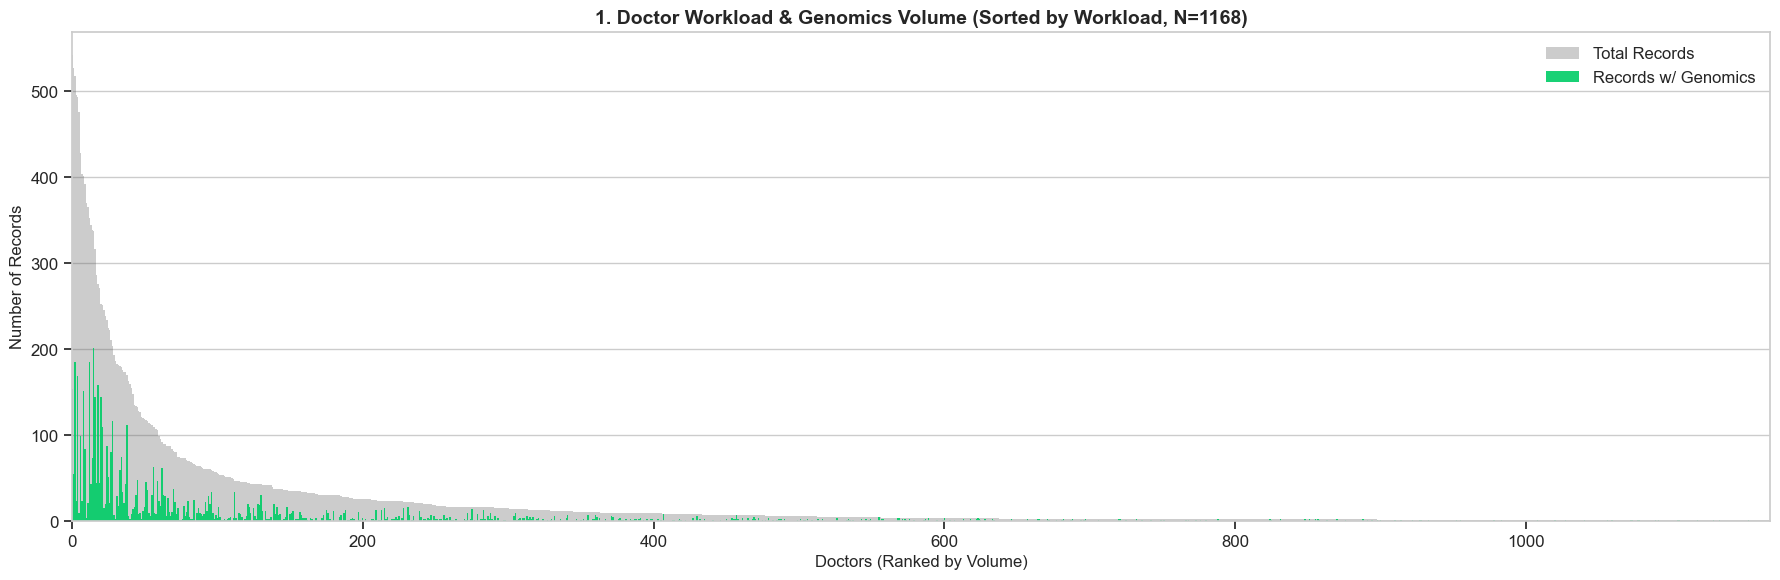

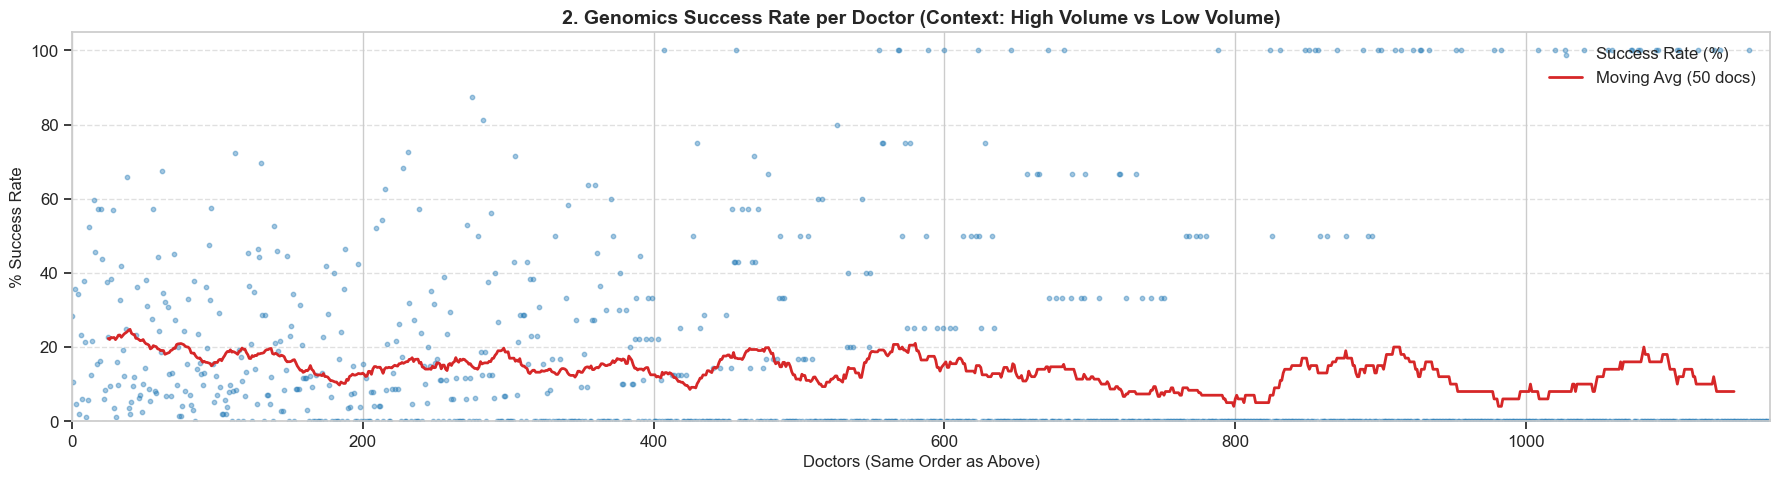

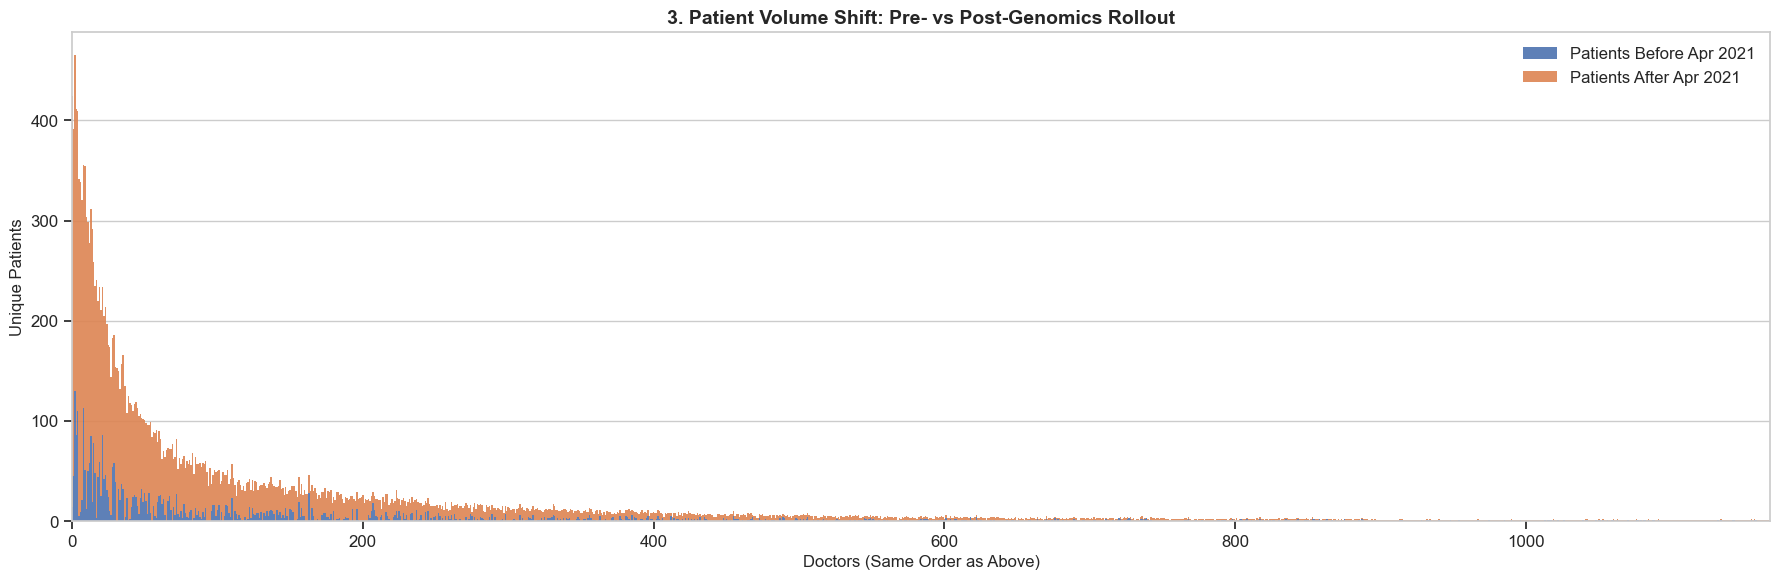


📊 KEY DISTRIBUTION INSIGHTS
   - Top 10 Doctors handle 4678 records (18.1% of total).
   - Doctors with >50% Genomics Rate: 101 doctors.
   - Doctors with 0% Genomics Rate:   722 doctors.


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# --- Configuration ---
DB_PATH = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_db2_standard.sqlite"

def run_analysis():
    # Style settings for high visibility
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("notebook", font_scale=1.1)
    
    # 1. Load Data
    if not os.path.exists(DB_PATH):
        print(f"❌ Error: Database file not found.")
        return

    print("⏳ Loading data...")
    conn = sqlite3.connect(DB_PATH)
    query = """
    SELECT 
        patient_id, 
        medical_record_id, 
        prescribing_doctor, 
        genomics_results_date,
        prescription_creation_date
    FROM prescriptions_standard
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    # 2. Preprocessing
    df['prescription_creation_date'] = pd.to_datetime(df['prescription_creation_date'], errors='coerce')
    # Filter valid doctors
    df = df[df['prescribing_doctor'].notna() & (df['prescribing_doctor'].astype(str).str.strip() != '')]
    # Boolean for genomics presence
    df['has_genomics'] = df['genomics_results_date'].fillna('').astype(str).str.strip() != ''

    # ==========================
    # 📜 SECTION 1: NUMERIC INSIGHTS
    # ==========================
    print("\n" + "="*50)
    print(" 🏥 PROVIDER & CONTINUITY METRICS")
    print("="*50)
    
    # Unique Doctors
    unique_doctors = df['prescribing_doctor'].unique()
    print(f"Total Unique Prescribing Doctors: {len(unique_doctors)}")
    
    # Continuity (Doctors per Record)
    docs_per_record = df.groupby('medical_record_id')['prescribing_doctor'].nunique()
    total_records = len(docs_per_record)
    mixed_records = docs_per_record[docs_per_record > 1].index
    n_mixed = len(mixed_records)
    
    print(f"Total Medical Records: {total_records}")
    print(f"   Single-Doctor Records: {total_records - n_mixed} ({((total_records-n_mixed)/total_records):.1%})")
    print(f"   Multi-Doctor Records:  {n_mixed} ({(n_mixed/total_records):.1%})")
    
    # Genomics in Mixed Records
    if n_mixed > 0:
        mixed_genomics_status = df[df['medical_record_id'].isin(mixed_records)].groupby('medical_record_id')['has_genomics'].any()
        n_mixed_w_genomics = mixed_genomics_status.sum()
        print(f"\n🔍 Deep Dive: Multi-Doctor Records ({n_mixed} cases)")
        print(f"   - With Genomics:    {n_mixed_w_genomics} ({(n_mixed_w_genomics/n_mixed):.1%})")
        print(f"   - Without Genomics: {n_mixed - n_mixed_w_genomics}")

    # ==========================
    # 📊 SECTION 2: VISUALIZATION
    # ==========================
    
    # --- Prepare Data Frame ---
    # 1. Volume Stats
    doc_stats = df.groupby('prescribing_doctor')['medical_record_id'].nunique().to_frame(name='total_records')
    
    # 2. Genomics Stats
    record_status = df.groupby(['medical_record_id', 'prescribing_doctor'])['has_genomics'].any().reset_index()
    doc_genomics = record_status.groupby('prescribing_doctor')['has_genomics'].sum()
    doc_stats['genomics_records'] = doc_genomics
    doc_stats['genomics_pct'] = (doc_stats['genomics_records'] / doc_stats['total_records']) * 100
    
    # 3. Temporal Stats
    cutoff = pd.Timestamp('2021-04-19')
    df_dates = df[['prescribing_doctor', 'patient_id', 'prescription_creation_date']].dropna(subset=['prescription_creation_date'])
    df_dates['period'] = np.where(df_dates['prescription_creation_date'] >= cutoff, 'after_2021', 'before_2021')
    
    doc_temporal = df_dates.groupby(['prescribing_doctor', 'period'])['patient_id'].nunique().unstack(fill_value=0)
    doc_stats = doc_stats.join(doc_temporal).fillna(0)
    if 'before_2021' not in doc_stats.columns: doc_stats['before_2021'] = 0
    if 'after_2021' not in doc_stats.columns: doc_stats['after_2021'] = 0

    # SORTING: Sort by Total Volume Descending (The "Long Tail")
    doc_stats = doc_stats.sort_values('total_records', ascending=False)
    x_indices = np.arange(len(doc_stats))

    print("\n" + "="*50)
    print(" 📉 GENERATING CHARTS")
    print("="*50)
    print("Displaying 3 separate high-detail figures...")

    # --- FIGURE 1: Workload & Genomics Volume ---
    plt.figure(figsize=(18, 6))
    
    # Plot Total Records (Grey Background) - Use width=1.0 and linewidth=0 for solid block effect
    plt.bar(x_indices, doc_stats['total_records'], color='#595959', alpha=0.3, width=1.0, linewidth=0, label='Total Records')
    
    # Plot Genomics Records (Strong Color Overlay)
    plt.bar(x_indices, doc_stats['genomics_records'], color='#00CC66', alpha=0.9, width=1.0, linewidth=0, label='Records w/ Genomics')
    
    plt.xlim(0, len(doc_stats))
    plt.title(f'1. Doctor Workload & Genomics Volume (Sorted by Workload, N={len(doc_stats)})', fontsize=14, weight='bold')
    plt.ylabel('Number of Records', fontsize=12)
    plt.xlabel('Doctors (Ranked by Volume)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(False, axis='x') # Clean look
    plt.tight_layout()
    plt.show()

    # --- FIGURE 2: Genomics Success % ---
    plt.figure(figsize=(18, 5))
    
    # Use Scatter for density + Rolling Average Line
    plt.scatter(x_indices, doc_stats['genomics_pct'], s=10, color='#1f77b4', alpha=0.4, label='Success Rate (%)')
    
    # Moving average trendline (window=50 doctors)
    rolling_avg = doc_stats['genomics_pct'].rolling(window=50, center=True).mean()
    plt.plot(x_indices, rolling_avg, color='#D62728', linewidth=2, label='Moving Avg (50 docs)')
    
    plt.xlim(0, len(doc_stats))
    plt.ylim(0, 105)
    plt.title('2. Genomics Success Rate per Doctor (Context: High Volume vs Low Volume)', fontsize=14, weight='bold')
    plt.ylabel('% Success Rate', fontsize=12)
    plt.xlabel('Doctors (Same Order as Above)', fontsize=12)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- FIGURE 3: Temporal Shift ---
    plt.figure(figsize=(18, 6))
    
    # Stacked Bar (Before = Blue, After = Orange)
    p1 = plt.bar(x_indices, doc_stats['before_2021'], color='#4C72B0', width=1.0, linewidth=0, alpha=0.9, label='Patients Before Apr 2021')
    p2 = plt.bar(x_indices, doc_stats['after_2021'], bottom=doc_stats['before_2021'], color='#DD8452', width=1.0, linewidth=0, alpha=0.9, label='Patients After Apr 2021')

    plt.xlim(0, len(doc_stats))
    plt.title('3. Patient Volume Shift: Pre- vs Post-Genomics Rollout', fontsize=14, weight='bold')
    plt.ylabel('Unique Patients', fontsize=12)
    plt.xlabel('Doctors (Same Order as Above)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(False, axis='x')
    plt.tight_layout()
    plt.show()

    # --- EXTRA TEXT STATS ---
    print("\n📊 KEY DISTRIBUTION INSIGHTS")
    print(f"   - Top 10 Doctors handle {doc_stats['total_records'].head(10).sum()} records ({doc_stats['total_records'].head(10).sum()/total_records:.1%} of total).")
    print(f"   - Doctors with >50% Genomics Rate: {len(doc_stats[doc_stats['genomics_pct'] > 50])} doctors.")
    print(f"   - Doctors with 0% Genomics Rate:   {len(doc_stats[doc_stats['genomics_pct'] == 0])} doctors.")

if __name__ == "__main__":
    run_analysis()

### EDA of comorbidities - a possible new line of research

In [ ]:
import pandas as pd
import sqlite3

# Path to the filtered SQLite database
filtered_db_path = 'C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\DB2_standard\\pnk_db2_filtered.sqlite'

# Connect to the SQLite database
conn = sqlite3.connect(filtered_db_path)

# Load the medical_records_filtered table into a pandas DataFrame
medical_records_filtered_df = pd.read_sql_query("SELECT * FROM medical_records_filtered", conn)

# Close the database connection
conn.close()

# Display the DataFrame
print(medical_records_filtered_df.head())

In [ ]:
medical_records_filtered_df

In [ ]:
import pandas as pd
import sqlite3
import os
from collections import Counter

# Define the path to the filtered database (assuming 'standard' folder path is defined from cell 88fdfdea)
# filtered_db_path = os.path.join(standard, filtered_db_name) # This should be available from cell 88fdfdea

# Connect to the SQLite database
# Ensure filtered_db_path is correctly defined and accessible
if 'filtered_db_path' not in locals() and 'filtered_db_path' not in globals():
    print("Error: filtered_db_path is not defined. Please ensure cell 88fdfdea or a similar cell defining it has been run.")
else:
    try:
        conn_filtered = sqlite3.connect(filtered_db_path)
        print(f"Successfully connected to {filtered_db_path}")

        # 1. Query the medical_records_filtered table
        print("\nLoading medical_records_filtered table...")
        medical_records_filtered_df = pd.read_sql_query("SELECT * FROM medical_records_filtered", conn_filtered)
        print(f"Loaded medical_records_filtered_df with shape: {medical_records_filtered_df.shape}")

        # 2. Create 'records_with_comorbidities' where comorbidity1 is not null
        if 'comorbidity1' in medical_records_filtered_df.columns:
            records_with_comorbidities = medical_records_filtered_df[medical_records_filtered_df['comorbidity1'].notna()].copy()
            print(f"\nCreated records_with_comorbidities with shape: {records_with_comorbidities.shape}")
            print("Head of records_with_comorbidities:")
            print(records_with_comorbidities.head())
        else:
            print("\nError: 'comorbidity1' column not found in medical_records_filtered_df.")
            records_with_comorbidities = pd.DataFrame() # Create an empty DataFrame to avoid further errors

        if not records_with_comorbidities.empty:
            # 3. Count unique comorbidities and sort in descending order
            comorbidity_cols = [col for col in records_with_comorbidities.columns if col.startswith('comorbidity')]
            print(f"\nComorbidity columns identified: {comorbidity_cols}")

            all_comorbidities_list = []
            for col in comorbidity_cols:
                all_comorbidities_list.extend(records_with_comorbidities[col].dropna().tolist())
            
            comorbidity_counts = Counter(all_comorbidities_list)
            # Sort by count in descending order
            sorted_comorbidity_counts = sorted(comorbidity_counts.items(), key=lambda item: item[1], reverse=True)
            
            print("\nUnique comorbidity counts (descending) across all comorbidity columns:")
            if sorted_comorbidity_counts:
                for comorbidity, count in sorted_comorbidity_counts:
                    print(f"- {comorbidity}: {count}")
            else:
                print("No comorbidities found or all values are NaN in comorbidity columns.")

            # 4. Count unique drugs and sort in descending order
            drug_cols = [col for col in records_with_comorbidities.columns if col.startswith('drug')]
            print(f"\nDrug columns identified: {drug_cols}")

            all_drugs_list = []
            for col in drug_cols:
                all_drugs_list.extend(records_with_comorbidities[col].dropna().tolist())
                
            drug_counts = Counter(all_drugs_list)
            # Sort by count in descending order
            sorted_drug_counts = sorted(drug_counts.items(), key=lambda item: item[1], reverse=True)

            print("\nUnique drug counts (descending) across all drug columns:")
            if sorted_drug_counts:
                for drug, count in sorted_drug_counts:
                    print(f"- {drug}: {count}")
            else:
                print("No drugs found or all values are NaN in drug columns.")

        # Close the connection
        conn_filtered.close()
        print("\nDatabase connection closed.")

    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
        if 'conn_filtered' in locals() and conn_filtered:
            conn_filtered.close()
    except NameError as e:
        print(f"NameError: {e}. A required variable (e.g., filtered_db_path) might not be defined.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

### Weight gain cause labeling with GPT - core of papers 1-2

#### Overview

Here, the 'weight gain causes' unstructured text (patient narratives of weight gain causes) column of medical records is exploited. 

A LLM prompt - API call based pipeline is used to identify pre-defined categories in narratives. These categories are then re-introduced to medical records in the medical records standardization pipeline (yes, this is a quirky interdependency of the pipelines, the medical records standardization pipeline technically depends on this step) and used in research. 

This project started as an exploratory idea and had a bigger-than-expected evolution, but its code is still structured as per the exploratory stage. 

Later, when the Frontiers in Nutrition paper was reviewed, this pipeline was further imporved and evaluated in the `paper2_notebook`. The improved version is also copied here from that notebook, without adjusting I/O paths, or running tests. 

#### translation of columns

In [2]:
import os
import sqlite3
import pandas as pd
from openai import OpenAI, RateLimitError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type # Import tenacity

# --- CONFIGURATION ---
SOURCE_DB    = r"c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_db2_colclean.sqlite"
SOURCE_TABLE = "medical_records_complete"
OUTPUT_DB    = r"c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"
OUTPUT_TABLE = "weight_gain_causes"
API_KEY_PATH = r"C:\Users\Felhasználó\Desktop\Areas\Személyes\genai_sandbox\openai_api_key.txt"
MODEL_NAME   = "gpt-4o-mini"
MAX_WORKERS  = 5

def load_api_key(path):
    with open(path) as f: return f.read().strip()

def get_openai_client():
    key = load_api_key(API_KEY_PATH) or os.getenv("OPENAI_API_KEY")
    return OpenAI(api_key=key)

@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60), # Wait 1s, 2s, 4s, ... up to 60s between retries
    stop=stop_after_attempt(5), # Stop after 5 attempts
    retry=retry_if_exception_type(RateLimitError) # Only retry for RateLimitError
)

def translate_to_english(client, text_to_translate):
    system_prompt = """You are a medical text translator fluent in Romance languages, particularly Spanish and Portuguese. You also speak other European languages. 
You understand the subtleties of these languages and can provide clear, natural, and context-aware translations to English, especially in health contexts.
You can handle abbreviations, colloquialisms, or typos effectively.
Your task is to translate patient-reported reasons for weight gain. These texts are from patients with obesity or overweight describing why they believe they gained weight.
Some texts may be vague, complex, abbreviated, simplified, or contain typos.
Preserve the meaning and context accurately. 
Output only the English translation, in all lowercases, without any additional comments or preambles.

Example 1:
Original (Spanish): "Estrés en el trabajo y horarios cambiantes "
Translation: "stress at work and changing hours"

Example 2:
Original (Portuguese): "MUDANÇA DE ROTINAS POR ALTERAÇÃO DE TRABALHO 
TEVE UM TEMPO SEM TRABALHAR A CUIDAR DE UM FAMILIAR COM INCONSTANCIA ALIMENTAR"

Translation: "change of routines due to job change
             spent some time not working taking care of a family member with irregular eating habits"
"""
    user_prompt = f"""Translate the following patient-reported reason for their weight gain from its original language (Spanish or Portuguese) to English:
Original text: "{text_to_translate}"

English Translation:"""

    resp = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.0,
        max_tokens=120
    )
    return resp.choices[0].message.content.strip()

def main():
    # 1) load and filter
    conn = sqlite3.connect(SOURCE_DB)
    df = pd.read_sql_query(
        f"SELECT patient_id, medical_record_id, weight_gain_cause FROM {SOURCE_TABLE}",
        conn
    )
    conn.close()
    df = df[df.weight_gain_cause.notna()].copy()

    # 2) write initial
    conn2 = sqlite3.connect(OUTPUT_DB)
    df.to_sql(OUTPUT_TABLE, conn2, if_exists="replace", index=False)

    # 3) parallel translate
    client = get_openai_client()
    texts = df['weight_gain_cause'].tolist()
    translated = [None] * len(texts)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = { ex.submit(translate_to_english, client, txt): i
                    for i, txt in enumerate(texts) }
        for fut in as_completed(futures):
            translated[futures[fut]] = fut.result()

    df['weight_gain_cause_en'] = translated

    # 4) overwrite
    df.to_sql(OUTPUT_TABLE, conn2, if_exists="replace", index=False)
    conn2.close()
    print("✅ Translations complete.")

if __name__ == "__main__":
    main()

✅ Translations complete.


#### categorization of weight gain reasons

##### v4 - p2 In review 5Feb26 - correcting data handling issues - separate I/O (source/labeled) tables; patient and record IDs used for reliable positional indexing instead of pd df indices

In [ ]:
import os
import sqlite3
import pandas as pd
from openai import OpenAI, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

# --- CONFIGURATION ---
DB              = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\outputs\wgc_labeling_qc_Feb26_p2_fnutr_revs\weight_gain_causes.sqlite"
SOURCE_TABLE    = "wgc308"        # READ-ONLY Input
LABELED_TABLE   = "wgc308_gpt52_p3_t0" # APPEND-ONLY Output
API_KEY_PATH    = r"C:\Users\Felhasználó\Desktop\Areas\Személyes\genai_sandbox\openai_api_key.txt"
MODEL           = "gpt-5.2" # gpt-4.1 / gpt-4o-mini / gpt-5.2
TEMPERATURE     = 0
MAX_TOKENS      = 100
SAVE_INTERVAL   = 10  # Save every 10 rows (safer and more frequent)

# Load API Key safely
try:
    with open(API_KEY_PATH, 'r') as f:
        API_KEY = f.read().strip()
except FileNotFoundError:
    raise FileNotFoundError(f"API Key file not found at {API_KEY_PATH}")

CATEGORIES = [
    "womens_health_and_pregnancy",
    "mental_health",
    "family_issues",
    "medication_disease_injury",
    "physical_inactivity",
    "eating_habits",
    "schedule",
    "smoking_cessation",
    "treatment_discontinuation_or_relapse", # Renamed for clarity
    "pandemic",
    "lifestyle_circumstances", # Split from the vague "habits_and_circumstances"
    "none_of_above"
]

def get_client():
    return OpenAI(api_key=API_KEY)

@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60),
    stop=stop_after_attempt(5),
    retry=retry_if_exception_type(RateLimitError)
)
def categorize(client, text):
    # User prompt
    prompt_v3 = f"""
    You are a meticulous clinical research analyst. Your primary function is to classify patient-reported reasons for weight gain with maximum accuracy, strictly adhering to the rules and definitions provided.
    Below, you find the instructions for a reseach task categorizing patient-reported reasons for weight gain.
    Your task is to classify the provided text into one or more of the following categories, based on the predefined category definitions and categorization examples provided.

    ## IMPORTANT INSTRUCTION
    The input text you receive may be in various languages (e.g., Spanish, Portuguese, Italian, French, Dutch). 
    You must contextually understand the input text in its original language and classify it according to the ENGLISH category definitions provided below. 
    Your output must be in English.

    ## CONTEXT
    The patients reporting the reasons for their weight gain are in a structured weight loss treatment program. 
    Some are undergoing their first intervention cycle. Others have had previous attempts at losing weight, and provide references to their past outcomes and experiences.

    ## CATEGORY DEFINITIONS
    These categories should be used to classify the reported reasons for weight gain.
    In the list below, you will find the definitions and use cases for each category.
    Please refer to these instructions carefully when assigning a category or categories to the given case. 
    Many cases are complex and may require multiple categories to be assigned.
    Only assign a category to the weight gain cause if the text explicitly mentions it as a reason for weight gain.
    Only use categories that are present in the defined list, do not create novel categories nor use synonyms or alternative syntaxes. 

    - **womens_health_and_pregnancy**: Weight gain related to pregnancy, postpartum periods and parenthood in general, menopause, fertility treatments, abortions or female-specific hormonal issues. 
    - **mental_health**: Weight gain related to psychological factors such as anxiety, depression, stress, emotional eating or other mental health and emotional issues.
    - **family_issues**: Weight gain related to interpersonal issues, such as caring for sick relatives, relationship or marital problems, loss of a loved one, or other family-related stressors.
    - **medication_disease_injury**: Weight gain related to medical conditions, sports or other injuries limiting mobility, or medication side effects. 
    - **physical_inactivity**: Weight gain related to a reduction of physical activity or excercise. These can be due to both lifestyle changes (e.g., "stopped exercising," "sedentary lifestyle"), medical conditions (e.g., "knee injury") or pandemic-related confinement.
    - **eating_habits**: Weight gain related to bad eating habits, such as overeating, emotional and stress eating, snacking, large meal portions, or disordered meal timing.
    - **schedule**: Weight gain related to logistical challenges related to work schedules, travel or lack of time disrupting healthy routines.
    - **smoking_cessation**: Weight gain related to quitting smoking. 
    - **treatment_discontinuation_or_relapse**: Weight gain related to the discontinuation of a previous weight loss intervention, a lack of weight maintenance or a relapse after a previous successful weight loss.
    - **lifestyle_circumstances**: Weight gain related to life events and circumstances such as a vacation, summer, holidays, moving house, work-related challenges. 
    - **pandemic**: Weight gain related to the COVID-19 pandemic, lockdowns, isolation or confinement.
    - **none_of_above**: Fallback category for cases that do not fit any of the above categories, or when the text is too vague to classify, such as "personal reasons," "bad habits" without detail, or when the response is irrelevant to the cause of the weight gain or is not explicitly stated. Do NOT use this category in combination with any other category, it is a catch-all for cases that do not fit any of the above categories.

    ## EXAMPLES (FEW-SHOT LEARNING)
    - **Input**: "hizo parón en sept, aunque en realidad sólo hizo un pedido, no llegó a retomar."
    - **Output**: treatment_discontinuation_or_relapse
    - **Input**: "lo tuvo que dejar por una enfermedad del marido"
    - **Output**: family_issues, treatment_discontinuation_or_relapse
    - **Input**: "malos hábitos"
    - **Output**: none_of_above
    - **Input**: "last year she did the diet and reached 60kg, she has maintained it until summer, now she is very hungry and anxious"
    - **Output**: treatment_discontinuation_or_relapse, lifestyle_circumstances, mental_health, eating_habits
    - **Input**: "CONFINAMIENTO (cervezas, patatas, ...)
    - **Output**: pandemic, eating_habits
    - **Input**: "AUMENTOU MUITO NESTES ULTIMOS 2 ANOS PORQUE MUDOU DE TRABALHO PORQUE É MUITO MAIS SEDENTÁRIA. REFERE QUE SE PORTA BEM DURANTE O DIA MAS QUANDO CHEGA A CASA TEM MUITA VONTADE DE COMER.
    - **Output**: lifestyle_circumstances, physical_inactivity, eating_habits
    - **Input**: "Menopausa, sempre teve tendência para aumentar de peso, refere metabolismo lento, que se adapta facilmente a restrições alimentares, gravidez tardia (mas depois recuperou o peso) e gradualmente foi aumentando.Fez dieta da lev (perdeu, chegou aos 71 kg, mas começou a aumentar e a ter dificuldade a descer, chegou a estar 15 dias a fazer lev e não diminuiu).
    - **Output**: womens_health_and_pregnancy, treatment_discontinuation_or_relapse
    - **Input**: "TRABALHA (EMPRESA PRÓPRIA) + ESTUDA - POUCO TEMPO, VIDA MAIS SEDENTÁRIA (INTERROMPEU A PRÁTICA REGULAR DE EXERCÍCIO), DESMOTIVOU-SE E DEIXOU DE MONITORIZAR O PESO/O QUE COMIA
    - **Output**: lifestyle_circumstances, physical_inactivity, treatment_discontinuation_or_relapse, eating_habits
    - **Input**: "TER IDO VIVER PARA ESPANHA DURANTE UM ANO E MEIO. MAIS COMIDA. DESCONTROLO NOS HORÁRIOS DAS REFEIÇÕES. 
    - **Output**: lifestyle_circumstances, eating_habits, schedule
    - **Input**: "Problemas familiares y mucha ansiedad"
    - **Output**: family_issues, mental_health
    - **Input**: "menopausia, dejar de fumar"
    - **Output**: womens_health_and_pregnancy, smoking_cessation
    - **Input**: ""Sedentarismo Ansiedad - hambre emocional: comer dulce Malos hábitos alimentarios"
    - **Output**: physical_inactivity, mental_health, eating_habits
    - **Input**: "menopausia, hipotiroidismo"
    - **Output**: womens_health_and_pregnancy, medication_disease_injury
    - **Input**: "SE CASO, VIAJES, 2 ABORTOS SEGUIDOS-- ANSIEDAD."
    - **Output**: lifestyle_circumstances, womens_health_and_pregnancy, mental_health
    - **Input**: "veel op de baan met haar werk"
    - **Output**: lifestyle_circumstances
    - **Input**: "DA SETTEMBRE GRAVI PROBLEMI FAMILIARI + CURE CON FARMACI ANTIDEPRESSIVI (MOLTO GONFIORE)
    - **Output**: family_issues, medication_disease_injury, mental_health"
    - **Input**: "tuvo un accidente y cogio peso otra vez"
    - **Output**: medication_disease_injury
    - **Input**: "desorden horario, come mas por las noches durante el dia se restringe"
    - **Output**: schedule, eating_habits
    - **Input**: "VERANO"
    - **Output**: lifestyle_circumstances
    - **Input**: "NO LO SABE PQ DICE QUE SE CUIDA"
    - **Output**: none_of_above
    - **Input**: "UN POCO TODO"
    - **Output**: none_of_above

    ## CRITICAL RULES - YOU MUST FOLLOW THESE EXACTLY:
    1.  **THE 'none_of_above' RULE**: The category 'none_of_above' is MUTUALLY EXCLUSIVE. If the input text is too vague or does not fit any other category, you MUST return 'none_of_above' AND NOTHING ELSE. You must NEVER assign 'none_of_above' alongside any other category.
    2.  **NO INFERENCE OR GUESSING**: You MUST only classify causes that are explicitly stated in the text. Do not infer behaviors. For example, if the text says "lost discipline," do not guess this means 'physical_inactivity' or 'eating_habits'; if the text says "social life," do not infer 'eating_habits' unless food or meals are mentioned. The cause must be tangible and mentioned. 

    ## TASK
    Classify the following text. Return a comma-separated list of applicable English categories from the list provided, without any additional comments or preambles

    Input: "{text}"
    Output:
    """
    
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role":"system","content":"""You are an expert clinical research assistant specializing in obesity and patient-reported determinants of the disease. 
                                        Your task is to accurately classify self-reported reasons for weight gain into a predefined set of English categories.
                                        You read instructions carefully and follow them closely, adhering to the provided category definitions and examples when completing the task.
                                        You understand the complexities and subtlieties of patient-reported weight gain reasons, and you are able to classify them into the appropriate categories.
                                        You return a comma-separated list of categories for each input case, without any additional comments or preambles."""
            "weight-gain reasons."},
            {"role": "user", "content": prompt_v3}
        ],
        temperature=TEMPERATURE,
        max_completion_tokens=MAX_TOKENS
    )
    categories_text = resp.choices[0].message.content
    return [c.strip() for c in categories_text.split(",") if c.strip() in CATEGORIES]

def get_uncategorized_data(conn):
    """
    Returns only rows from SOURCE_TABLE that do not exist in LABELED_TABLE.
    Uses patient_id + medical_record_id as the composite key.
    """
    # 1. Check if LABELED_TABLE exists
    cursor = conn.cursor()
    cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{LABELED_TABLE}';")
    if not cursor.fetchone():
        print(f"Output table '{LABELED_TABLE}' does not exist yet. Processing all rows.")
        return pd.read_sql(f"SELECT * FROM {SOURCE_TABLE}", conn)

    # 2. If it exists, filter out already processed pairs
    print("Filtering out already processed records...")
    query = f"""
    SELECT s.*
    FROM {SOURCE_TABLE} s
    LEFT JOIN {LABELED_TABLE} l 
        ON s.patient_id = l.patient_id 
        AND s.medical_record_id = l.medical_record_id
    WHERE l.patient_id IS NULL
    """
    return pd.read_sql(query, conn)

def main():
    conn = sqlite3.connect(DB)
    
    # 1. Load only the work that needs to be done
    try:
        df_todo = get_uncategorized_data(conn)
    except pd.io.sql.DatabaseError as e:
        print(f"Database error: {e}")
        conn.close()
        return

    total_count = len(df_todo)
    if total_count == 0:
        print("All rows have already been categorized! Exiting.")
        conn.close()
        return

    print(f"Starting job. Rows to process: {total_count}")
    
    client = get_client()
    batch_results = []
    
    # 2. Iterate through the TODO list
    for i, row in df_todo.iterrows():
        text_input = row['weight_gain_cause']
        
        # Metadata for linkage (DO NOT send to API)
        p_id = row['patient_id']
        m_id = row['medical_record_id']

        if pd.isna(text_input) or str(text_input).strip() == "":
            print(f"Skipping empty text for Patient {p_id}")
            # Optional: You might want to log this as 'none_of_above' in the output table
            # to prevent it from showing up in the 'TODO' list next time.
            continue

        try:
            print(f"Processing ({i+1}/{total_count}): Patient {p_id}")
            
            # API CALL - Only sending text
            cats = categorize(client, text_input)
            
            # Build Result Row
            result = {
                'patient_id': p_id,
                'medical_record_id': m_id,
                'original_text': text_input, # Optional: helpful for verification
                'model': MODEL
            }
            # Add boolean flags
            for c in CATEGORIES:
                result[c] = (c in cats)
            
            batch_results.append(result)

        except Exception as e:
            print(f"Error on Patient {p_id}: {e}")
            # Continue to next row; simply won't save this one
        
        # 3. Batch Save (Append Only)
        if len(batch_results) >= SAVE_INTERVAL:
            print(f"Saving batch of {len(batch_results)} records...")
            pd.DataFrame(batch_results).to_sql(LABELED_TABLE, conn, if_exists='append', index=False)
            batch_results = [] # Clear memory

    # 4. Final Save for remaining rows
    if batch_results:
        print(f"Saving final batch of {len(batch_results)} records...")
        pd.DataFrame(batch_results).to_sql(LABELED_TABLE, conn, if_exists='append', index=False)
    
    print("Done.")
    conn.close()

if __name__ == "__main__":
    main()


##### v3 - spring 25 - base of publications! - use gpt4.1, added 'critical rules' section explicitly warning for the explicit use of the category 'none of the above' and against inferences, and saving the results partially to avoid losing progress during runtime errors

In [61]:
import os
import sqlite3
import pandas as pd
from openai import OpenAI, RateLimitError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type # Import tenacity

# --- CONFIGURATION ---
DB       = r"c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"
TABLE    = "weight_gain_causes"
API_KEY  = open(r"C:\Users\Felhasználó\Desktop\Areas\Személyes\genai_sandbox\openai_api_key.txt").read().strip()
MODEL = "gpt-4.1" # flagship model

# Refined categories based on our discussion
CATEGORIES = [
    "womens_health_and_pregnancy",
    "mental_health",
    "family_issues",
    "medication_disease_injury",
    "physical_inactivity",
    "eating_habits",
    "schedule",
    "smoking_cessation",
    "treatment_discontinuation_or_relapse", # Renamed for clarity
    "pandemic",
    "lifestyle_circumstances", # Split from the vague "habits_and_circumstances"
    "none_of_above"
]

def get_client():
    return OpenAI(api_key=API_KEY)

@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60), # Wait 1s, 2s, 4s, ... up to 60s between retries
    stop=stop_after_attempt(5), # Stop after 5 attempts
    retry=retry_if_exception_type(RateLimitError) # Only retry for RateLimitError
)

def categorize(client, text):
    prompt = f"""
    You are a meticulous clinical research analyst. Your primary function is to classify patient-reported reasons for weight gain with maximum accuracy, strictly adhering to the rules and definitions provided.
    Below, you find the instructions for a reseach task categorizing patient-reported reasons for weight gain.
    Your task is to classify the provided text into one or more of the following categories, based on the predefined category definitions and categorization examples provided.

    ## IMPORTANT INSTRUCTION
    The input text you receive may be in various languages (e.g., Spanish, Portuguese, Italian, French, Dutch). 
    You must contextually understand the input text in its original language and classify it according to the ENGLISH category definitions provided below. 
    Your output must be in English.

    ## CONTEXT
    The patients reporting the reasons for their weight gain are in a structured weight loss treatment program. 
    Some are undergoing their first intervention cycle. Others have had previous attempts at losing weight, and provide references to their past outcomes and experiences.

    ## CATEGORY DEFINITIONS
    These categories should be used to classify the reported reasons for weight gain.
    In the list below, you will find the definitions and use cases for each category.
    Please refer to these instructions carefully when assigning a category or categories to the given case. 
    Many cases are complex and may require multiple categories to be assigned.
    Only assign a category to the weight gain cause if the text explicitly mentions it as a reason for weight gain.
    Only use categories that are present in the defined list, do not create novel categories nor use synonyms or alternative syntaxes. 

    - **womens_health_and_pregnancy**: Weight gain related to pregnancy, postpartum periods and parenthood in general, menopause, fertility treatments, abortions or female-specific hormonal issues. 
    - **mental_health**: Weight gain related to psychological factors such as anxiety, depression, stress, emotional eating or other mental health and emotional issues.
    - **family_issues**: Weight gain related to interpersonal issues, such as caring for sick relatives, relationship or marital problems, loss of a loved one, or other family-related stressors.
    - **medication_disease_injury**: Weight gain related to medical conditions, sports or other injuries limiting mobility, or medication side effects. 
    - **physical_inactivity**: Weight gain related to a reduction of physical activity or excercise. These can be due to both lifestyle changes (e.g., "stopped exercising," "sedentary lifestyle"), medical conditions (e.g., "knee injury") or pandemic-related confinement.
    - **eating_habits**: Weight gain related to bad eating habits, such as overeating, emotional and stress eating, snacking, large meal portions, or disordered meal timing.
    - **schedule**: Weight gain related to logistical challenges related to work schedules, travel or lack of time disrupting healthy routines.
    - **smoking_cessation**: Weight gain related to quitting smoking. 
    - **treatment_discontinuation_or_relapse**: Weight gain related to the discontinuation of a previous weight loss intervention, a lack of weight maintenance or a relapse after a previous successful weight loss.
    - **lifestyle_circumstances**: Weight gain related to life events and circumstances such as a vacation, summer, holidays, moving house, work-related challenges. 
    - **pandemic**: Weight gain related to the COVID-19 pandemic, lockdowns, isolation or confinement.
    - **none_of_above**: Fallback category for cases that do not fit any of the above categories, or when the text is too vague to classify, such as "personal reasons," "bad habits" without detail, or when the response is irrelevant to the cause of the weight gain or is not explicitly stated. Do NOT use this category in combination with any other category, it is a catch-all for cases that do not fit any of the above categories.

    ## EXAMPLES (FEW-SHOT LEARNING)
    - **Input**: "hizo parón en sept, aunque en realidad sólo hizo un pedido, no llegó a retomar."
    - **Output**: treatment_discontinuation_or_relapse
    - **Input**: "lo tuvo que dejar por una enfermedad del marido"
    - **Output**: family_issues, treatment_discontinuation_or_relapse
    - **Input**: "malos hábitos"
    - **Output**: none_of_above
    - **Input**: "last year she did the diet and reached 60kg, she has maintained it until summer, now she is very hungry and anxious"
    - **Output**: treatment_discontinuation_or_relapse, lifestyle_circumstances, mental_health, eating_habits
    - **Input**: "CONFINAMIENTO (cervezas, patatas, ...)
    - **Output**: pandemic, eating_habits
    - **Input**: "AUMENTOU MUITO NESTES ULTIMOS 2 ANOS PORQUE MUDOU DE TRABALHO PORQUE É MUITO MAIS SEDENTÁRIA. REFERE QUE SE PORTA BEM DURANTE O DIA MAS QUANDO CHEGA A CASA TEM MUITA VONTADE DE COMER.
    - **Output**: lifestyle_circumstances, physical_inactivity, eating_habits
    - **Input**: "Menopausa, sempre teve tendência para aumentar de peso, refere metabolismo lento, que se adapta facilmente a restrições alimentares, gravidez tardia (mas depois recuperou o peso) e gradualmente foi aumentando.Fez dieta da lev (perdeu, chegou aos 71 kg, mas começou a aumentar e a ter dificuldade a descer, chegou a estar 15 dias a fazer lev e não diminuiu).
    - **Output**: womens_health_and_pregnancy, treatment_discontinuation_or_relapse
    - **Input**: "TRABALHA (EMPRESA PRÓPRIA) + ESTUDA - POUCO TEMPO, VIDA MAIS SEDENTÁRIA (INTERROMPEU A PRÁTICA REGULAR DE EXERCÍCIO), DESMOTIVOU-SE E DEIXOU DE MONITORIZAR O PESO/O QUE COMIA
    - **Output**: lifestyle_circumstances, physical_inactivity, treatment_discontinuation_or_relapse, eating_habits
    - **Input**: "TER IDO VIVER PARA ESPANHA DURANTE UM ANO E MEIO. MAIS COMIDA. DESCONTROLO NOS HORÁRIOS DAS REFEIÇÕES. 
    - **Output**: lifestyle_circumstances, eating_habits, schedule
    - **Input**: "Problemas familiares y mucha ansiedad"
    - **Output**: family_issues, mental_health
    - **Input**: "menopausia, dejar de fumar"
    - **Output**: womens_health_and_pregnancy, smoking_cessation
    - **Input**: ""Sedentarismo Ansiedad - hambre emocional: comer dulce Malos hábitos alimentarios"
    - **Output**: physical_inactivity, mental_health, eating_habits
    - **Input**: "menopausia, hipotiroidismo"
    - **Output**: womens_health_and_pregnancy, medication_disease_injury
    - **Input**: "SE CASO, VIAJES, 2 ABORTOS SEGUIDOS-- ANSIEDAD."
    - **Output**: lifestyle_circumstances, womens_health_and_pregnancy, mental_health
    - **Input**: "veel op de baan met haar werk"
    - **Output**: lifestyle_circumstances
    - **Input**: "DA SETTEMBRE GRAVI PROBLEMI FAMILIARI + CURE CON FARMACI ANTIDEPRESSIVI (MOLTO GONFIORE)
    - **Output**: family_issues, medication_disease_injury, mental_health"
    - **Input**: "tuvo un accidente y cogio peso otra vez"
    - **Output**: medication_disease_injury
    - **Input**: "desorden horario, come mas por las noches durante el dia se restringe"
    - **Output**: schedule, eating_habits
    - **Input**: "VERANO"
    - **Output**: lifestyle_circumstances
    - **Input**: "NO LO SABE PQ DICE QUE SE CUIDA"
    - **Output**: none_of_above
    - **Input**: "UN POCO TODO"
    - **Output**: none_of_above

    ## CRITICAL RULES - YOU MUST FOLLOW THESE EXACTLY:
    1.  **THE 'none_of_above' RULE**: The category 'none_of_above' is MUTUALLY EXCLUSIVE. If the input text is too vague or does not fit any other category, you MUST return 'none_of_above' AND NOTHING ELSE. You must NEVER assign 'none_of_above' alongside any other category.
    2.  **NO INFERENCE OR GUESSING**: You MUST only classify causes that are explicitly stated in the text. Do not infer behaviors. For example, if the text says "lost discipline," do not guess this means 'physical_inactivity' or 'eating_habits'; if the text says "social life," do not infer 'eating_habits' unless food or meals are mentioned. The cause must be tangible and mentioned. 

    ## TASK
    Classify the following text. Return a comma-separated list of applicable English categories from the list provided, without any additional comments or preambles

    Input: "{text}"
    Output:
    """
    
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role":"system","content":"""You are an expert clinical research assistant specializing in obesity and patient-reported determinants of the disease. 
                                        Your task is to accurately classify self-reported reasons for weight gain into a predefined set of English categories.
                                        You read instructions carefully and follow them closely, adhering to the provided category definitions and examples when completing the task.
                                        You understand the complexities and subtlieties of patient-reported weight gain reasons, and you are able to classify them into the appropriate categories.
                                        You return a comma-separated list of categories for each input case, without any additional comments or preambles."""
            "weight-gain reasons."},
            {"role":"user","content":prompt}
        ],
        temperature=1,
        max_completion_tokens=100 # Increased slightly for potentially complex multi-category outputs
    )
    # Process the output to ensure it's clean
    categories_text = resp.choices[0].message.content
    return [c.strip() for c in categories_text.split(",") if c.strip() in CATEGORIES]

def main():
    # 1) Load data
    conn = sqlite3.connect(DB)
    try:
        df = pd.read_sql(f"SELECT * FROM {TABLE}", conn)
    except pd.io.sql.DatabaseError as e:
        print(f"Error reading table {TABLE}: {e}. Please ensure the table exists with 'weight_gain_cause' column.")
        conn.close()
        return

    # 2) Ensure category columns and 'is_categorized' status column exist
    for cat in CATEGORIES:
        if cat not in df.columns:
            df[cat] = False  # Initialize new category columns to False
    
    if 'is_categorized' not in df.columns:
        df['is_categorized'] = False # Initialize status column to False

    client = get_client()
    save_interval = 50  # Save progress every 50 successfully processed rows
    processed_in_this_run = 0

    # 3) Categorize rows that haven't been categorized yet
    rows_to_process_indices = df[~df['is_categorized']].index
    total_to_process_count = len(rows_to_process_indices)
    print(f"Found {total_to_process_count} rows to categorize.")

    for current_run_count, df_index in enumerate(rows_to_process_indices):
        text_to_categorize = df.at[df_index, "weight_gain_cause"]

        if pd.isna(text_to_categorize) or str(text_to_categorize).strip() == "":
            print(f"Processing DataFrame index {df_index} ({current_run_count + 1}/{total_to_process_count} in this batch) → Skipped (empty input).")
            # Mark as categorized, and set 'none_of_above' if applicable
            if 'none_of_above' in CATEGORIES:
                 for cat_col in CATEGORIES: # Reset all category columns first
                    df.at[df_index, cat_col] = False
                 df.at[df_index, 'none_of_above'] = True
            df.at[df_index, 'is_categorized'] = True
            processed_in_this_run += 1
            continue

        try:
            print(f"Processing DataFrame index {df_index} ({current_run_count + 1}/{total_to_process_count} in this batch)...")
            cats = categorize(client, text_to_categorize)
            
            # Reset existing category values for this row before applying new ones
            for cat_col in CATEGORIES:
                df.at[df_index, cat_col] = False
            
            for c in cats:
                if c in CATEGORIES:  # Ensure the category returned by API is valid
                    df.at[df_index, c] = True
            
            df.at[df_index, 'is_categorized'] = True # Mark as successfully categorized
            print(f"DataFrame index {df_index} → Categories: {cats}")
            processed_in_this_run += 1

        except Exception as e:
            print(f"Error processing DataFrame index {df_index}: {e}. Will retry in next run if not manually marked.")
            # This row will remain 'is_categorized' = False and will be picked up next time.
            # Consider adding more sophisticated error handling or logging if needed.

        # Save progress periodically
        if processed_in_this_run > 0 and processed_in_this_run % save_interval == 0:
            print(f"Saving intermediate progress to database ({processed_in_this_run} rows processed in this session)...")
            try:
                df.to_sql(TABLE, conn, if_exists="replace", index=False)
                print("Intermediate progress saved.")
            except Exception as e_save:
                print(f"Error saving intermediate progress: {e_save}")


    # 4) Write back final state
    print("Categorization loop finished. Saving final state to database...")
    try:
        df.to_sql(TABLE, conn, if_exists="replace", index=False)
        print("Weight gain reasons categorized and final data saved.")
    except Exception as e_final_save:
        print(f"Error saving final data: {e_final_save}")
    finally:
        conn.close()

if __name__ == "__main__":
    main()

Found 3361 rows to categorize.
Processing DataFrame index 0 (1/3361 in this batch)...
DataFrame index 0 → Categories: ['eating_habits', 'mental_health']
Processing DataFrame index 1 (2/3361 in this batch)...
DataFrame index 1 → Categories: ['womens_health_and_pregnancy']
Processing DataFrame index 2 (3/3361 in this batch)...
DataFrame index 2 → Categories: ['mental_health', 'lifestyle_circumstances']
Processing DataFrame index 3 (4/3361 in this batch)...
DataFrame index 3 → Categories: ['lifestyle_circumstances', 'medication_disease_injury', 'physical_inactivity']
Processing DataFrame index 4 (5/3361 in this batch)...
DataFrame index 4 → Categories: ['medication_disease_injury']
Processing DataFrame index 5 (6/3361 in this batch)...
DataFrame index 5 → Categories: ['womens_health_and_pregnancy']
Processing DataFrame index 6 (7/3361 in this batch)...
DataFrame index 6 → Categories: ['medication_disease_injury', 'pandemic', 'eating_habits']
Processing DataFrame index 7 (8/3361 in this ba

#### v2 - refined categories, category descriptions, few-shot structure, original language categorization

In [ ]:
import os
import sqlite3
import pandas as pd
from openai import OpenAI, RateLimitError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type # Import tenacity

# --- CONFIGURATION ---
DB       = r"c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"
TABLE    = "weight_gain_causes"
API_KEY  = open(r"C:\Users\Felhasználó\Desktop\Areas\Személyes\genai_sandbox\openai_api_key.txt").read().strip()
MODEL = "gpt-4o-mini" # Best OpenAI model for affordable reasoning and logic, based on https://zapier.com/blog/openai-models/

# Refined categories based on our discussion
CATEGORIES = [
    "womens_health_and_pregnancy",
    "mental_health",
    "family_issues",
    "medication_disease_injury",
    "physical_inactivity",
    "eating_habits",
    "schedule",
    "smoking_cessation",
    "treatment_discontinuation_or_relapse", # Renamed for clarity
    "pandemic",
    "lifestyle_circumstances", # Split from the vague "habits_and_circumstances"
    "none_of_above"
]

def get_client():
    return OpenAI(api_key=API_KEY)

@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60), # Wait 1s, 2s, 4s, ... up to 60s between retries
    stop=stop_after_attempt(5), # Stop after 5 attempts
    retry=retry_if_exception_type(RateLimitError) # Only retry for RateLimitError
)

def categorize(client, text):
    prompt = f"""
    Below, you find the instructions for a clinical research assistant task categorizing patient-reported reasons for weight gain.
    Your task is to classify the provided text into one or more of the following categories, based on the predefined category definitions and categorization examples provided.

    ## IMPORTANT INSTRUCTION
    The input text you receive may be in various languages (e.g., Spanish, Portuguese, Italian, French, Dutch). 
    You must contextually understand the input text in its original language and classify it according to the ENGLISH category definitions provided below. 
    Your output must be in English.

    ## CONTEXT
    The patients reporting the reasons for their weight gain are in a structured weight loss treatment program. 
    Some are undergoing their first intervention cycle. Others have had previous attempts at losing weight, and provide references to their past outcomes and experiences.

    ## CATEGORY DEFINITIONS
    These categories should be used to classify the reported reasons for weight gain.
    In the list below, you will find the definitions and use cases for each category.
    Please refer to these instructions carefully when assigning a category or categories to the given case. 
    Many cases are complex and may require multiple categories to be assigned.
    Only assign a category to the weight gain cause if the text explicitly mentions it as a reason for weight gain.
    Only use categories that are present in the defined list, do not create novel categories nor use synonyms or alternative syntaxes. 

    - **womens_health_and_pregnancy**: Weight gain related to pregnancy, postpartum periods and parenthood in general, menopause, fertility treatments, abortions or female-specific hormonal issues. 
    - **mental_health**: Weight gain related to psychological factors such as anxiety, depression, stress, emotional eating or other mental health and emotional issues.
    - **family_issues**: Weight gain related to interpersonal issues, such as caring for sick relatives, relationship or marital problems, loss of a loved one, or other family-related stressors.
    - **medication_disease_injury**: Weight gain related to medical conditions, sports or other injuries limiting mobility, or medication side effects. 
    - **physical_inactivity**: Weight gain related to a reduction of physical activity or excercise. These can be due to both lifestyle changes (e.g., "stopped exercising," "sedentary lifestyle"), medical conditions (e.g., "knee injury") or pandemic-related confinement.
    - **eating_habits**: Weight gain related to bad eating habits, such as overeating, emotional and stress eating, snacking, large meal portions, or disordered meal timing.
    - **schedule**: Weight gain related to logistical challenges related to work schedules, travel or lack of time disrupting healthy routines.
    - **smoking_cessation**: Weight gain related to quitting smoking. 
    - **treatment_discontinuation_or_relapse**: Weight gain related to the discontinuation of a previous weight loss intervention, a lack of maintenance or a relapse after a previous successful weight loss.
    - **lifestyle_circumstances**: Weight gain related to life events and circumstances such as a vacation, summer, holidays, moving house, work-related challenges. 
    - **pandemic**: Weight gain related to the COVID-19 pandemic, lockdowns, isolation or confinement.
    - **none_of_above**: Fallback category for cases that do not fit any of the above categories, or when the text is too vague to classify, such as "personal reasons," "bad habits" without detail, or when the response is irrelevant to the cause of the weight gain or is not explicitly stated. Do NOT use this category in combination with any other category, it is a catch-all for cases that do not fit any of the above categories.

    ## EXAMPLES (FEW-SHOT LEARNING)
    - **Input**: "hizo parón en sept, aunque en realidad sólo hizo un pedido, no llegó a retomar."
    - **Output**: treatment_discontinuation_or_relapse
    - **Input**: "lo tuvo que dejar por una enfermedad del marido"
    - **Output**: family_issues, treatment_discontinuation_or_relapse
    - **Input**: "malos hábitos"
    - **Output**: none_of_above
    - **Input**: "last year she did the diet and reached 60kg, she has maintained it until summer, now she is very hungry and anxious"
    - **Output**: treatment_discontinuation_or_relapse, lifestyle_circumstances, mental_health, eating_habits
    - **Input**: "CONFINAMIENTO (cervezas, patatas, ...)
    - **Output**: pandemic, eating_habits
    - **Input**: "AUMENTOU MUITO NESTES ULTIMOS 2 ANOS PORQUE MUDOU DE TRABALHO PORQUE É MUITO MAIS SEDENTÁRIA. REFERE QUE SE PORTA BEM DURANTE O DIA MAS QUANDO CHEGA A CASA TEM MUITA VONTADE DE COMER.
    - **Output**: lifestyle_circumstances, physical_inactivity, eating_habits
    - **Input**: "Menopausa, sempre teve tendência para aumentar de peso, refere metabolismo lento, que se adapta facilmente a restrições alimentares, gravidez tardia (mas depois recuperou o peso) e gradualmente foi aumentando.Fez dieta da lev (perdeu, chegou aos 71 kg, mas começou a aumentar e a ter dificuldade a descer, chegou a estar 15 dias a fazer lev e não diminuiu).
    - **Output**: womens_health_and_pregnancy, treatment_discontinuation_or_relapse
    - **Input**: "TRABALHA (EMPRESA PRÓPRIA) + ESTUDA - POUCO TEMPO, VIDA MAIS SEDENTÁRIA (INTERROMPEU A PRÁTICA REGULAR DE EXERCÍCIO), DESMOTIVOU-SE E DEIXOU DE MONITORIZAR O PESO/O QUE COMIA
    - **Output**: lifestyle_circumstances, physical_inactivity, treatment_discontinuation_or_relapse, eating_habits
    - **Input**: "TER IDO VIVER PARA ESPANHA DURANTE UM ANO E MEIO. MAIS COMIDA. DESCONTROLO NOS HORÁRIOS DAS REFEIÇÕES. 
    - **Output**: lifestyle_circumstances, eating_habits, schedule
    - **Input**: "Problemas familiares y mucha ansiedad"
    - **Output**: family_issues, mental_health
    - **Input**: "menopausia, dejar de fumar"
    - **Output**: womens_health_and_pregnancy, smoking_cessation
    - **Input**: ""Sedentarismo Ansiedad - hambre emocional: comer dulce Malos hábitos alimentarios"
    - **Output**: physical_inactivity, mental_health, eating_habits
    - **Input**: "menopausia, hipotiroidismo"
    - **Output**: womens_health_and_pregnancy, medication_disease_injury
    - **Input**: "SE CASO, VIAJES, 2 ABORTOS SEGUIDOS-- ANSIEDAD."
    - **Output**: lifestyle_circumstances, womens_health_and_pregnancy, mental_health
    - **Input**: "veel op de baan met haar werk"
    - **Output**: lifestyle_circumstances
    - **Input**: "DA SETTEMBRE GRAVI PROBLEMI FAMILIARI + CURE CON FARMACI ANTIDEPRESSIVI (MOLTO GONFIORE)
    - **Output**: family_issues, medication_disease_injury, mental_health"
    - **Input**: "tuvo un accidente y cogio peso otra vez"
    - **Output**: medication_disease_injury
    - **Input**: "desorden horario, come mas por las noches durante el dia se restringe"
    - **Output**: schedule, eating_habits
    - **Input**: "VERANO"
    - **Output**: lifestyle_circumstances
    - **Input**: "NO LO SABE PQ DICE QUE SE CUIDA"
    - **Output**: none_of_above
    - **Input**: "UN POCO TODO"
    - **Output**: none_of_above

    ## TASK
    Classify the following text. Return a comma-separated list of applicable English categories from the list provided, without any additional comments or preambles

    Input: "{text}"
    Output:
    """
    
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role":"system","content":"""You are an expert clinical research assistant specializing in obesity and patient-reported determinants of the disease. 
                                        Your task is to accurately classify self-reported reasons for weight gain into a predefined set of English categories.
                                        You read instructions carefully and follow them closely, adhering to the provided category definitions and examples when completing the task.
                                        You understand the complexities and subtlieties of patient-reported weight gain reasons, and you are able to classify them into the appropriate categories.
                                        You return a comma-separated list of categories for each input case, without any additional comments or preambles."""
            "weight-gain reasons."},
            {"role":"user","content":prompt}
        ],
        temperature=0.0,
        max_tokens=100 # Increased slightly for potentially complex multi-category outputs
    )
    # Process the output to ensure it's clean
    categories_text = resp.choices[0].message.content
    return [c.strip() for c in categories_text.split(",") if c.strip() in CATEGORIES]

def main():
    # 1) Load data
    conn = sqlite3.connect(DB)
    try:
        df = pd.read_sql(f"SELECT * FROM {TABLE}", conn)
    except pd.io.sql.DatabaseError as e:
        print(f"Error reading table {TABLE}: {e}. Please ensure the table exists with 'weight_gain_cause' column.")
        conn.close()
        return

    # 2) Ensure category columns and 'is_categorized' status column exist
    for cat in CATEGORIES:
        if cat not in df.columns:
            df[cat] = False  # Initialize new category columns to False
    
    if 'is_categorized' not in df.columns:
        df['is_categorized'] = False # Initialize status column to False

    client = get_client()
    save_interval = 50  # Save progress every 50 successfully processed rows
    processed_in_this_run = 0

    # 3) Categorize rows that haven't been categorized yet
    rows_to_process_indices = df[~df['is_categorized']].index
    total_to_process_count = len(rows_to_process_indices)
    print(f"Found {total_to_process_count} rows to categorize.")

    for current_run_count, df_index in enumerate(rows_to_process_indices):
        text_to_categorize = df.at[df_index, "weight_gain_cause"]

        if pd.isna(text_to_categorize) or str(text_to_categorize).strip() == "":
            print(f"Processing DataFrame index {df_index} ({current_run_count + 1}/{total_to_process_count} in this batch) → Skipped (empty input).")
            # Mark as categorized, and set 'none_of_above' if applicable
            if 'none_of_above' in CATEGORIES:
                 for cat_col in CATEGORIES: # Reset all category columns first
                    df.at[df_index, cat_col] = False
                 df.at[df_index, 'none_of_above'] = True
            df.at[df_index, 'is_categorized'] = True
            processed_in_this_run += 1
            continue

        try:
            print(f"Processing DataFrame index {df_index} ({current_run_count + 1}/{total_to_process_count} in this batch)...")
            cats = categorize(client, text_to_categorize)
            
            # Reset existing category values for this row before applying new ones
            for cat_col in CATEGORIES:
                df.at[df_index, cat_col] = False
            
            for c in cats:
                if c in CATEGORIES:  # Ensure the category returned by API is valid
                    df.at[df_index, c] = True
            
            df.at[df_index, 'is_categorized'] = True # Mark as successfully categorized
            print(f"DataFrame index {df_index} → Categories: {cats}")
            processed_in_this_run += 1

        except Exception as e:
            print(f"Error processing DataFrame index {df_index}: {e}. Will retry in next run if not manually marked.")
            # This row will remain 'is_categorized' = False and will be picked up next time.
            # Consider adding more sophisticated error handling or logging if needed.

        # Save progress periodically
        if processed_in_this_run > 0 and processed_in_this_run % save_interval == 0:
            print(f"Saving intermediate progress to database ({processed_in_this_run} rows processed in this session)...")
            try:
                df.to_sql(TABLE, conn, if_exists="replace", index=False)
                print("Intermediate progress saved.")
            except Exception as e_save:
                print(f"Error saving intermediate progress: {e_save}")


    # 4) Write back final state
    print("Categorization loop finished. Saving final state to database...")
    try:
        df.to_sql(TABLE, conn, if_exists="replace", index=False)
        print("Weight gain reasons categorized and final data saved.")
    except Exception as e_final_save:
        print(f"Error saving final data: {e_final_save}")
    finally:
        conn.close()

if __name__ == "__main__":
    main()



Row 1/3361 → ['eating_habits', 'mental_health']
Row 2/3361 → ['womens_health_and_pregnancy']
Row 3/3361 → ['mental_health', 'lifestyle_circumstances']
Row 4/3361 → ['lifestyle_circumstances', 'medication_disease_injury', 'physical_inactivity']
Row 5/3361 → ['medication_disease_injury']
Row 6/3361 → ['womens_health_and_pregnancy']
Row 7/3361 → ['medication_disease_injury', 'pandemic', 'eating_habits']
Row 8/3361 → ['eating_habits']
Row 9/3361 → ['none_of_above']
Row 10/3361 → ['lifestyle_circumstances', 'family_issues', 'eating_habits']
Row 11/3361 → ['treatment_discontinuation_or_relapse', 'lifestyle_circumstances']
Row 12/3361 → ['mental_health', 'eating_habits']
Row 13/3361 → ['mental_health']
Row 14/3361 → ['womens_health_and_pregnancy']
Row 15/3361 → ['eating_habits']
Row 16/3361 → ['medication_disease_injury']
Row 17/3361 → ['family_issues', 'lifestyle_circumstances', 'eating_habits']
Row 18/3361 → ['none_of_above']
Row 19/3361 → ['family_issues', 'pandemic']
Row 20/3361 → ['menta

RetryError: RetryError[<Future at 0x1dbbbd80fd0 state=finished raised RateLimitError>]

#### v1 - somewhat vague categorization, no context and examples, translated input categorization

In [ ]:
import os
import sqlite3
import pandas as pd
from openai import OpenAI

# --- CONFIGURATION ---
DB       = r"c:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"
TABLE    = "weight_gain_causes"
API_KEY  = open(r"C:\Users\Felhasználó\Desktop\Areas\Személyes\genai_sandbox\openai_api_key.txt").read().strip()
MODEL    = "gpt-4o-mini"

# Supply here the exact category names you want as columns:
CATEGORIES = [
    "womens_health_and_pregnancy",
    "mental_health",
    "family_issues",
    "medication_disease_injury",
    "physical_inactivity",
    "eating_habits",
    "schedule",
    "smoking_cessation",
    "post_treatment_weight_regain",
    "pandemic",
    "habits_and_circumstances",
    "none_of_above"
]

def get_client():
    return OpenAI(api_key=API_KEY)

def categorize(client, text):
    prompt = f"""
    You are a medical text classifier. You are reading through self-reported reasons for weight gain in a clinical research dataset. 
        In this dataset, patients with obesity or overweight describe the reason why they consider they have gained weight.
        Researchers want to study the association between these reasons and the patients' health outcomes.
        However, as the texts are in natural language, they need to be categorized into a set of predefined categories. 
        You are given the task of categorizing these reasons into a set of categories you are provided with. 
        It is possible and allowed to fit a patient's reported set of reasons into multiple categories, 
        as the drivers of weight gain are often multifactorial.
        Given a reason for weight gain in English, 
        return a comma-separated list of applicable categories exactly from:\n
        {', '.join(CATEGORIES)}

        Input: "{text}"
        Output:
        """
          
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role":"system","content":"You classify weight-gain reasons."},
            {"role":"user","content":prompt}
        ],
        temperature=0.0,
        max_tokens=60
    )
    return [c.strip() for c in resp.choices[0].message.content.split(",")]

def main():
    # 1) load
    conn = sqlite3.connect(DB)
    df = pd.read_sql(f"SELECT * FROM {TABLE}", conn)
    # 2) prepare empty columns
    for cat in CATEGORIES:
        df[cat] = False

    client = get_client()

    # 3) categorize
    for i, txt in enumerate(df["weight_gain_cause_en"]):
        cats = categorize(client, txt)
        for c in cats:
            if c in CATEGORIES:
                df.at[i, c] = True
        print(f"Row {i+1}/{len(df)} → {cats}")

    # 4) write back
    df.to_sql(TABLE, conn, if_exists="replace", index=False)
    conn.close()
    print("✅ Done.")

if __name__ == "__main__":
    main()

In [ ]:
import sqlite3

# Open the SQLite database and load the prescriptions_colclean table as a pandas DataFrame
with sqlite3.connect(colclean_db_path) as conn:
    prescriptions_colclean_df = pd.read_sql_query("SELECT * FROM prescriptions_colclean", conn)

# Display the first few rows
prescriptions_colclean_df

      patient_id medical_record_id prescription_id prescription_creation_date  \
0  98968C4CEB969     13C7F242A682D   1754154D15241        2023-08-10 17:43:48   
1  98968C4CEB969     13C7F242A682D   1767244D15241        2023-09-06 12:05:36   
2  98968C4CEB969     13C7F242A682D   17817B4D15241        2023-10-04 15:44:11   
3  98968C4CEB969     13C7F242A682D   178B7B4D15241        2023-10-16 12:53:57   
4  98968C4CEB969     13C7F242A682D   17A1D54D15241        2023-11-07 14:14:31   

  prescription_registration_date prescription_validity_end_date  \
0            2023-08-10 16:14:06            2023-09-09 17:43:48   
1            2023-09-06 10:30:18            2023-10-06 12:05:36   
2            2023-10-04 14:00:47            2023-10-19 15:44:11   
3            2023-10-16 11:10:29            2023-10-31 11:53:57   
4            2023-11-07 13:30:32            2023-11-22 14:14:31   

   prescription_validity_days method                       step  \
0                          30    PNK   Paso